# Pareto Front Analysis of Terminal Cell Lineage

## Comparative Summary: C. elegans vs C. briggsae

**Key question:** For terminal cells, does the real lineage sit on the Pareto frontier
trading off physical proximity vs. expression similarity? How does this vary across:

1. **Data modalities** — C. elegans protein vs RNA-seq vs C. briggsae RNA-seq
2. **Lineage subtrees** — Full tree vs AB, ABa, ABp, P1 branches
3. **Cell types** — Neurons, muscle, epithelium, etc.

All Pareto fronts are shown with costs expressed as **ratios of the real lineage cost**,
so the lineage reference point is always at **(1, 1)**. Values < 1 mean the optimal
assignment beats the real lineage on that axis. Edge retention ratios (fraction of
real parent→child edges preserved) are directly comparable across all conditions.

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd, numpy as np, json
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from collections import defaultdict
from joblib import Parallel, delayed
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150
sns.set_style("whitegrid")


In [2]:
# ── Shared helper functions ──

def map_names(did):
    if did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

def load_json(path):
    with open(path) as f: return json.load(f)

def lineage_edge_ratio(ri, ci, tp):
    return sum(1 for i,j in zip(ri,ci) if tp[i]==tp[j]) / len(tp)

def pareto_sweep(xyz_mat, exp_mat, terminal_parents, iteration=1000):
    """Run Pareto sweep and return key scale-invariant metrics."""
    xyz_n = (xyz_mat - xyz_mat.min()) / (xyz_mat.max() - xyz_mat.min())
    exp_n = (exp_mat - exp_mat.min()) / (exp_mat.max() - exp_mat.min())
    lx, le = xyz_n.diagonal().sum(), exp_n.diagonal().sum()

    best_er, best_dist, best_alpha = 0.0, np.inf, 0.0
    edge_ratios = []

    for i in range(iteration + 1):
        alpha = i / iteration
        ri, ci = linear_sum_assignment(alpha * xyz_n + (1 - alpha) * exp_n)
        er = lineage_edge_ratio(ri, ci, terminal_parents)
        edge_ratios.append(er)
        cx, ce = xyz_n[ri,ci].sum(), exp_n[ri,ci].sum()
        d = np.sqrt((cx-lx)**2 + (ce-le)**2)
        if er > best_er: best_er = er
        if d < best_dist: best_dist, best_alpha = d, alpha

    # Edge ratios at the two extremes
    ri_e, ci_e = linear_sum_assignment(exp_n)
    er_expr = lineage_edge_ratio(ri_e, ci_e, terminal_parents)
    ri_s, ci_s = linear_sum_assignment(xyz_n)
    er_spatial = lineage_edge_ratio(ri_s, ci_s, terminal_parents)

    return dict(expr_opt_er=er_expr, spatial_opt_er=er_spatial, max_er=best_er,
                closest_dist=best_dist, edge_ratios=np.array(edge_ratios))

def compute_ratio_pareto(xyz_mat, exp_mat, terminal_parents, iteration=1000):
    """Pareto front with costs as ratios of lineage cost — (1,1) reference."""
    lx, le = xyz_mat.diagonal().sum(), exp_mat.diagonal().sum()
    xr, er_ = xyz_mat/lx, exp_mat/le
    xl, el, edges = [], [], []
    for i in range(iteration + 1):
        a = i/iteration
        ri, ci = linear_sum_assignment(a*xr + (1-a)*er_)
        xl.append(xr[ri,ci].sum()); el.append(er_[ri,ci].sum())
        edges.append(lineage_edge_ratio(ri, ci, terminal_parents))
    edges = np.array(edges)
    kp = {'expr_opt_idx': 0, 'spatial_opt_idx': iteration, 'max_er_idx': int(np.argmax(edges))}
    return np.array(xl), np.array(el), edges, kp

def build_cost_matrices(terminal_nodes, terminal_parents, xyz_map, exp_df, sel_features=None):
    """Build L2 spatial and cosine expression cost matrices."""
    sel = exp_df[sel_features] if sel_features is not None else exp_df
    n = len(terminal_parents)
    xm, em = np.zeros((n,n)), np.zeros((n,n))
    fdict = {}
    for i, p in enumerate(terminal_parents):
        for j, c in enumerate(terminal_nodes):
            xm[i,j] = np.linalg.norm(xyz_map[p] - xyz_map[c])
            em[i,j] = cosine(sel.loc[p].values, sel.loc[c].values)
    for node in terminal_nodes: fdict[node] = exp_df.loc[node].values
    for parent in terminal_parents: fdict[parent] = exp_df.loc[parent].values
    return xm, em, fdict

def relative_pareto_distance(xyz_arr, exp_arr, lx, le):
    """||LP|| / ||NP|| where L=lineage, P=closest point on z-scored Pareto front,
    N=(0,0)=null mean.  Values < 1 mean lineage is closer to the front than the
    null is; values > 1 mean the front is pulled further from lineage by optimization.
    Smaller is better — the lineage sits relatively close to the optimal trade-off."""
    dists = np.sqrt((xyz_arr - lx)**2 + (exp_arr - le)**2)
    p_idx = np.argmin(dists)
    px, py = xyz_arr[p_idx], exp_arr[p_idx]
    lp = np.sqrt((lx - px)**2 + (le - py)**2)   # lineage-to-front
    np_dist = np.sqrt(px**2 + py**2)             # null-to-front
    return lp / np_dist if np_dist > 1e-10 else np.inf

def edge_perturbation_choose2(xyz_mat, exp_mat):
    """k=2 edge swaps: enumerate all C(n,2) pairs, count cost-improving swaps.
    Returns dict with counts and percentages for saves_xyz, saves_exp, saves_both."""
    n = xyz_mat.shape[0]
    diag_x = np.diag(xyz_mat); diag_e = np.diag(exp_mat)
    # swap (i,j): cost change = (xyz[i,j]+xyz[j,i]) - (diag[i]+diag[j])
    swap_x = xyz_mat + xyz_mat.T
    swap_e = exp_mat + exp_mat.T
    dx = swap_x - diag_x[:, None] - diag_x[None, :]
    de = swap_e - diag_e[:, None] - diag_e[None, :]
    triu = np.triu_indices(n, k=1)
    dx_u, de_u = dx[triu], de[triu]
    total = len(dx_u)
    saves_xyz = int(np.sum(dx_u < 0))
    saves_exp = int(np.sum(de_u < 0))
    saves_both = int(np.sum((dx_u < 0) & (de_u < 0)))
    return dict(total=total, saves_xyz=saves_xyz, saves_exp=saves_exp, saves_both=saves_both,
                pct_xyz=round(100*saves_xyz/total,3), pct_exp=round(100*saves_exp/total,3),
                pct_both=round(100*saves_both/total,3))


def edge_perturbation_choose3(xyz_mat, exp_mat):
    """k=3 cyclic edge swaps: for each triple (i,j,k), test both 3-cycles.
    Uses vectorized inner loop -- fast even for n~300."""
    n = xyz_mat.shape[0]
    diag_x = np.diag(xyz_mat); diag_e = np.diag(exp_mat)
    delta_x = xyz_mat - diag_x[:, None]  # (n,n)  --  delta[i,j] = cost change from i->j vs i->i
    delta_e = exp_mat - diag_e[:, None]
    saves_xyz = saves_exp = saves_both = total = 0
    for i in range(n - 2):
        dix, die = delta_x[i], delta_e[i]
        for j in range(i + 1, n - 1):
            ks = slice(j + 1, n); kc = n - j - 1
            # Forward 3-cycle: i->j, j->k, k->i
            df_x = dix[j] + delta_x[j, ks] + delta_x[ks, i]
            df_e = die[j] + delta_e[j, ks] + delta_e[ks, i]
            # Backward 3-cycle: i->k, k->j, j->i
            db_x = dix[ks] + delta_x[ks, j] + delta_x[j, i]
            db_e = die[ks] + delta_e[ks, j] + delta_e[j, i]
            saves_xyz += int(np.sum(df_x < 0)) + int(np.sum(db_x < 0))
            saves_exp += int(np.sum(df_e < 0)) + int(np.sum(db_e < 0))
            saves_both += int(np.sum((df_x < 0) & (df_e < 0))) + int(np.sum((db_x < 0) & (db_e < 0)))
            total += 2 * kc
    p = lambda v: round(100 * v / total, 3) if total else 0.0
    return dict(total=total, saves_xyz=saves_xyz, saves_exp=saves_exp, saves_both=saves_both,
                pct_xyz=p(saves_xyz), pct_exp=p(saves_exp), pct_both=p(saves_both))


def run_perturbation_test(xyz_mat, exp_mat, label):
    """Run both choose-2 and choose-3 perturbation tests and print summary."""
    r2 = edge_perturbation_choose2(xyz_mat, exp_mat)
    r3 = edge_perturbation_choose3(xyz_mat, exp_mat)
    n = xyz_mat.shape[0]
    print(f"  {label:30s} n={n:4d} | C2={r2['total']:8d}  save_xyz={r2['pct_xyz']:6.2f}%  save_exp={r2['pct_exp']:6.2f}%  save_both={r2['pct_both']:5.2f}% | C3={r3['total']:9d}  save_xyz={r3['pct_xyz']:6.2f}%  save_exp={r3['pct_exp']:6.2f}%  save_both={r3['pct_both']:5.2f}%")
    return dict(label=label, n=n, c2=r2, c3=r3)


print("Helpers loaded.")


Helpers loaded.


### Alternative Cost Normalization: Std-Based Scaling

The ratio-to-lineage normalization forces the lineage to (1,1), which may introduce bias
when interpreting the lineage's position relative to the Pareto front. An alternative is
to scale each cost axis by the **standard deviation** of total costs obtained by
**randomly swapping edges within first-cousin groups** (terminal cells sharing the same
grandparent). This expresses costs in units of 'natural variation' within lineage branches,
providing a biologically meaningful reference frame independent of the lineage itself.

In [3]:
# ── Grandparent mapping & first-cousin group construction ──

def build_grandparent_map(root):
    """Map each cell name to its grandparent (parent's parent).
    First cousins share the same grandparent but have different parents."""
    gp_map = {}
    def dfs(node, parent_name=None, grandparent_name=None):
        name = map_names(node.get("did", ""))
        gp_map[name] = grandparent_name
        for child in node.get("children", []):
            dfs(child, name, parent_name)
    dfs(root)
    return gp_map


def build_cousin_groups(terminal_nodes, gp_mapping):
    """Group terminal cell indices by grandparent. Only groups >=2 members."""
    groups = {}
    for idx, node in enumerate(terminal_nodes):
        gp = gp_mapping.get(node)
        if gp is not None:
            groups.setdefault(gp, []).append(idx)
    cousin_groups = [indices for gp, indices in groups.items() if len(indices) >= 2]
    cousin_groups.sort(key=len, reverse=True)
    return cousin_groups

print("Grandparent & cousin group functions defined.")


Grandparent & cousin group functions defined.


In [4]:
# ── Std-based cost normalization via cousin-group randomization ──

def compute_cousin_random_stats(xyz_mat, exp_mat, cousin_groups, n_random=1000, seed=42):
    """Compute mean/std of total costs under first-cousin-group permutation."""
    rng = np.random.default_rng(seed)
    n_cells = xyz_mat.shape[0]
    random_xyz, random_exp = [], []
    for _ in range(n_random):
        perm = list(range(n_cells))
        for group in cousin_groups:
            if len(group) < 2:
                continue
            shuffled = group.copy()
            rng.shuffle(shuffled)
            for orig_idx, new_idx in zip(group, shuffled):
                perm[orig_idx] = new_idx
        total_xyz = sum(xyz_mat[i, perm[i]] for i in range(n_cells))
        total_exp = sum(exp_mat[i, perm[i]] for i in range(n_cells))
        random_xyz.append(total_xyz)
        random_exp.append(total_exp)
    random_xyz = np.array(random_xyz)
    random_exp = np.array(random_exp)
    return {
        'xyz_mean': float(random_xyz.mean()), 'xyz_std': float(random_xyz.std()),
        'exp_mean': float(random_exp.mean()), 'exp_std': float(random_exp.std()),
        'random_xyz': random_xyz, 'random_exp': random_exp,
    }


def compute_std_scaled_pareto(xyz_mat, exp_mat, terminal_parents, random_stats, iteration=1000):
    """Pareto front with costs as z-scores relative to cousin-randomized null.
    Both axes are centered so (0,0) = null mean.  1 unit = 1\u03c3.
    Edge retention is unaffected by the centering."""
    xs, es = xyz_mat.copy(), exp_mat.copy()
    xs /= random_stats['xyz_std']
    es /= random_stats['exp_std']
    # Null mean in scaled units (subtracted from total so (0,0) = null mean)
    n_x = random_stats['xyz_mean'] / random_stats['xyz_std']
    n_e = random_stats['exp_mean'] / random_stats['exp_std']
    xl, el, edge_list = [], [], []
    for i in range(iteration + 1):
        a = i / iteration
        ri, ci = linear_sum_assignment(a * xs + (1 - a) * es)
        xl.append(xs[ri, ci].sum() - n_x)
        el.append(es[ri, ci].sum() - n_e)
        edge_list.append(lineage_edge_ratio(ri, ci, terminal_parents))
    edge_list = np.array(edge_list)
    kp = {'expr_opt_idx': 0, 'spatial_opt_idx': iteration, 'xyz_opt_idx': iteration, 'max_er_idx': int(np.argmax(edge_list))}
    return np.array(xl), np.array(el), edge_list, kp


def get_null_cloud(random_stats, max_points=200):
    """Return (x, y) of null total-cost samples in z-score units (centered at 0,0)."""
    x = (random_stats['random_xyz'] - random_stats['xyz_mean']) / random_stats['xyz_std']
    y = (random_stats['random_exp'] - random_stats['exp_mean']) / random_stats['exp_std']
    if len(x) > max_points:
        rng = np.random.default_rng(42)
        sel = rng.choice(len(x), max_points, replace=False)
        x, y = x[sel], y[sel]
    return x, y


def lineage_std_position(xyz_mat, exp_mat, random_stats):
    """Lineage diagonal cost in z-score units (0 = null mean)."""
    lx = xyz_mat.diagonal().sum() / random_stats['xyz_std'] - random_stats['xyz_mean'] / random_stats['xyz_std']
    le = exp_mat.diagonal().sum() / random_stats['exp_std'] - random_stats['exp_mean'] / random_stats['exp_std']
    return lx, le


print("Std-based normalization functions defined.")

Std-based normalization functions defined.


In [5]:
# ── Load shared data ──
lineage_data = load_json('./data/cell_lineage.json')
apoptotic_cells = pd.read_csv('data/apoptotic_cells.txt', sep='\t', header=None)[0].tolist()

# ── C. elegans tracking (two cutoffs) ──
# T_CE=255: used for subtree & cell type analyses (C. elegans only)
# T_CE_EARLY=230: used for cross-species comparison (comparable to briggsae T=155)
T_CE = 255
T_CE_EARLY = 230
CE_TRACKS_PATH = "./data/embryo1/tracks.txt"

def load_elegans_tracking(tcut, path=CE_TRACKS_PATH):
    ts_ce = pd.read_csv(path, sep="\t")
    ts_ce = ts_ce[ts_ce["t"] <= tcut]
    xyz_map = {}
    valid = []
    for name in ts_ce["name"].unique():
        tp = ts_ce[ts_ce['name'] == name]["t"].values
        if len(tp) == 1 and tp[0] == tcut: continue
        xyz_map[name] = ts_ce[ts_ce['name'] == name].values[-1][1:4] * 0.1625
        valid.append(name)
    return xyz_map, valid

xyz_ce, valid_ce = load_elegans_tracking(T_CE)
xyz_ce_early, valid_ce_early = load_elegans_tracking(T_CE_EARLY)
print(f"C. elegans tracked: T<={T_CE} -> {len(valid_ce)} cells, T<={T_CE_EARLY} -> {len(valid_ce_early)} cells")

# ── C. briggsae tracking (two sources) ──
T_CB = 155
CB_TRACKS_PATH = "data/c_briggsae/CD140715HLH1cbp1.csv"
# New Yiming-lab data with much richer temporal coverage (~974 RNA-valid cells vs 69)
T_CB_NEW = 143  # matches elegans T=255 terminal-cell count: 293 vs 299
CB_NEW_PATH = "data/c_briggsae/yiming/CD240731cbhis72p1.csv"

def load_briggsae_tracking(tcut, path=CB_TRACKS_PATH):
    ts_cb = pd.read_csv(path)
    ts_cb = ts_cb[ts_cb["time"] <= tcut]
    xyz_map = {}
    valid = []
    for name in ts_cb["cell"].unique():
        tp = ts_cb[ts_cb['cell'] == name]["time"].values
        if len(tp) == 1 and tp[0] == tcut: continue
        xyz_map[name] = ts_cb[ts_cb['cell'] == name].values[-1][8:11]
        valid.append(name)
    return xyz_map, valid

xyz_cb, valid_cb = load_briggsae_tracking(T_CB)
print(f"C. briggsae (old) tracked: T<={T_CB} -> {len(valid_cb)} cells")

xyz_cb_new, valid_cb_new = load_briggsae_tracking(T_CB_NEW, path=CB_NEW_PATH)
print(f"C. briggsae (new, {CB_NEW_PATH.split('/')[-1]}) tracked: T<={T_CB_NEW} -> {len(valid_cb_new)} cells")

# ── Expression data ──
protein_exp = pd.read_csv("./data/protein/aggregated_all/s3_zscore.csv", index_col=0).T
prot_sel = pd.read_csv('expression_embedding/results/elegans_protein_linear_baseline/top20_protein_names.csv')['protein'].tolist()

ce_rna = pd.read_csv("data/c_briggsae/science.adu8249/c_elegans_tf.csv", index_col=0).T
cb_rna = pd.read_csv("data/c_briggsae/science.adu8249/c_briggsae_tf.csv", index_col=0).T
rna_sel = pd.read_csv('expression_embedding/results/cross_species_rna_linear/rna_selected_features.tsv', names=['tf'], sep='\t')['tf'].tolist()

# Valid cell intersections
# Full-cutoff valid sets (T=255): for subtree & cell type
v_prot = [n for n in valid_ce if n in protein_exp.index]
v_ce_rna = [n for n in valid_ce if n in ce_rna.index]
# Early-cutoff valid sets (T=230): for cross-species comparison
v_prot_early = [n for n in valid_ce_early if n in protein_exp.index]
v_ce_rna_early = [n for n in valid_ce_early if n in ce_rna.index]
# C. briggsae (old file, T=155)
v_cb_rna = [n for n in valid_cb if n in cb_rna.index]
# C. briggsae (new Yiming, T=182)
v_cb_rna_new = [n for n in valid_cb_new if n in cb_rna.index]
print(f"Valid: protein(T=255)={len(v_prot)}, protein(T=230)={len(v_prot_early)}, ceRNA(T=255)={len(v_ce_rna)}, ceRNA(T=230)={len(v_ce_rna_early)}")
print(f"       cbRNA(old,T=155)={len(v_cb_rna)}, cbRNA(new,T={T_CB_NEW})={len(v_cb_rna_new)}")

C. elegans tracked: T<=255 -> 1006 cells, T<=230 -> 752 cells


C. briggsae (old) tracked: T<=155 -> 750 cells


C. briggsae (new, CD240731cbhis72p1.csv) tracked: T<=143 -> 976 cells
Valid: protein(T=255)=1004, protein(T=230)=750, ceRNA(T=255)=853, ceRNA(T=230)=683
       cbRNA(old,T=155)=677, cbRNA(new,T=143)=829


In [6]:
# ── Compute grandparent map (shared across all C. elegans analyses) ──
gp_map = build_grandparent_map(lineage_data)
print(f"Grandparent map: {len(gp_map)} cells mapped")


Grandparent map: 2183 cells mapped


In [7]:
# ── Find subtree root & collect terminal cells ──
def find_node(root, target):
    t = map_names(target)
    def search(n):
        if map_names(n.get("did","")) == t: return n
        for c in n.get("children",[]):
            r = search(c)
            if r is not None: return r
        return None
    return search(root)

def collect_terminals(root, valid_names, subtree=None):
    start = find_node(root, subtree) if subtree else root
    tn, tp = [], []
    def dfs(node, parent, ancestors=[]):
        children = node.get("children",[])
        ln = map_names(node["did"])
        if len(children) == 0:
            pln = map_names(parent['did']) if parent else None
            if ln in valid_names and pln in valid_names:
                tn.append(ln); tp.append(pln)
        else:
            for c in children: dfs(c, node, ancestors+[ln])
    dfs(start, None)
    return tn, tp

# Compute for all datasets
# 1) Protein
tn_prot, tp_prot = collect_terminals(lineage_data, v_prot)
tn_er, tp_er = collect_terminals(lineage_data, v_ce_rna)
# Early-cutoff terminals (T=230): for cross-species comparison
tn_prot_early, tp_prot_early = collect_terminals(lineage_data, v_prot_early)
tn_er_early, tp_er_early = collect_terminals(lineage_data, v_ce_rna_early)
# C. briggsae (old, T=155)
tn_cb, tp_cb = collect_terminals(lineage_data, v_cb_rna)
# C. briggsae (new Yiming, T=182)
tn_cb_new, tp_cb_new = collect_terminals(lineage_data, v_cb_rna_new)

print(f"Protein full tree: T=255 -> {len(tn_prot)} cells, T=230 -> {len(tn_prot_early)} cells")
print(f"C. elegans RNA full tree: T=255 -> {len(tn_er)} cells, T=230 -> {len(tn_er_early)} cells")
print(f"C. briggsae RNA (old,T=155): {len(tn_cb)} cells")
print(f"C. briggsae RNA (new,T={T_CB_NEW}): {len(tn_cb_new)} cells")

# Build cost matrices
xm_prot, em_prot, fd_prot = build_cost_matrices(tn_prot, tp_prot, xyz_ce, protein_exp, prot_sel)
xm_er, em_er, fd_er = build_cost_matrices(tn_er, tp_er, xyz_ce, ce_rna, rna_sel)
xm_prot_early, em_prot_early, _ = build_cost_matrices(tn_prot_early, tp_prot_early, xyz_ce_early, protein_exp, prot_sel)
xm_er_early, em_er_early, _ = build_cost_matrices(tn_er_early, tp_er_early, xyz_ce_early, ce_rna, rna_sel)
# C. briggsae (old, T=155)
xm_cb, em_cb, fd_cb = build_cost_matrices(tn_cb, tp_cb, xyz_cb, cb_rna, rna_sel)
# C. briggsae (new Yiming, T=182)
xm_cb_new, em_cb_new, fd_cb_new = build_cost_matrices(tn_cb_new, tp_cb_new, xyz_cb_new, cb_rna, rna_sel)
print("Cost matrices built.")

Protein full tree: T=255 -> 299 cells, T=230 -> 90 cells
C. elegans RNA full tree: T=255 -> 231 cells, T=230 -> 70 cells
C. briggsae RNA (old,T=155): 69 cells
C. briggsae RNA (new,T=143): 209 cells


Cost matrices built.


In [8]:
# ── Compute random stats for all datasets (needed for std-based plots) ──

# Protein T=255 (full: subtree & cell type analysis)
prot_groups = build_cousin_groups(tn_prot, gp_map)
prot_rs = compute_cousin_random_stats(xm_prot, em_prot, prot_groups, n_random=500, seed=42)
print(f"Protein T=255: xyz_std={prot_rs['xyz_std']:.1f}, exp_std={prot_rs['exp_std']:.3f}")

# Protein T=230 (early: cross-species comparison)
prot_early_groups = build_cousin_groups(tn_prot_early, gp_map)
prot_early_rs = compute_cousin_random_stats(xm_prot_early, em_prot_early, prot_early_groups, n_random=500, seed=42)
print(f"Protein T=230: xyz_std={prot_early_rs['xyz_std']:.1f}, exp_std={prot_early_rs['exp_std']:.3f}")

# C. elegans RNA T=255
er_groups = build_cousin_groups(tn_er, gp_map)
er_rs = compute_cousin_random_stats(xm_er, em_er, er_groups, n_random=500, seed=42)
print(f"C.elegans RNA T=255: xyz_std={er_rs['xyz_std']:.1f}, exp_std={er_rs['exp_std']:.3f}")

# C. elegans RNA T=230 (early: cross-species)
er_early_groups = build_cousin_groups(tn_er_early, gp_map)
er_early_rs = compute_cousin_random_stats(xm_er_early, em_er_early, er_early_groups, n_random=500, seed=42)
print(f"C.elegans RNA T=230: xyz_std={er_early_rs['xyz_std']:.1f}, exp_std={er_early_rs['exp_std']:.3f}")

# C. briggsae (old) T=155
cb_groups_rs = build_cousin_groups(tn_cb, gp_map)
cb_rs = compute_cousin_random_stats(xm_cb, em_cb, cb_groups_rs, n_random=500, seed=42)
print(f"C.briggsae (old) T=155: xyz_std={cb_rs['xyz_std']:.1f}, exp_std={cb_rs['exp_std']:.3f}")

# C. briggsae (new Yiming) T=182
cb_new_groups = build_cousin_groups(tn_cb_new, gp_map)
cb_new_rs = compute_cousin_random_stats(xm_cb_new, em_cb_new, cb_new_groups, n_random=500, seed=42)
print(f"C.briggsae (new) T={T_CB_NEW}: xyz_std={cb_new_rs['xyz_std']:.1f}, exp_std={cb_new_rs['exp_std']:.3f}")

print("Random stats computed for all datasets.")

Protein T=255: xyz_std=30.8, exp_std=0.923
Protein T=230: xyz_std=19.0, exp_std=0.429
C.elegans RNA T=255: xyz_std=25.6, exp_std=1.902
C.elegans RNA T=230: xyz_std=19.3, exp_std=0.287
C.briggsae (old) T=155: xyz_std=170.5, exp_std=0.242
C.briggsae (new) T=143: xyz_std=253.4, exp_std=1.246
Random stats computed for all datasets.


In [9]:
# ── Shared x_front and markers (used by all Pareto plots) ──
x_front = np.linspace(0, 1, 1001)
markers = {'expr_opt_idx': 's', 'spatial_opt_idx': 'o', 'max_er_idx': 'D'}


---
## 1. Tracking Replicate Consistency

Before comparing across species and modalities, check how sensitive the Pareto front
and edge retention curve are to the choice of **tracking replicate** — the specific
embryo (C. elegans) or imaging session (C. briggsae) used to measure 4D cell positions.
Expression data is looked up by lineage name and shared across replicates within a
species, so any spread between replicate curves reflects tracking noise / embryo-to-embryo
variability rather than differences in gene expression.

Each C. elegans replicate is evaluated against **both** the protein and RNA expression
configs; each C. briggsae replicate against the RNA config (its only modality here).
Every replicate uses its own natural full-tree time cutoff (not the reduced "early"
cutoff used later for cross-species alignment).

In [10]:
# ── Tracking replicates: 3 C. elegans embryos & 13 C. briggsae imaging sessions ──
ce_replicates = [
    ('embryo1', './data/embryo1/tracks.txt', 255, '#1976D2'),
    ('embryo2', './data/embryo2/tracks.txt', 247, '#4CAF50'),
    ('embryo3', './data/embryo3/tracks.txt', 226, '#FF9800'),
]
# Old briggsae (Nadin lab, 5 files)
cb_replicates_old = [
    ('140715HLH1cbp1', 'data/c_briggsae/CD140715HLH1cbp1.csv', 155, '#1976D2'),
    ('140711HLH1cbp2', 'data/c_briggsae/CD140711HLH1cbp2.csv', 155, '#4CAF50'),
    ('140711HLH1cbp3', 'data/c_briggsae/CD140711HLH1cbp3.csv', 150, '#FF9800'),
    ('140712HLH1cbp1', 'data/c_briggsae/CD140712HLH1cbp1.csv', 150, '#E91E63'),
    ('140712HLH1cbp2', 'data/c_briggsae/CD140712HLH1cbp2.csv', 150, '#9C27B0'),
]
# New Yiming-lab briggsae: per-file cutoffs matched to ~231 RNA terminals (elegans RNA T=255 parity)
#   Cutoffs vary due to differing time resolution & start offset across embryos
#   AF16 = wildtype (ZZY0874, 1.29 min/tp), she-1 = mutant (ZZY1126, 1.57-1.58 min/tp)
cb_replicates_new = [
    # she-1 mutant (ZZY1126, 240731 series, 1.57 min/tp)
    ('240731cbhis72p1 (she-1)', 'data/c_briggsae/yiming/CD240731cbhis72p1.csv', 143, '#1B5E20'),
    ('240731cbhis72p2 (she-1)', 'data/c_briggsae/yiming/CD240731cbhis72p2.csv', 146, '#2E7D32'),
    ('240731cbhis72p3 (she-1)', 'data/c_briggsae/yiming/CD240731cbhis72p3.csv', 143, '#43A047'),
    # she-1 mutant (ZZY1126, 241202 series, 1.58 min/tp)
    ('241202cbhis72p1 (she-1)', 'data/c_briggsae/yiming/CD241202cbhis72p1.csv', 138, '#558B2F'),
    ('241202cbhis72p2 (she-1)', 'data/c_briggsae/yiming/CD241202cbhis72p2.csv', 149, '#689F38'),
    ('241202cbhis72p4 (she-1)', 'data/c_briggsae/yiming/CD241202cbhis72p4.csv', 158, '#7CB342'),
    # AF16 wildtype (ZZY0874, 1.29 min/tp)
    ('210519ZZY0874p1 (AF16)',  'data/c_briggsae/yiming/CD210519ZZY0874p1.csv', 148, '#E65100'),
    ('210519ZZY0874p5 (AF16)',  'data/c_briggsae/yiming/CD210519ZZY0874p5.csv', 156, '#FF9800'),
]
# Combined list for replicate consistency
cb_replicates = cb_replicates_old + cb_replicates_new

def run_replicate_pareto(xyz_map, valid_names, exp_df, sel_features, n_random=300, seed=42):
    """Full-tree std-scaled Pareto sweep for one tracking replicate against one expression config.
    Returns dict with n, xm, em, xyz_arr, exp_arr, edge_arr, kp, rs (null stats incl cloud)."""
    v = [n for n in valid_names if n in exp_df.index]
    tn, tp = collect_terminals(lineage_data, v)
    xm, em, _ = build_cost_matrices(tn, tp, xyz_map, exp_df, sel_features)
    groups = build_cousin_groups(tn, gp_map)
    rs = compute_cousin_random_stats(xm, em, groups, n_random=n_random, seed=seed)
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(xm, em, tp, rs)
    return dict(n=len(tn), xm=xm, em=em, xyz_arr=xyz_arr, exp_arr=exp_arr, edge_arr=edge_arr, kp=kp, rs=rs)

print(f"Replicate configs: {len(cb_replicates)} briggsae files ({len(cb_replicates_old)} old + {len(cb_replicates_new)} new)")
print("Replicate configs and helper defined.")

Replicate configs: 13 briggsae files (5 old + 8 new)
Replicate configs and helper defined.


### 1a. C. elegans — Protein Expression (top 20)

In [11]:
# ── C. elegans Protein: Pareto front per tracking replicate ──
ce_protein_reps = {}
for label, path, tcut, color in ce_replicates:
    xyz_r, valid_r = load_elegans_tracking(tcut, path=path)
    res = run_replicate_pareto(xyz_r, valid_r, protein_exp, prot_sel)
    ce_protein_reps[label] = dict(res=res, color=color, tcut=tcut)
    print(f"  {label} (T={tcut}): n={res['n']}")

  embryo1 (T=255): n=299


  embryo2 (T=247): n=301


  embryo3 (T=226): n=309


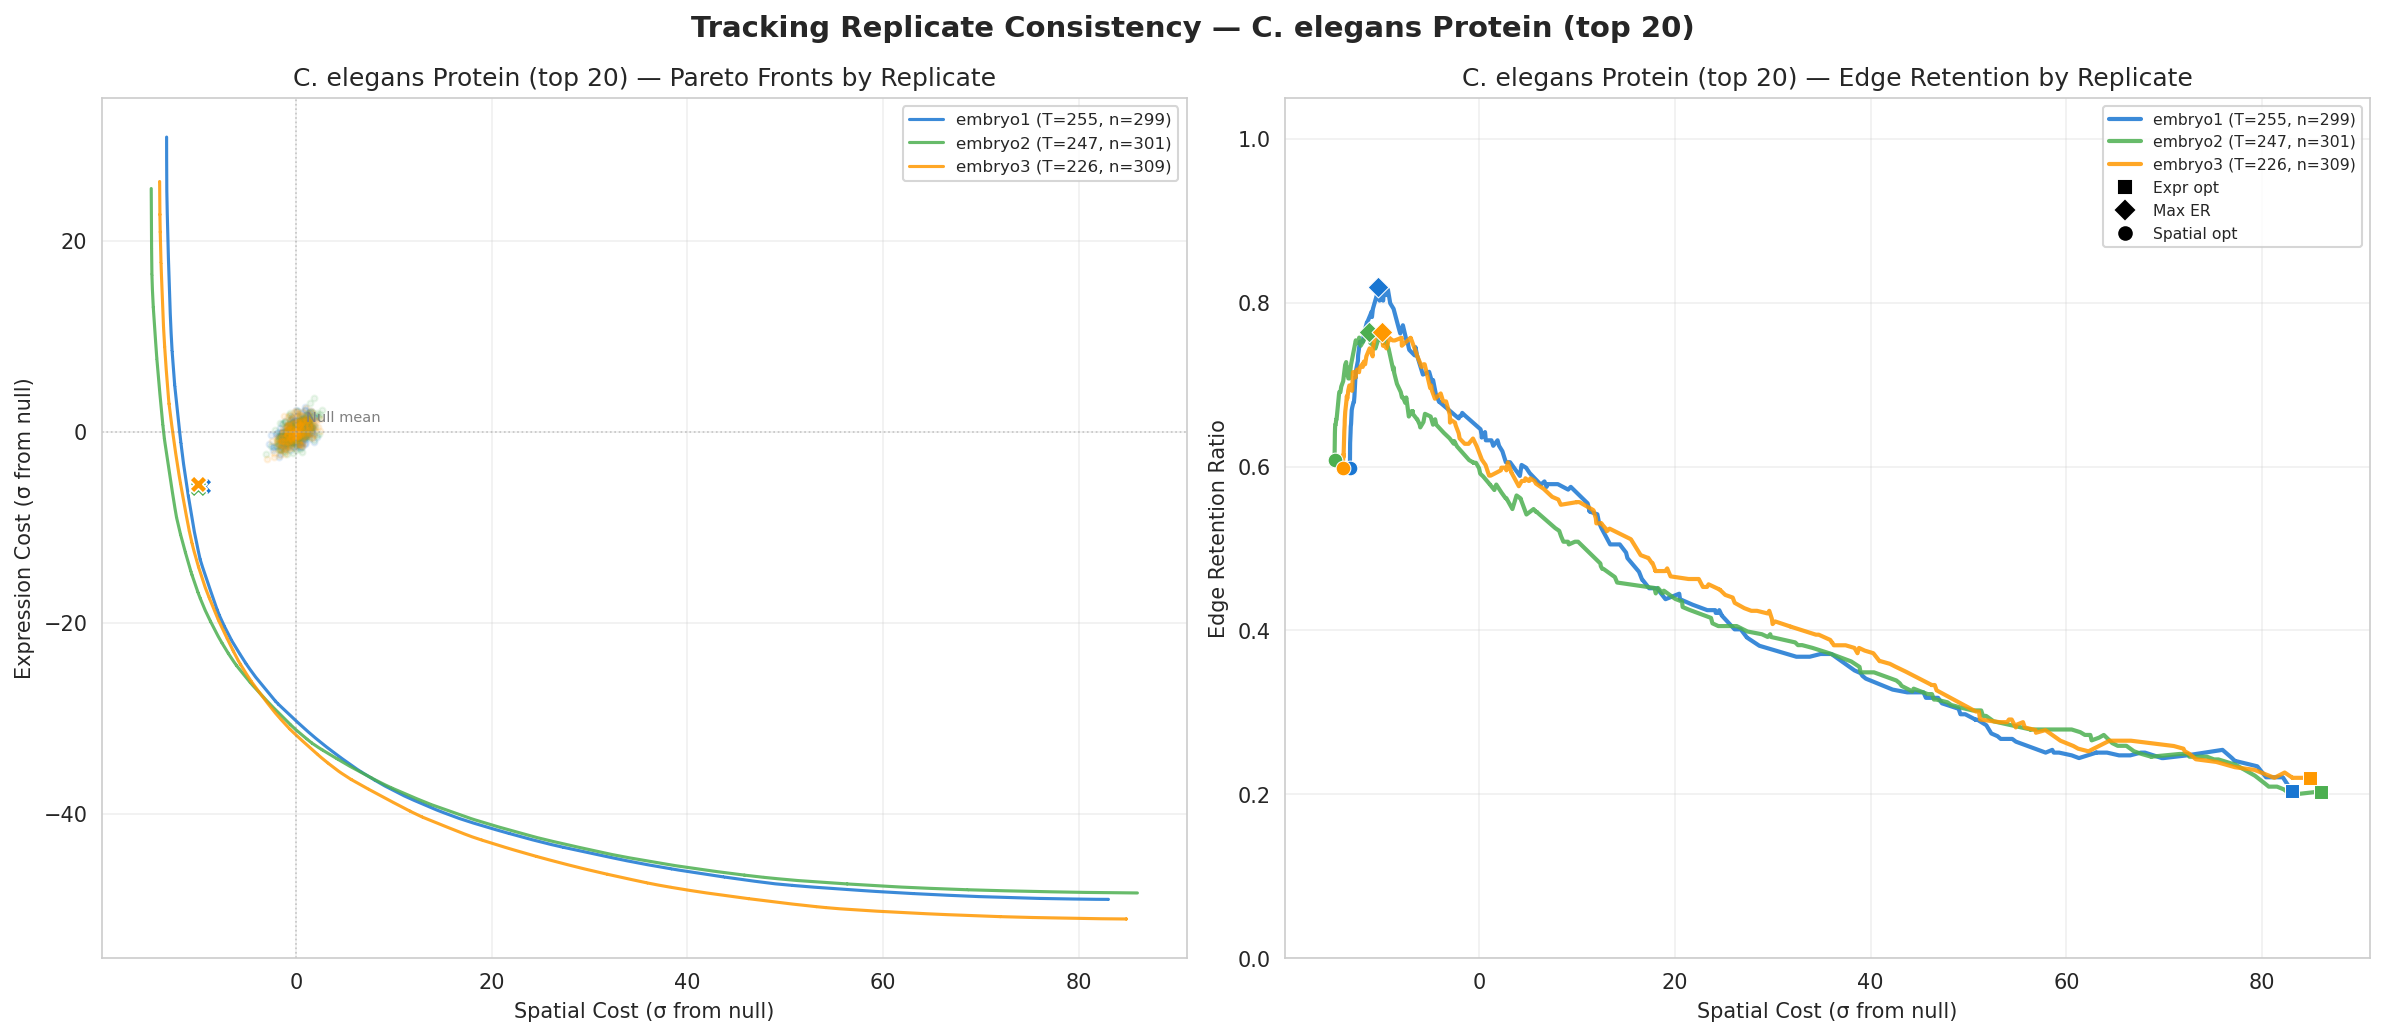

In [12]:
# ── Figure: C. elegans Protein (top 20) — replicate consistency ──
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
for label, d in ce_protein_reps.items():
    res, color, tcut = d['res'], d['color'], d['tcut']
    xyz_arr, exp_arr, edge_arr, kp = res['xyz_arr'], res['exp_arr'], res['edge_arr'], res['kp']
    rs = res.get('rs'); n = res['n']
    # Lineage position in z-score units
    lx, le = lineage_std_position(res['xm'], res['em'], rs)
    # Null cloud from first replicate only
    ncx, ncy = get_null_cloud(rs, max_points=250)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.10, zorder=0)
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (T={tcut}, n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=2, alpha=0.85, label=f'{label} (T={tcut}, n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(xyz_arr[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)

# Null reference
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.annotate('Null mean', (0, 0), xytext=(5, 5), textcoords='offset points', fontsize=7, color='gray')

ax_l.set_xlabel('Spatial Cost (σ from null)')
ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('C. elegans Protein (top 20) — Pareto Fronts by Replicate', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Spatial Cost (σ from null)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('C. elegans Protein (top 20) — Edge Retention by Replicate', fontsize=12)
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(handles=list(ax_r.get_lines()) + [
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')
fig.suptitle('Tracking Replicate Consistency — C. elegans Protein (top 20)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 1b. C. elegans — RNA-seq Expression (top 20 shared TFs)

In [13]:
# ── C. elegans RNA: Pareto front per tracking replicate ──
ce_rna_reps = {}
for label, path, tcut, color in ce_replicates:
    xyz_r, valid_r = load_elegans_tracking(tcut, path=path)
    res = run_replicate_pareto(xyz_r, valid_r, ce_rna, rna_sel)
    ce_rna_reps[label] = dict(res=res, color=color, tcut=tcut)
    print(f"  {label} (T={tcut}): n={res['n']}")

  embryo1 (T=255): n=231


  embryo2 (T=247): n=231


  embryo3 (T=226): n=241


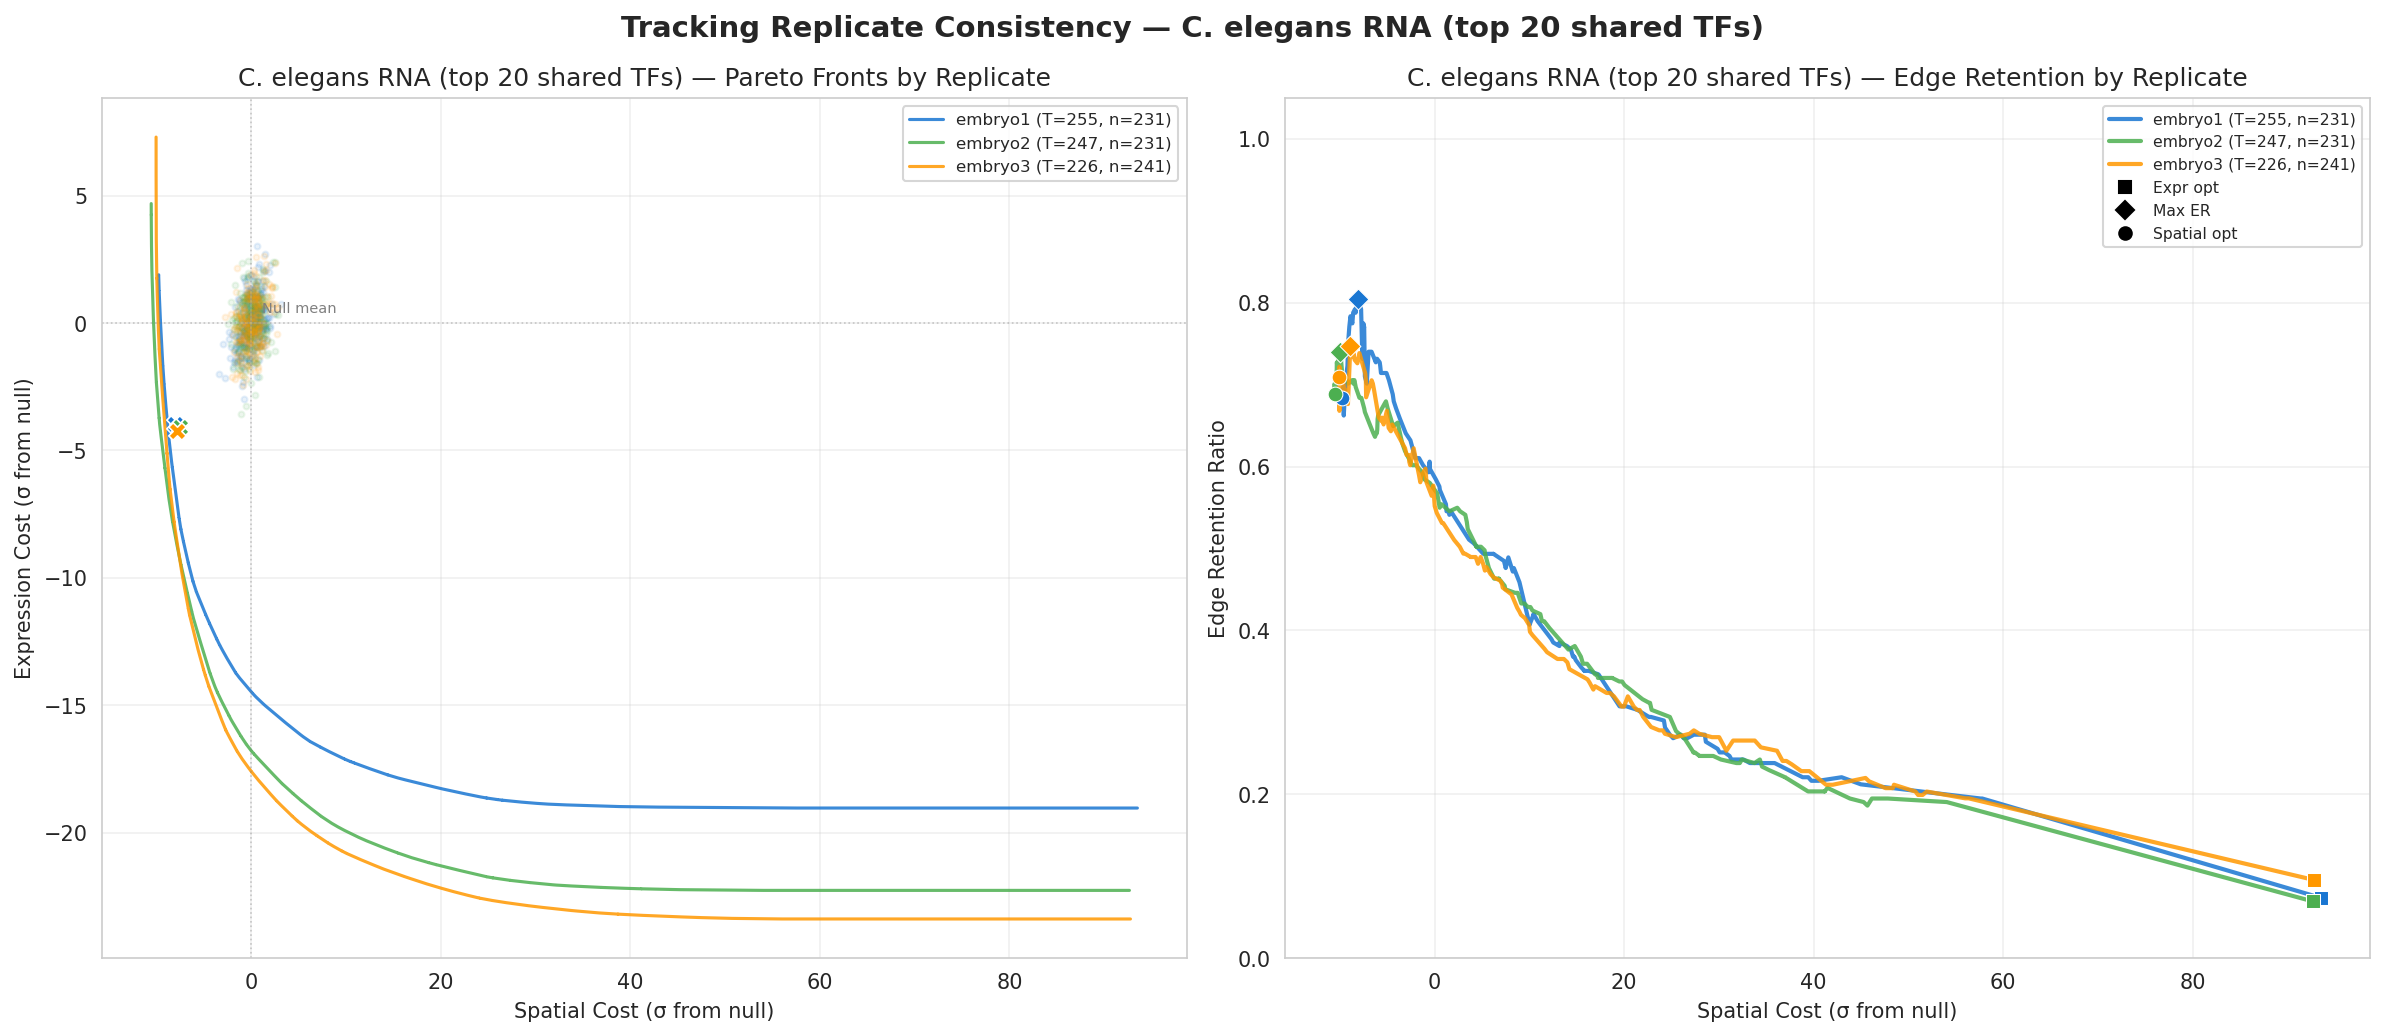

In [14]:
# ── Figure: C. elegans RNA (top 20 shared TFs) — replicate consistency ──
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
for label, d in ce_rna_reps.items():
    res, color, tcut = d['res'], d['color'], d['tcut']
    xyz_arr, exp_arr, edge_arr, kp = res['xyz_arr'], res['exp_arr'], res['edge_arr'], res['kp']
    rs = res.get('rs'); n = res['n']
    # Lineage position in z-score units
    lx, le = lineage_std_position(res['xm'], res['em'], rs)
    # Null cloud from first replicate only
    ncx, ncy = get_null_cloud(rs, max_points=250)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.10, zorder=0)
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (T={tcut}, n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=2, alpha=0.85, label=f'{label} (T={tcut}, n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(xyz_arr[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)

# Null reference
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.annotate('Null mean', (0, 0), xytext=(5, 5), textcoords='offset points', fontsize=7, color='gray')

ax_l.set_xlabel('Spatial Cost (σ from null)')
ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('C. elegans RNA (top 20 shared TFs) — Pareto Fronts by Replicate', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Spatial Cost (σ from null)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('C. elegans RNA (top 20 shared TFs) — Edge Retention by Replicate', fontsize=12)
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(handles=list(ax_r.get_lines()) + [
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')
fig.suptitle('Tracking Replicate Consistency — C. elegans RNA (top 20 shared TFs)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 1c. C. briggsae — RNA-seq Expression (top 20 shared TFs)

In [15]:
# ── C. briggsae RNA: Pareto front per tracking replicate ──
cb_rna_reps = {}
for label, path, tcut, color in cb_replicates:
    xyz_r, valid_r = load_briggsae_tracking(tcut, path=path)
    res = run_replicate_pareto(xyz_r, valid_r, cb_rna, rna_sel)
    cb_rna_reps[label] = dict(res=res, color=color, tcut=tcut)
    print(f"  {label} (T={tcut}): n={res['n']}")

  140715HLH1cbp1 (T=155): n=69


  140711HLH1cbp2 (T=155): n=90


  140711HLH1cbp3 (T=150): n=73


  140712HLH1cbp1 (T=150): n=77


  140712HLH1cbp2 (T=150): n=56


...

  241202cbhis72p1 (she-1) (T=138): n=207


  241202cbhis72p2 (she-1) (T=149): n=216


  241202cbhis72p4 (she-1) (T=158): n=225


  210519ZZY0874p1 (AF16) (T=148): n=210


  210519ZZY0874p5 (AF16) (T=156): n=213


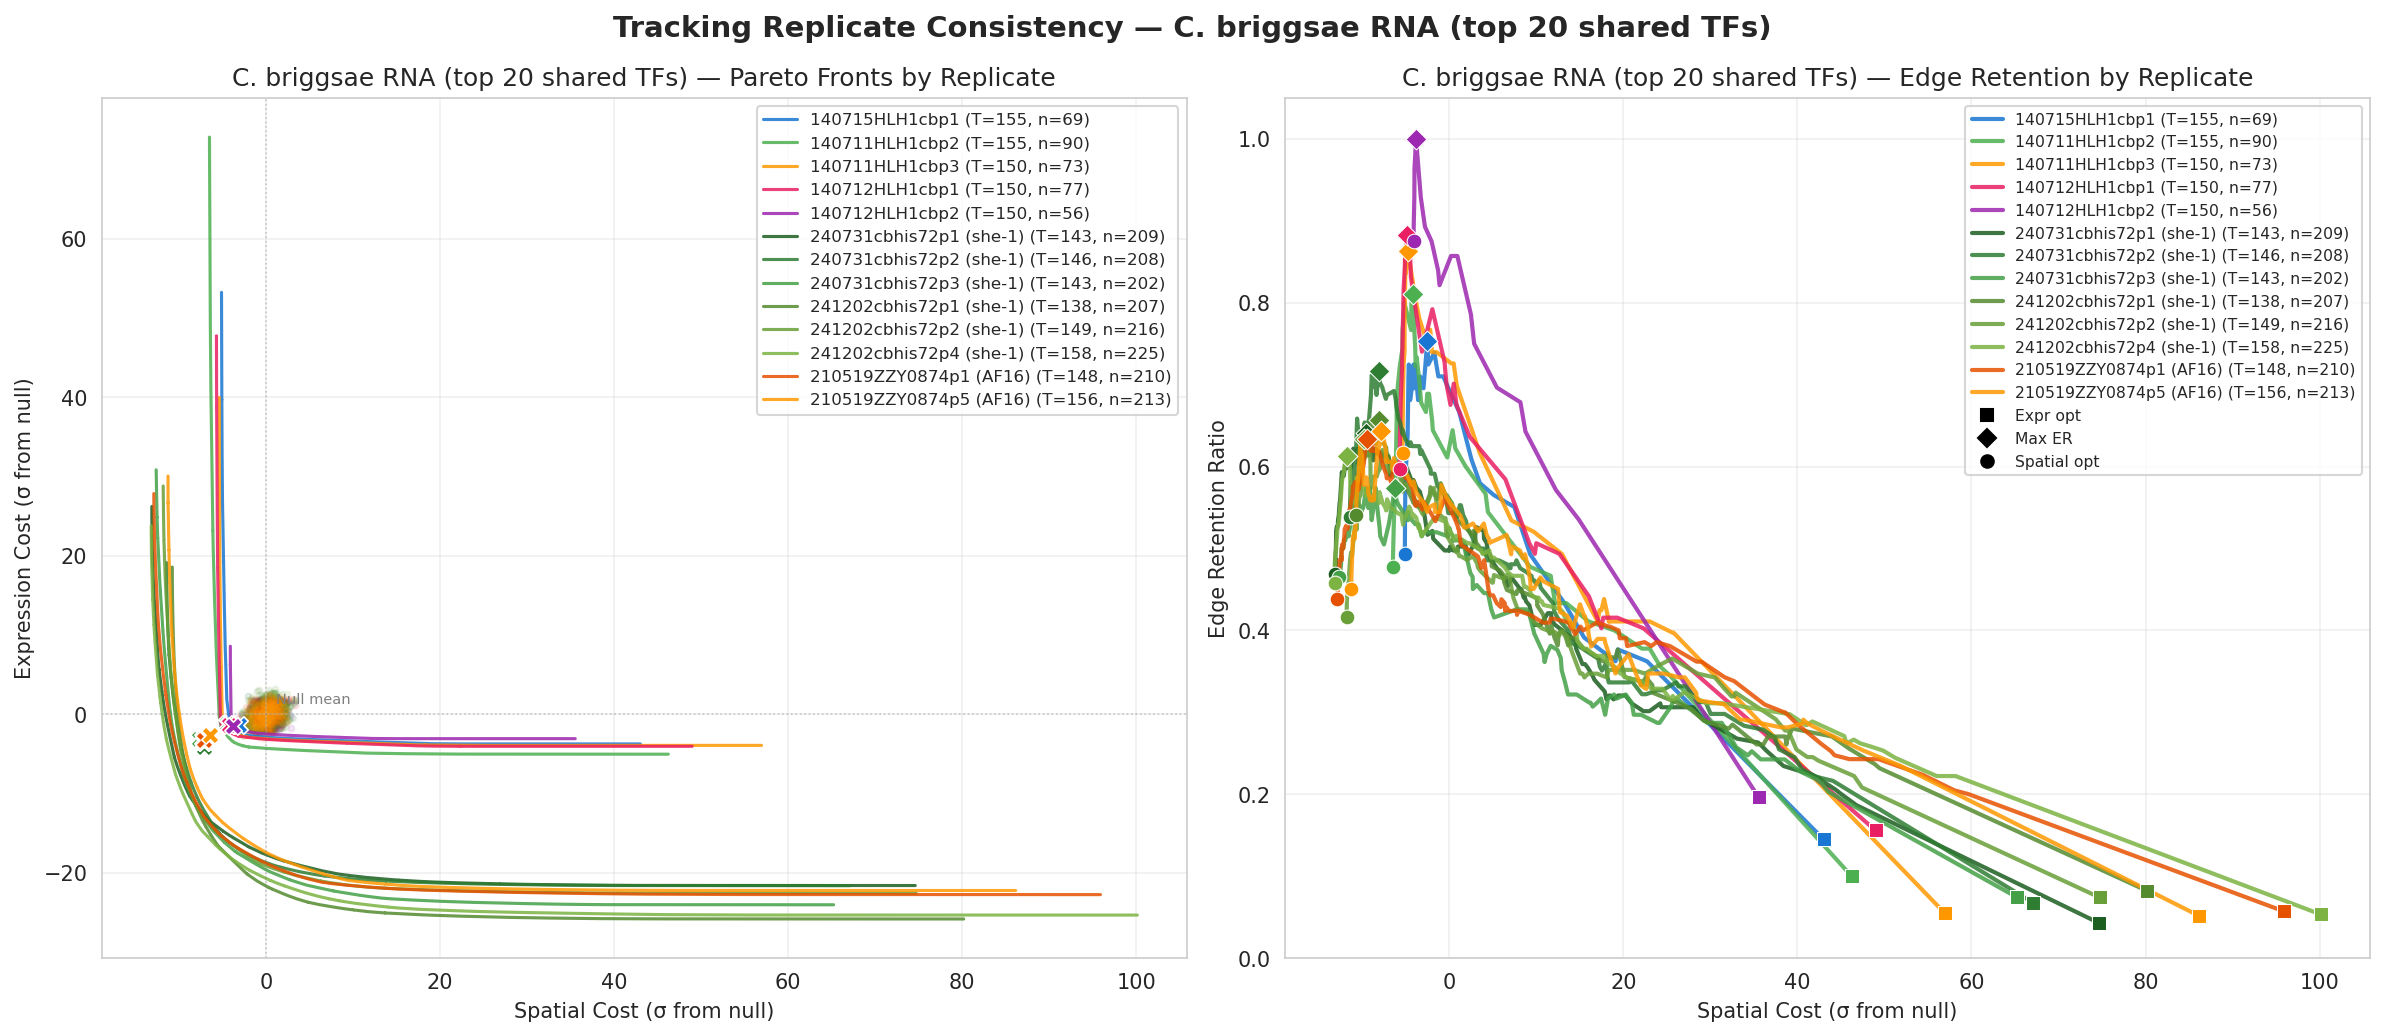

In [16]:
# ── Figure: C. briggsae RNA (top 20 shared TFs) — replicate consistency ──
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
for label, d in cb_rna_reps.items():
    res, color, tcut = d['res'], d['color'], d['tcut']
    xyz_arr, exp_arr, edge_arr, kp = res['xyz_arr'], res['exp_arr'], res['edge_arr'], res['kp']
    rs = res.get('rs'); n = res['n']
    # Lineage position in z-score units
    lx, le = lineage_std_position(res['xm'], res['em'], rs)
    # Null cloud from first replicate only
    ncx, ncy = get_null_cloud(rs, max_points=250)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.10, zorder=0)
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (T={tcut}, n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=2, alpha=0.85, label=f'{label} (T={tcut}, n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(xyz_arr[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)

# Null reference
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.annotate('Null mean', (0, 0), xytext=(5, 5), textcoords='offset points', fontsize=7, color='gray')

ax_l.set_xlabel('Spatial Cost (σ from null)')
ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('C. briggsae RNA (top 20 shared TFs) — Pareto Fronts by Replicate', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Spatial Cost (σ from null)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('C. briggsae RNA (top 20 shared TFs) — Edge Retention by Replicate', fontsize=12)
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(handles=list(ax_r.get_lines()) + [
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')
fig.suptitle('Tracking Replicate Consistency — C. briggsae RNA (top 20 shared TFs)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 1d. C. briggsae — Wildtype (AF16) vs she-1 Mutant

The new Yiming-lab data contains two genetic backgrounds: **AF16** (wildtype reference, 2 embryos)
and **she-1** (ZZY1126 mutant, 6 embryos).  she-1 is a homolog of *dumpy* in *C. elegans*,
affecting body morphology via the cuticle — it may alter spatial cell arrangements without
changing lineage or expression programs.  All replicates compared at T=143, the stage-matched cutoff.

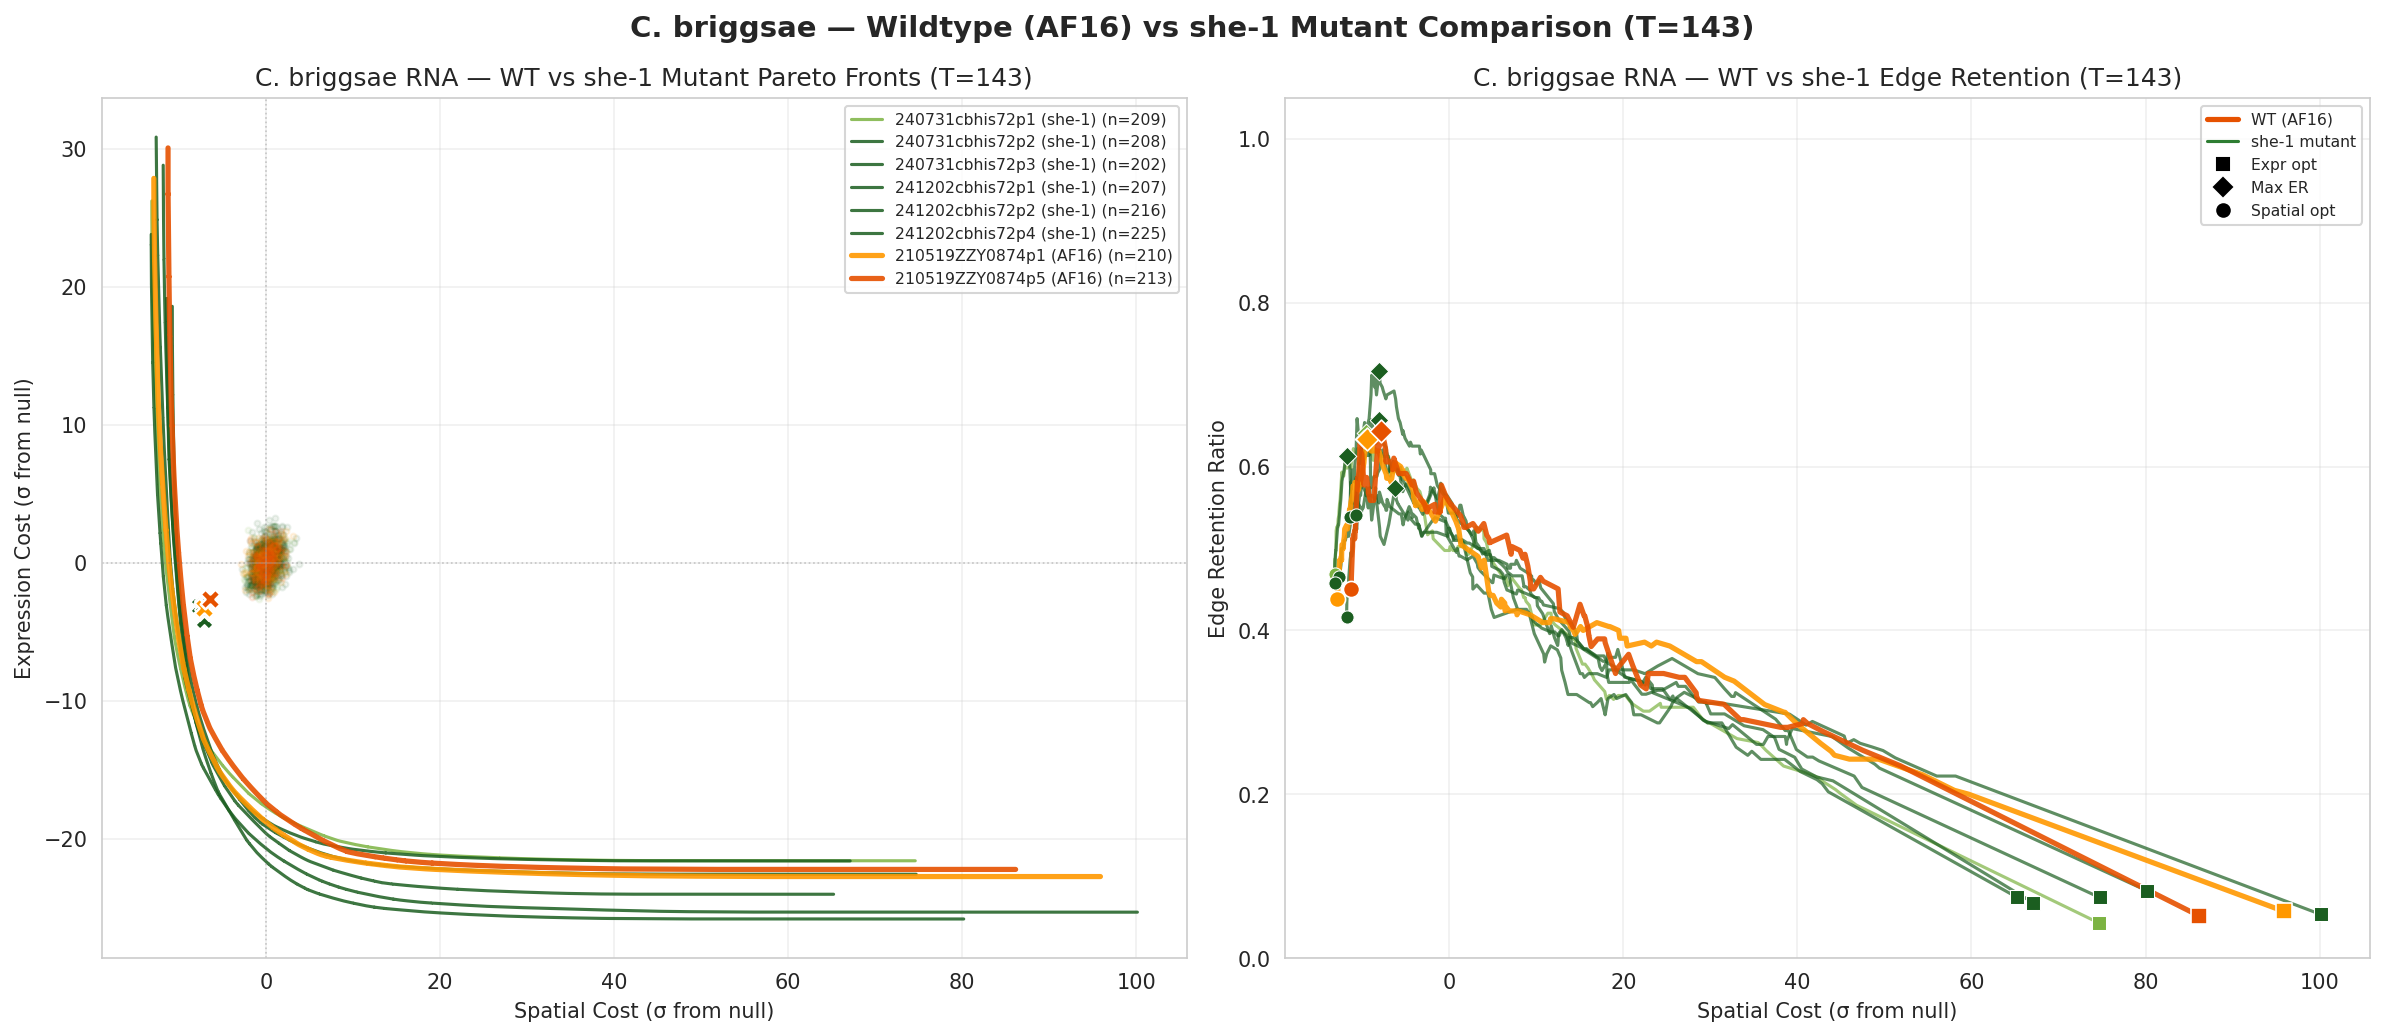

In [17]:
# ── Figure: WT (AF16) vs she-1 mutant comparison ──
# Separate replicates by strain, plot in distinct color families
wt_colors = ['#E65100', '#FF9800']
mt_colors = ['#1B5E20', '#2E7D32', '#43A047', '#558B2F', '#689F38', '#7CB342']

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))

# she-1 mutant (green shades)
for idx, (label, d) in enumerate(cb_rna_reps.items()):
    if 'she-1' not in label: continue
    res, tcut = d['res'], d['tcut']
    xyz_arr, exp_arr, edge_arr, kp = res['xyz_arr'], res['exp_arr'], res['edge_arr'], res['kp']
    color = mt_colors[idx % len(mt_colors)] if idx < 6 else mt_colors[0]
    n = res['n']
    lx, le = lineage_std_position(res['xm'], res['em'], res['rs'])
    ncx, ncy = get_null_cloud(res['rs'], max_points=200)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.08, zorder=0)
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=1.5, alpha=0.7, ls='-')
    for pk, mk in markers.items():
        ax_r.scatter(xyz_arr[kp[pk]], edge_arr[kp[pk]], color=color, marker=mk, s=40, zorder=8, edgecolors='white', lw=0.5)

# AF16 wildtype (orange shades, solid)
for idx, (label, d) in enumerate(cb_rna_reps.items()):
    if 'AF16' not in label: continue
    res, tcut = d['res'], d['tcut']
    xyz_arr, exp_arr, edge_arr, kp = res['xyz_arr'], res['exp_arr'], res['edge_arr'], res['kp']
    color = wt_colors[idx % len(wt_colors)]
    n = res['n']
    lx, le = lineage_std_position(res['xm'], res['em'], res['rs'])
    ncx, ncy = get_null_cloud(res['rs'], max_points=200)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.10, zorder=0)
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=2.5, alpha=0.9, label=f'{label} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=90, edgecolors='white', lw=1.2, zorder=7)
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=2.5, alpha=0.9, ls='-')
    for pk, mk in markers.items():
        ax_r.scatter(xyz_arr[kp[pk]], edge_arr[kp[pk]], color=color, marker=mk, s=60, zorder=9, edgecolors='white', lw=0.8)

# Null reference
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.set_xlabel('Spatial Cost (σ from null)'); ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('C. briggsae RNA — WT vs she-1 Mutant Pareto Fronts (T=143)', fontsize=12)
ax_l.legend(fontsize=7.5, loc='upper right'); ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Spatial Cost (σ from null)'); ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('C. briggsae RNA — WT vs she-1 Edge Retention (T=143)', fontsize=12)
ax_r.set_ylim(0, 1.05); ax_r.grid(True, alpha=0.3)
ax_r.legend(handles=[
    Line2D([0],[0], color='#E65100', lw=2.5, label='WT (AF16)'),
    Line2D([0],[0], color='#2E7D32', lw=1.5, label='she-1 mutant'),
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')
fig.suptitle('C. briggsae — Wildtype (AF16) vs she-1 Mutant Comparison (T=143)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 1e. Replicate Summary Table

Expr Opt / Max / Spatial Opt edge retention for every replicate, across all three configs.

In [18]:
# ── Replicate consistency summary ──
def replicate_summary_row(label, d):
    res, tcut = d['res'], d['tcut']
    edge_arr, kp = res['edge_arr'], res['kp']
    return {
        'Replicate': label, 'T cutoff': tcut, 'N': res['n'],
        'Expr Opt ER': edge_arr[kp['expr_opt_idx']],
        'Max ER': edge_arr[kp['max_er_idx']],
        'Spatial Opt ER': edge_arr[kp['spatial_opt_idx']],
    }

rows = []
for label, d in ce_protein_reps.items():
    r = replicate_summary_row(label, d); r['Config'] = 'C. elegans Protein'; rows.append(r)
for label, d in ce_rna_reps.items():
    r = replicate_summary_row(label, d); r['Config'] = 'C. elegans RNA'; rows.append(r)
for label, d in cb_rna_reps.items():
    r = replicate_summary_row(label, d); r['Config'] = 'C. briggsae RNA'; rows.append(r)

replicate_summary_df = pd.DataFrame(rows)[['Config', 'Replicate', 'T cutoff', 'N', 'Expr Opt ER', 'Max ER', 'Spatial Opt ER']].set_index(['Config', 'Replicate'])
replicate_summary_df.round(3)

T cutoff    N  Expr Opt ER  \
Config             Replicate                                             
C. elegans Protein embryo1                       255  299        0.204   
                   embryo2                       247  301        0.203   
                   embryo3                       226  309        0.220   
C. elegans RNA     embryo1                       255  231        0.074   
                   embryo2                       247  231        0.069   
                   embryo3                       226  241        0.095   
C. briggsae RNA    140715HLH1cbp1                155   69        0.145   
                   140711HLH1cbp2                155   90        0.100   
                   140711HLH1cbp3                150   73        0.055   
                   140712HLH1cbp1                150   77        0.156   
                   140712HLH1cbp2                150   56        0.196   
                   240731cbhis72p1 (she-1)       143  209        0.043   
                   240731cbhis72p2 (she-1)       146  208        0.067   
                   240731cbhis72p3 (she-1)       143  202        0.074   
                   241202cbhis72p1 (she-1)       138  207        0.082   
                   241202cbhis72p2 (she-1)       149  216        0.074   
                   241202cbhis72p4 (she-1)       158  225        0.053   
                   210519ZZY0874p1 (AF16)        148  210        0.057   
                   210519ZZY0874p5 (AF16)        156  213        0.052   

                                            Max ER  Spatial Opt ER  
Config             Replicate                                        
C. elegans Protein embryo1                   0.819           0.599  
                   embryo2                   0.764           0.608  
                   embryo3                   0.764           0.599  
C. elegans RNA     embryo1                   0.805           0.684  
                   embryo2                   0.740           0.688  
                   embryo3                   0.747           0.710  
C. briggsae RNA    140715HLH1cbp1            0.754           0.493  
                   140711HLH1cbp2            0.811           0.478  
                   140711HLH1cbp3            0.863           0.616  
                   140712HLH1cbp1            0.883           0.597  
                   140712HLH1cbp2            1.000           0.875  
                   240731cbhis72p1 (she-1)   0.641           0.469  
                   240731cbhis72p2 (she-1)   0.716           0.538  
                   240731cbhis72p3 (she-1)   0.574           0.465  
                   241202cbhis72p1 (she-1)   0.657           0.541  
                   241202cbhis72p2 (she-1)   0.634           0.417  
                   241202cbhis72p4 (she-1)   0.613           0.458  
                   210519ZZY0874p1 (AF16)    0.633           0.438  
                   210519ZZY0874p5 (AF16)    0.643           0.451

---
## 2. Full Tree — Cross-Dataset Comparison

Top 20 selected features for each dataset. C. elegans protein vs C. elegans RNA vs C. briggsae RNA.

In [19]:
# ── Run Pareto for all three full-tree datasets ──
# Cross-species comparison: all at full developmental cutoffs
#   C. elegans protein T=255, C. elegans RNA T=255, C. briggsae RNA (new) T=165
res_prot_xs = pareto_sweep(xm_prot, em_prot, tp_prot)
res_er_xs   = pareto_sweep(xm_er,   em_er,   tp_er)
res_cb      = pareto_sweep(xm_cb,     em_cb,     tp_cb)
res_cb_new  = pareto_sweep(xm_cb_new, em_cb_new, tp_cb_new)

# ── Summary table ──
full_tree_df = pd.DataFrame({
    'Dataset': ['C. elegans\nProtein (top 20, T=255)', 'C. elegans\nRNA (top 20, T=255)', 'C. briggsae\nRNA (top 20, T=143)'],
    'N Cells': [len(tn_prot), len(tn_er), len(tn_cb_new)],
    'Expr Opt ER': [res_prot_xs['expr_opt_er'], res_er_xs['expr_opt_er'], res_cb_new['expr_opt_er']],
    'Max ER': [res_prot_xs['max_er'], res_er_xs['max_er'], res_cb_new['max_er']],
    'Spatial Opt ER': [res_prot_xs['spatial_opt_er'], res_er_xs['spatial_opt_er'], res_cb_new['spatial_opt_er']],
    'Closest Dist': [res_prot_xs['closest_dist'], res_er_xs['closest_dist'], res_cb_new['closest_dist']],
}).set_index('Dataset')
full_tree_df

,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist
Dataset,,,,,
"C. elegans\nProtein (top 20, T=255)",299,0.204013,0.819398,0.598662,1.131506
"C. elegans\nRNA (top 20, T=255)",231,0.073593,0.805195,0.683983,0.596727
"C. briggsae\nRNA (top 20, T=143)",209,0.076555,0.641148,0.468900,2.154122


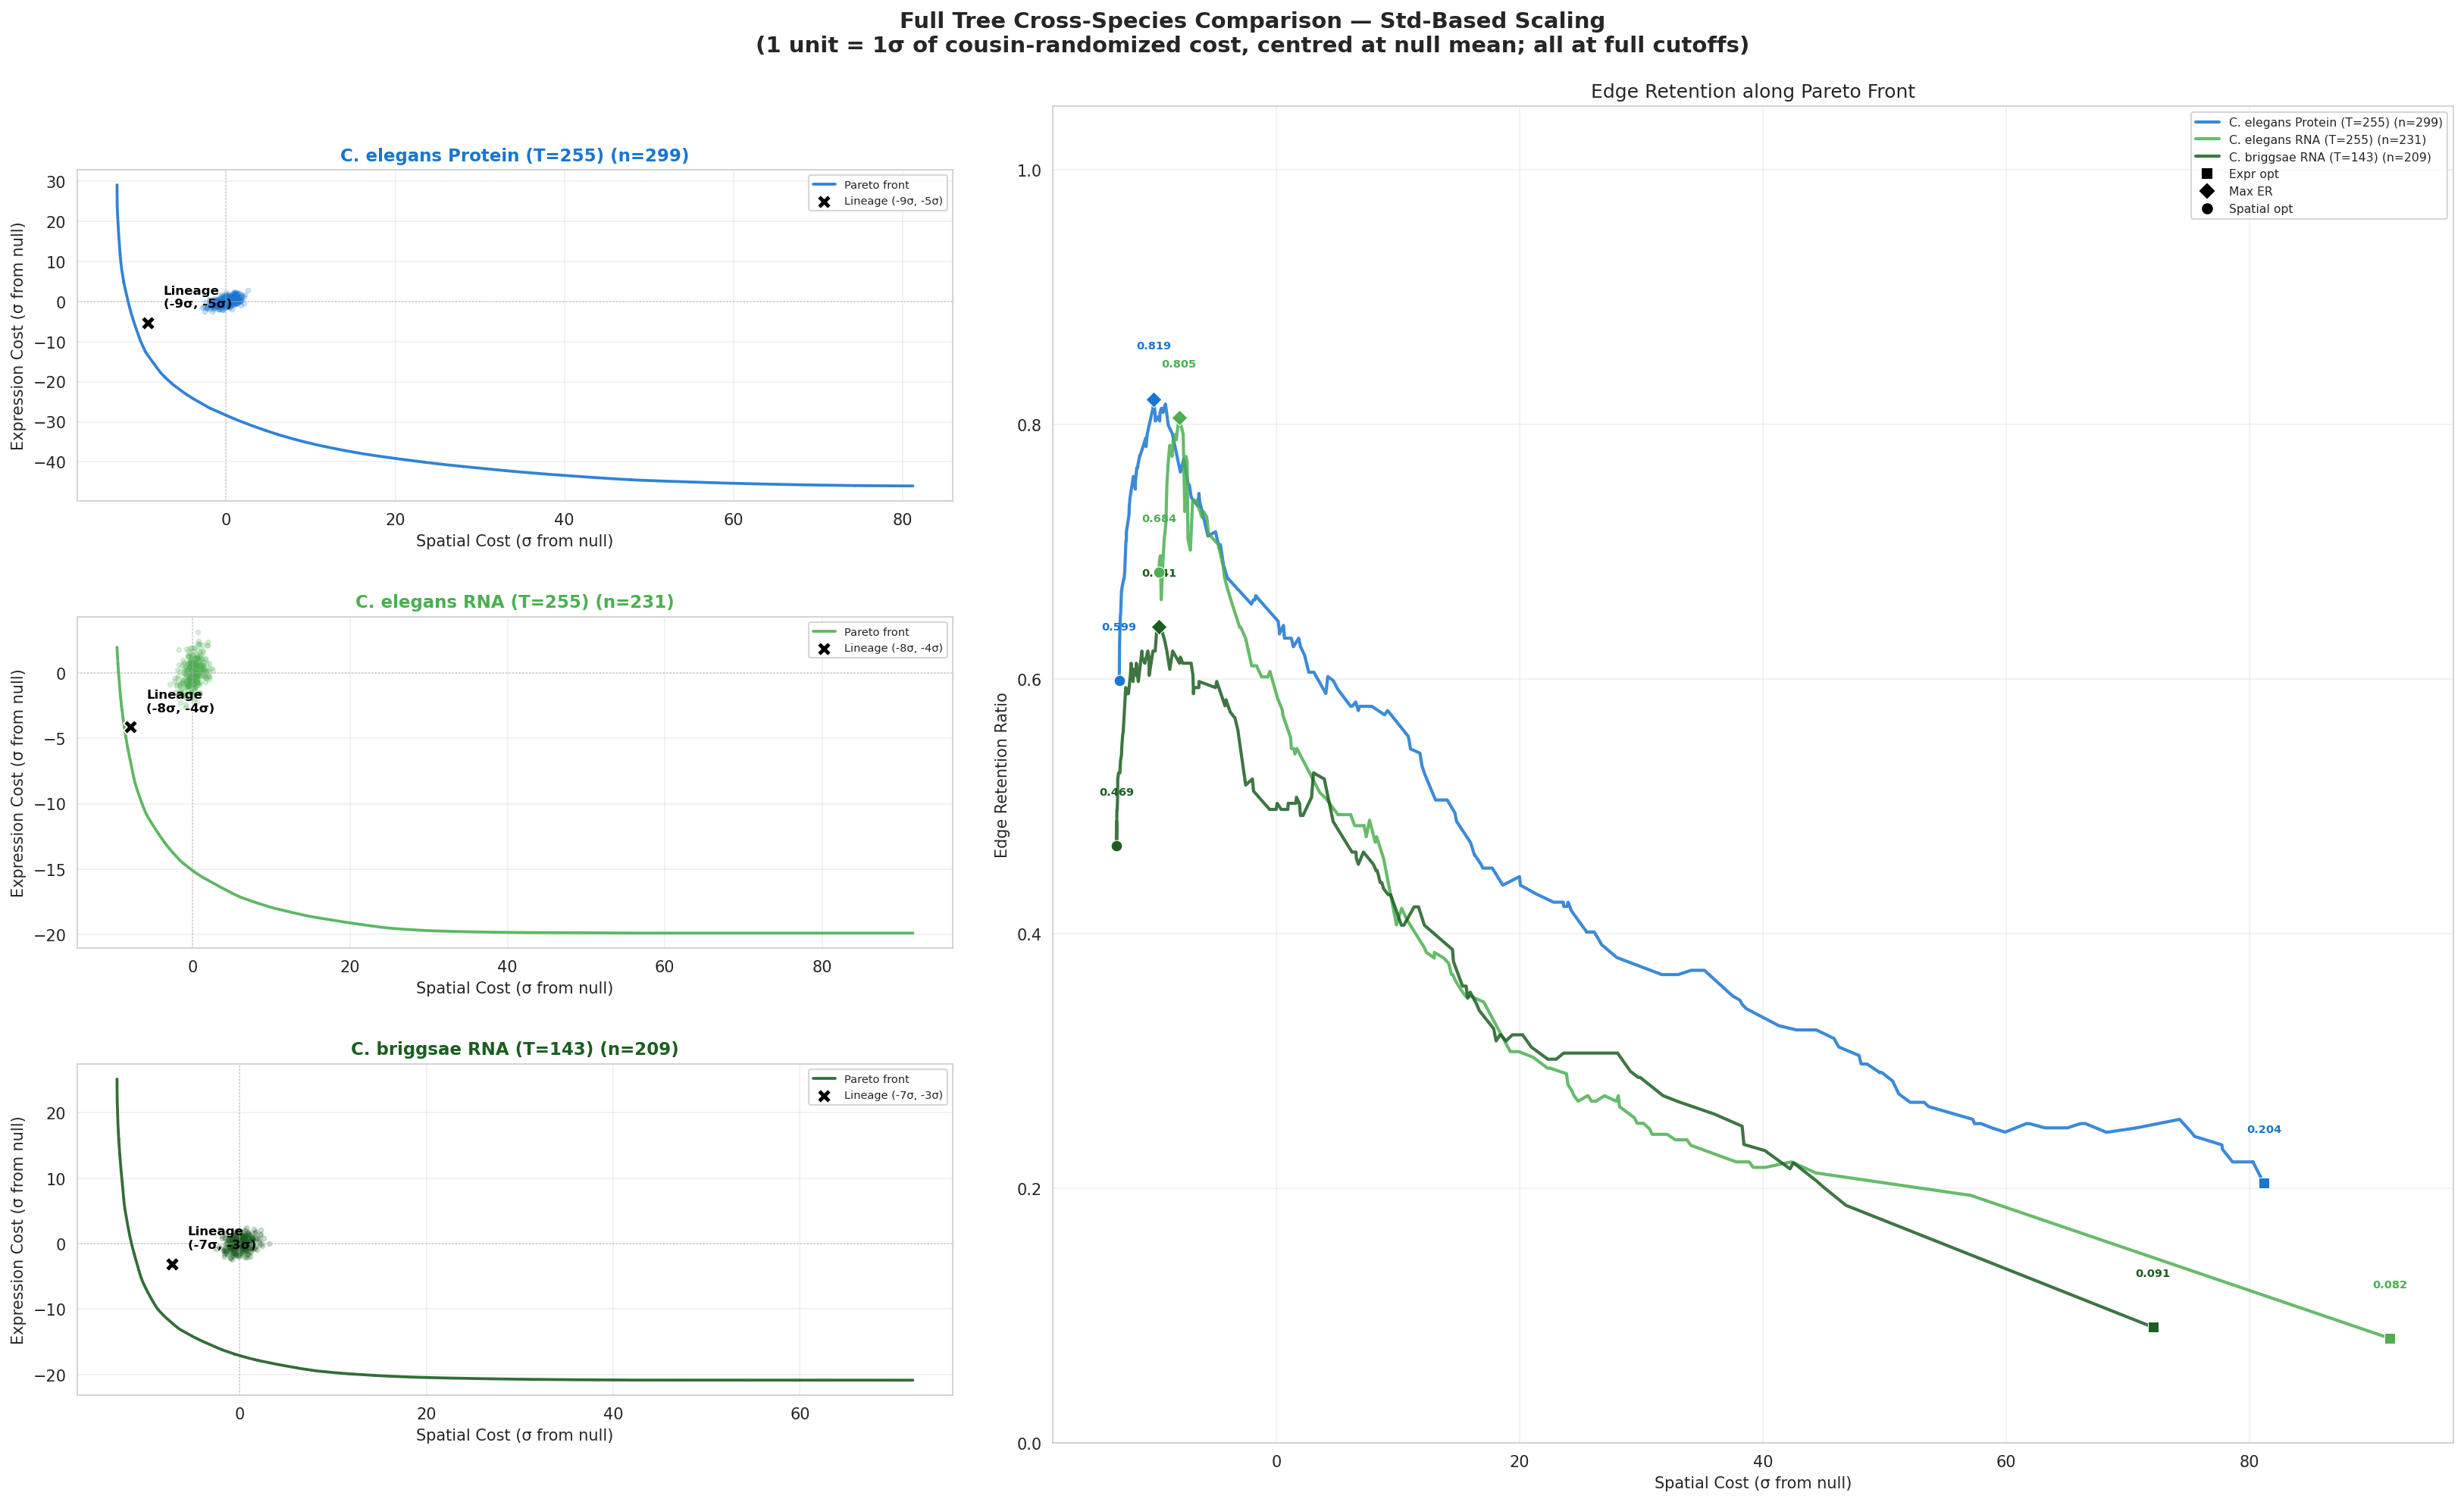

In [20]:
# ── Figure: Full tree cross-species comparison (std-based scaling) ──
# All three configs at full developmental cutoffs for fair comparison:
#   C. elegans Protein (T=255), C. elegans RNA (T=255), C. briggsae RNA new (T=165)

datasets = [
    ('C. elegans Protein (T=255)', xm_prot,     em_prot,     tp_prot,     '#1976D2', prot_rs),
    ('C. elegans RNA (T=255)',     xm_er,       em_er,       tp_er,       '#4CAF50', er_rs),
    ('C. briggsae RNA (T=143)',xm_cb_new,   em_cb_new,   tp_cb_new,   '#1B5E20', cb_new_rs),
]

fig = plt.figure(figsize=(22, 14))
x_front = np.linspace(0, 1, 1001)
markers = {'expr_opt_idx': 's', 'spatial_opt_idx': 'o', 'max_er_idx': 'D'}

# ── TOP: 3 stacked Pareto panels (one per dataset) ──
gs_pareto = fig.add_gridspec(3, 1, left=0.03, right=0.38, hspace=0.35)

for idx, (name, xm, em, tp, color, rs) in enumerate(datasets):
    ax = fig.add_subplot(gs_pareto[idx])
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(xm, em, tp, rs)
    n = len(tp)

    # Lineage position in z-score units
    lx, le = lineage_std_position(xm, em, rs)

    # Null point cloud
    ncx, ncy = get_null_cloud(rs, max_points=300)
    ax.scatter(ncx, ncy, c=color, s=8, alpha=0.18, zorder=0)

    # Null reference
    ax.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
    ax.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)

    ax.plot(xyz_arr, exp_arr, color=color, lw=1.8, alpha=0.9, label='Pareto front')
    ax.scatter(lx, le, color=color, marker='X', s=80, edgecolors='white', lw=0.8, zorder=6)
    ax.scatter(lx, le, color='black', marker='X', s=80, edgecolors='white', lw=0.8, zorder=10,
              label=f'Lineage ({lx:.0f}\u03c3, {le:.0f}\u03c3)')

    # Annotate lineage position
    ax.annotate(f'Lineage\n({lx:.0f}\u03c3, {le:.0f}\u03c3)', (lx, le),
                xytext=(10, 10), textcoords='offset points', fontsize=8, color='black', fontweight='bold')

    ax.set_xlabel('Spatial Cost (σ from null)'); ax.set_ylabel('Expression Cost (σ from null)')
    ax.set_title(f'{name} (n={n})', fontsize=11, color=color, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right'); ax.grid(True, alpha=0.3)

# ── BOTTOM: Edge retention overlay (shared by all datasets, x-axis = xyz_cost) ──
ax_er = fig.add_subplot(fig.add_gridspec(1, 1, left=0.42, right=0.98, top=0.92, bottom=0.08)[0])

for name, xm, em, tp, color, rs in datasets:
    xyz_arr, ___, edge_arr, kp = compute_std_scaled_pareto(xm, em, tp, rs)
    n = len(tp)
    ax_er.plot(xyz_arr, edge_arr, color=color, lw=2, alpha=0.85, label=f'{name} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_er.scatter(xyz_arr[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)
        ax_er.annotate(f'{edge_arr[idx]:.3f}', (xyz_arr[idx], edge_arr[idx]+0.04),
                       color=color, fontsize=7, ha='center', fontweight='bold')

ax_er.legend(handles=list(ax_er.get_lines()) + [
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')
ax_er.set_xlabel('Spatial Cost (σ from null)'); ax_er.set_ylabel('Edge Retention Ratio')
ax_er.set_title('Edge Retention along Pareto Front', fontsize=12)
ax_er.set_ylim(0, 1.05); ax_er.grid(True, alpha=0.3)

fig.suptitle('Full Tree Cross-Species Comparison — Std-Based Scaling\n(1 unit = 1σ of cousin-randomized cost, centred at null mean; all at full cutoffs)',
             fontsize=14, fontweight='bold', y=0.98)
plt.show()

> **Note:** All Pareto plots now use **std-based scaling** (units = standard deviation of
> cousin-group-randomized total costs). The lineage point is no longer forced to (1,1);
> instead, its position in std units shows how many standard deviations the real lineage
> deviates from random expectation. Edge retention curves are unchanged.


---
### 2a. Cross-Species — 2D (XY-plane only)

C. briggsae tracking has lower z-axis accuracy than C. elegans (anisotropic resolution).
Restricting the spatial cost to the **XY plane only** removes this confound.
C. elegans tracking is isotropic so the 2D vs 3D comparison serves as a control:
if the cross-species gap narrows in 2D, the z-axis is likely contributing noise.

All three configs at full developmental cutoffs (elegans T=255, briggsae T=143).
Same expression data, random stats, and edge retention — only the spatial cost metric changes.

In [21]:
# ── Build 2D (XY-plane only) cost matrices (drop z-axis) ──
# elegans: [z,y,x] → 2D=[y,x]; briggsae: [z,x,y] → 2D=[x,y]
# L2 distance is agnostic to axis order, so v[1:] works for both
xyz_ce_2d = {k: v[1:] for k, v in xyz_ce.items()}
xyz_cb_new_2d = {k: v[1:] for k, v in xyz_cb_new.items()}

# elegans protein (T=255, 2D)
xm_prot_2d, em_prot_2d, _ = build_cost_matrices(tn_prot, tp_prot, xyz_ce_2d, protein_exp, prot_sel)
prot_2d_groups = build_cousin_groups(tn_prot, gp_map)
prot_2d_rs = compute_cousin_random_stats(xm_prot_2d, em_prot_2d, prot_2d_groups, n_random=500, seed=42)
# elegans RNA (T=255, 2D)
xm_er_2d, em_er_2d, _ = build_cost_matrices(tn_er, tp_er, xyz_ce_2d, ce_rna, rna_sel)
er_2d_groups = build_cousin_groups(tn_er, gp_map)
er_2d_rs = compute_cousin_random_stats(xm_er_2d, em_er_2d, er_2d_groups, n_random=500, seed=42)
# briggsae RNA new (T=143, 2D)
xm_cb_2d, em_cb_2d, _ = build_cost_matrices(tn_cb_new, tp_cb_new, xyz_cb_new_2d, cb_rna, rna_sel)
cb_2d_groups = build_cousin_groups(tn_cb_new, gp_map)
cb_2d_rs = compute_cousin_random_stats(xm_cb_2d, em_cb_2d, cb_2d_groups, n_random=500, seed=42)

print(f"2D cost matrices built: Prot n={len(tn_prot)}, RNA n={len(tn_er)}, CB n={len(tn_cb_new)}")
print(f"  2D xyz_std: Prot={prot_2d_rs['xyz_std']:.1f}, RNA={er_2d_rs['xyz_std']:.1f}, CB={cb_2d_rs['xyz_std']:.1f}")
# For reference, 3D xyz_std
print(f"  3D xyz_std: Prot={prot_rs['xyz_std']:.1f}, RNA={er_rs['xyz_std']:.1f}, CB={cb_new_rs['xyz_std']:.1f}")

2D cost matrices built: Prot n=299, RNA n=231, CB n=209
  2D xyz_std: Prot=28.9, RNA=24.5, CB=254.7
  3D xyz_std: Prot=30.8, RNA=25.6, CB=253.4


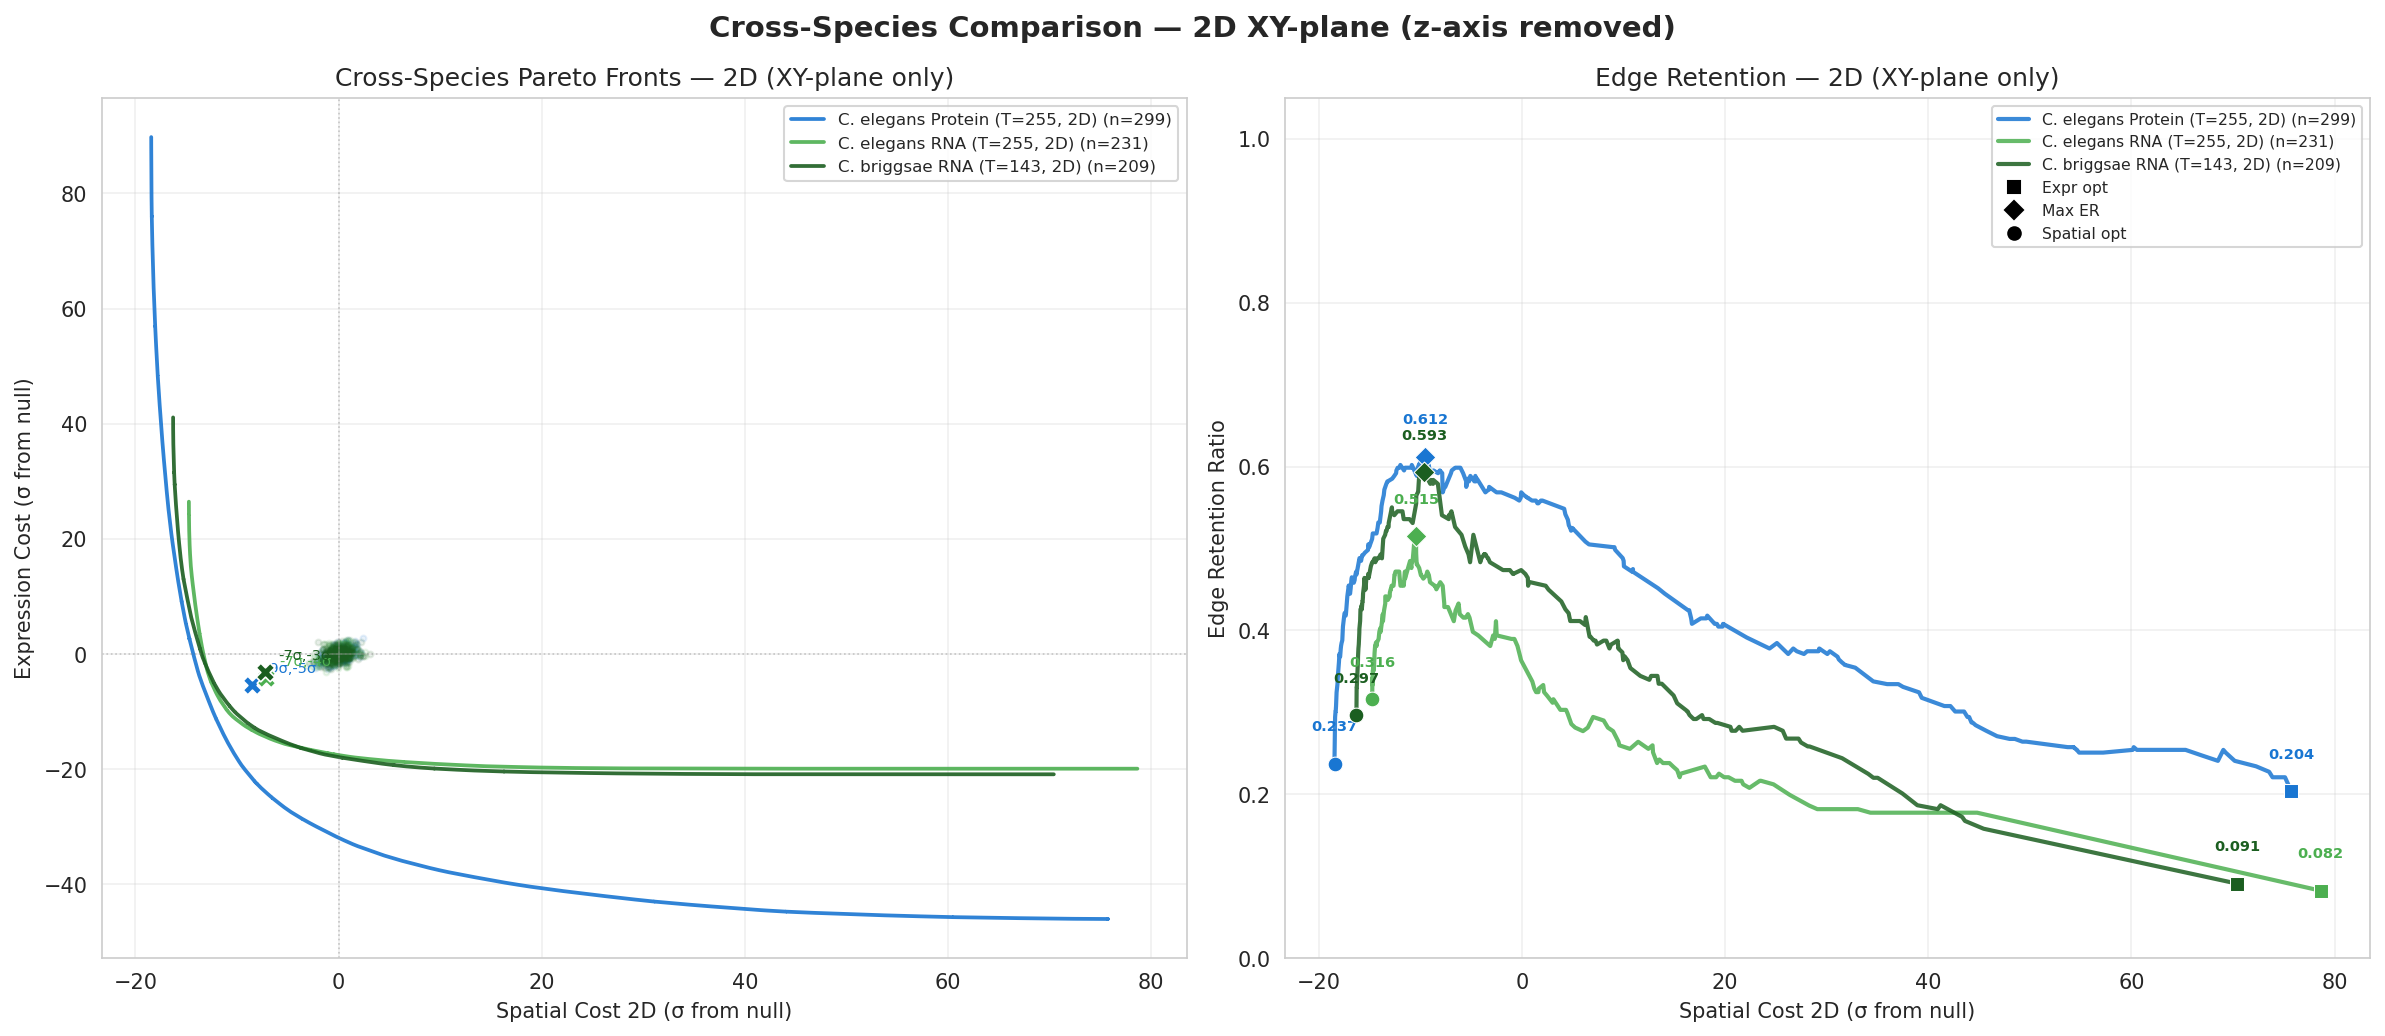

In [22]:
# ── Figure: 2D (XY-plane) cross-species comparison ──

datasets_2d = [
    ('C. elegans Protein (T=255, 2D)', xm_prot_2d, em_prot_2d, tp_prot, '#1976D2', prot_2d_rs),
    ('C. elegans RNA (T=255, 2D)',     xm_er_2d,   em_er_2d,   tp_er,   '#4CAF50', er_2d_rs),
    ('C. briggsae RNA (T=143, 2D)',    xm_cb_2d,   em_cb_2d,   tp_cb_new,'#1B5E20', cb_2d_rs),
]

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))

for name, xm, em, tp, color, rs in datasets_2d:
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(xm, em, tp, rs)
    lx, le = lineage_std_position(xm, em, rs)
    n = len(tp)

    # Null cloud
    ncx, ncy = get_null_cloud(rs, max_points=250)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.10, zorder=0)
    # Pareto front + lineage
    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.8, alpha=0.9, label=f'{name} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=80, edgecolors='white', lw=0.8, zorder=6)
    ax_l.annotate(f'{lx:.0f}\u03c3,{le:.0f}\u03c3', (lx, le), xytext=(6,6),
                  textcoords='offset points', fontsize=7, color=color)
    # Edge retention
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=2, alpha=0.85, label=f'{name} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(xyz_arr[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)
        ax_r.annotate(f'{edge_arr[idx]:.3f}', (xyz_arr[idx], edge_arr[idx]+0.04),
                       color=color, fontsize=7, ha='center', fontweight='bold')

# Null reference
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.set_xlabel('Spatial Cost 2D (σ from null)'); ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('Cross-Species Pareto Fronts — 2D (XY-plane only)', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right'); ax_l.grid(True, alpha=0.3)

ax_r.set_xlabel('Spatial Cost 2D (σ from null)'); ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('Edge Retention — 2D (XY-plane only)', fontsize=12)
ax_r.set_ylim(0, 1.05); ax_r.grid(True, alpha=0.3)
ax_r.legend(handles=list(ax_r.get_lines()) + [
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')

fig.suptitle('Cross-Species Comparison — 2D XY-plane (z-axis removed)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

In [23]:
# ── 2D vs 3D comparison table ──
_2d_res_prot = pareto_sweep(xm_prot_2d, em_prot_2d, tp_prot)
_2d_res_er   = pareto_sweep(xm_er_2d,   em_er_2d,   tp_er)
_2d_res_cb   = pareto_sweep(xm_cb_2d,   em_cb_2d,   tp_cb_new)

_compare_rows = [
    {'Config': 'C. elegans Protein (3D)',  'N': len(tn_prot),   'Expr ER': res_prot_xs['expr_opt_er'],  'Max ER': res_prot_xs['max_er'],  'Spatial ER': res_prot_xs['spatial_opt_er']},
    {'Config': 'C. elegans Protein (2D)',  'N': len(tn_prot),   'Expr ER': _2d_res_prot['expr_opt_er'], 'Max ER': _2d_res_prot['max_er'], 'Spatial ER': _2d_res_prot['spatial_opt_er']},
    {'Config': 'C. elegans RNA (3D)',      'N': len(tn_er),     'Expr ER': res_er_xs['expr_opt_er'],    'Max ER': res_er_xs['max_er'],    'Spatial ER': res_er_xs['spatial_opt_er']},
    {'Config': 'C. elegans RNA (2D)',      'N': len(tn_er),     'Expr ER': _2d_res_er['expr_opt_er'],   'Max ER': _2d_res_er['max_er'],   'Spatial ER': _2d_res_er['spatial_opt_er']},
    {'Config': 'C. briggsae RNA (3D)',     'N': len(tn_cb_new), 'Expr ER': res_cb_new['expr_opt_er'],   'Max ER': res_cb_new['max_er'],   'Spatial ER': res_cb_new['spatial_opt_er']},
    {'Config': 'C. briggsae RNA (2D)',     'N': len(tn_cb_new), 'Expr ER': _2d_res_cb['expr_opt_er'],   'Max ER': _2d_res_cb['max_er'],   'Spatial ER': _2d_res_cb['spatial_opt_er']},
]
pd.DataFrame(_compare_rows).set_index('Config').round(3)

,N,Expr ER,Max ER,Spatial ER
Config,,,,
C. elegans Protein (3D),299,0.204,0.819,0.599
C. elegans Protein (2D),299,0.204,0.612,0.237
C. elegans RNA (3D),231,0.074,0.805,0.684
C. elegans RNA (2D),231,0.074,0.515,0.316
C. briggsae RNA (3D),209,0.077,0.641,0.469
C. briggsae RNA (2D),209,0.077,0.593,0.297


---
### 2b. Z-Axis Noise Null Model

To test whether the z-axis contributes **signal** or **noise**, we replace each cell's
real z-coordinate with Gaussian noise sampled from N(μ_z, σ_z²) -- preserving the
empirical mean and variance of z across cells but destroying any cell-specific
positional information in the third dimension.

- If real 3D ≈ 2D+z_noise → z-axis is effectively random (no signal)
- If real 3D >> 2D+z_noise → z-axis carries genuine spatial signal
- 2D serves as the lower bound (z-axis removed entirely)

Tested on all three cross-species configs: elegans protein (T=255), elegans RNA (T=255),
and briggsae RNA (T=143).  10 independent noise draws per config to estimate variance.

In [24]:
# ── Z-axis noise null model: (real x, real y, Gaussian z) ──
# Multiple noise draws per config to get error bars

def make_z_noise_map(xyz_map_3d, species='elegans', seed=42):
    '''Replace z-coordinate with Gaussian noise calibrated to xy spatial scale.
    Noise sigma = pooled std of (x,y) coordinates, matching embryo size.
    elegans: [z,y,x], briggsae: [z,x,y] -- z is always index 0.'''
    rng = np.random.default_rng(seed)
    xy_vals = np.array([v[1:] for v in xyz_map_3d.values()])  # (n,2)
    sigma = np.sqrt(np.mean(np.var(xy_vals, axis=0)))  # pooled xy std
    mu = np.mean([v[1:].mean() for v in xyz_map_3d.values()])  # center of xy plane
    noisy = {}
    for k, v in xyz_map_3d.items():
        new_z = rng.normal(mu, sigma)
        noisy[k] = np.array([new_z, v[1], v[2]])  # [noise_z, real_y, real_x] for both sp.
    return noisy

def run_z_noise_pareto(xyz_map_3d, tn, tp, em_mat, species, rs_2d, n_draws=10, base_seed=1234):
    '''Run Pareto on 2D+z_noise for n_draws independent noise realizations.
    tn=terminal nodes, tp=terminal parents, em_mat=expression cost matrix (unchanged).
    Returns mean±std of key metrics across draws.'''
    results = []
    for d in range(n_draws):
        xyz_noise = make_z_noise_map(xyz_map_3d, species, seed=base_seed + d)
        n_cells = len(tp)
        # Build 2D+z_noise spatial cost matrix
        xm_nz = np.zeros((n_cells, n_cells))
        for i, p in enumerate(tp):
            for j, c in enumerate(tn):
                xm_nz[i,j] = np.linalg.norm(xyz_noise[p] - xyz_noise[c])
        # Random stats
        nz_groups = build_cousin_groups(tn, gp_map)
        nz_rs = compute_cousin_random_stats(xm_nz, em_mat, nz_groups, n_random=300, seed=42)
        xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(xm_nz, em_mat, tp, nz_rs)
        lx, le = lineage_std_position(xm_nz, em_mat, nz_rs)
        # Key metrics
        er_max = edge_arr[kp['max_er_idx']]
        er_expr = edge_arr[0]
        er_spatial = edge_arr[-1]
        # Closest point on front to lineage
        dists = np.sqrt((xyz_arr - lx)**2 + (exp_arr - le)**2)
        p_idx = np.argmin(dists)
        rel_dist = np.sqrt((lx-xyz_arr[p_idx])**2 + (le-exp_arr[p_idx])**2) / np.sqrt(xyz_arr[p_idx]**2 + exp_arr[p_idx]**2)
        results.append(dict(max_er=er_max, expr_er=er_expr, spatial_er=er_spatial, rel_dist=rel_dist,
                           xyz_arr=xyz_arr, exp_arr=exp_arr, edge_arr=edge_arr, kp=kp))
    # Aggregate
    keys = ['max_er', 'expr_er', 'spatial_er', 'rel_dist']
    agg = {k: (np.mean([r[k] for r in results]), np.std([r[k] for r in results])) for k in keys}
    # Pick median draw for plotting
    med_idx = np.argsort([r['max_er'] for r in results])[n_draws//2]
    agg['median_xyz_arr'] = results[med_idx]['xyz_arr']
    agg['median_exp_arr'] = results[med_idx]['exp_arr']
    agg['median_edge_arr'] = results[med_idx]['edge_arr']
    agg['median_kp'] = results[med_idx]['kp']
    agg['n_draws'] = n_draws
    return agg

# Run for all three configs
print("Running z-noise null model (10 draws each)...")
znoise_prot = run_z_noise_pareto(xyz_ce, tn_prot, tp_prot, em_prot, 'elegans', prot_2d_rs, n_draws=10)
znoise_er   = run_z_noise_pareto(xyz_ce, tn_er,   tp_er,   em_er,   'elegans', er_2d_rs,   n_draws=10)
znoise_cb   = run_z_noise_pareto(xyz_cb_new, tn_cb_new, tp_cb_new, em_cb_new, 'briggsae', cb_2d_rs, n_draws=10)
print("Done.")

Running z-noise null model (10 draws each)...


Done.


In [25]:
# ── 3D vs 2D vs 2D+z_noise comparison ──
znoise_rows = [
    {'Config': 'CE Protein 3D',          'Max ER': res_prot_xs['max_er'],      'Expr ER': res_prot_xs['expr_opt_er'],  'Spatial ER': res_prot_xs['spatial_opt_er']},
    {'Config': 'CE Protein 2D',          'Max ER': _2d_res_prot['max_er'],     'Expr ER': _2d_res_prot['expr_opt_er'], 'Spatial ER': _2d_res_prot['spatial_opt_er']},
    {'Config': 'CE Protein 2D+z-noise',  'Max ER': f"{znoise_prot['max_er'][0]:.3f}±{znoise_prot['max_er'][1]:.3f}",
                                          'Expr ER': f"{znoise_prot['expr_er'][0]:.3f}±{znoise_prot['expr_er'][1]:.3f}",
                                          'Spatial ER': f"{znoise_prot['spatial_er'][0]:.3f}±{znoise_prot['spatial_er'][1]:.3f}"},
    {'Config': 'CE RNA 3D',              'Max ER': res_er_xs['max_er'],       'Expr ER': res_er_xs['expr_opt_er'],   'Spatial ER': res_er_xs['spatial_opt_er']},
    {'Config': 'CE RNA 2D',              'Max ER': _2d_res_er['max_er'],      'Expr ER': _2d_res_er['expr_opt_er'],  'Spatial ER': _2d_res_er['spatial_opt_er']},
    {'Config': 'CE RNA 2D+z-noise',      'Max ER': f"{znoise_er['max_er'][0]:.3f}±{znoise_er['max_er'][1]:.3f}",
                                          'Expr ER': f"{znoise_er['expr_er'][0]:.3f}±{znoise_er['expr_er'][1]:.3f}",
                                          'Spatial ER': f"{znoise_er['spatial_er'][0]:.3f}±{znoise_er['spatial_er'][1]:.3f}"},
    {'Config': 'CB RNA 3D',              'Max ER': res_cb_new['max_er'],      'Expr ER': res_cb_new['expr_opt_er'],  'Spatial ER': res_cb_new['spatial_opt_er']},
    {'Config': 'CB RNA 2D',              'Max ER': _2d_res_cb['max_er'],      'Expr ER': _2d_res_cb['expr_opt_er'],  'Spatial ER': _2d_res_cb['spatial_opt_er']},
    {'Config': 'CB RNA 2D+z-noise',      'Max ER': f"{znoise_cb['max_er'][0]:.3f}±{znoise_cb['max_er'][1]:.3f}",
                                          'Expr ER': f"{znoise_cb['expr_er'][0]:.3f}±{znoise_cb['expr_er'][1]:.3f}",
                                          'Spatial ER': f"{znoise_cb['spatial_er'][0]:.3f}±{znoise_cb['spatial_er'][1]:.3f}"},
]
pd.DataFrame(znoise_rows).set_index('Config')

,Max ER,Expr ER,Spatial ER
Config,,,
CE Protein 3D,0.819398,0.204013,0.598662
CE Protein 2D,0.61204,0.204013,0.237458
CE Protein 2D+z-noise,0.324±0.022,0.204±0.000,0.115±0.021
CE RNA 3D,0.805195,0.073593,0.683983
CE RNA 2D,0.515152,0.073593,0.316017
CE RNA 2D+z-noise,0.251±0.034,0.074±0.000,0.132±0.028
CB RNA 3D,0.641148,0.076555,0.4689
CB RNA 2D,0.593301,0.076555,0.296651
CB RNA 2D+z-noise,0.265±0.024,0.043±0.000,0.142±0.022


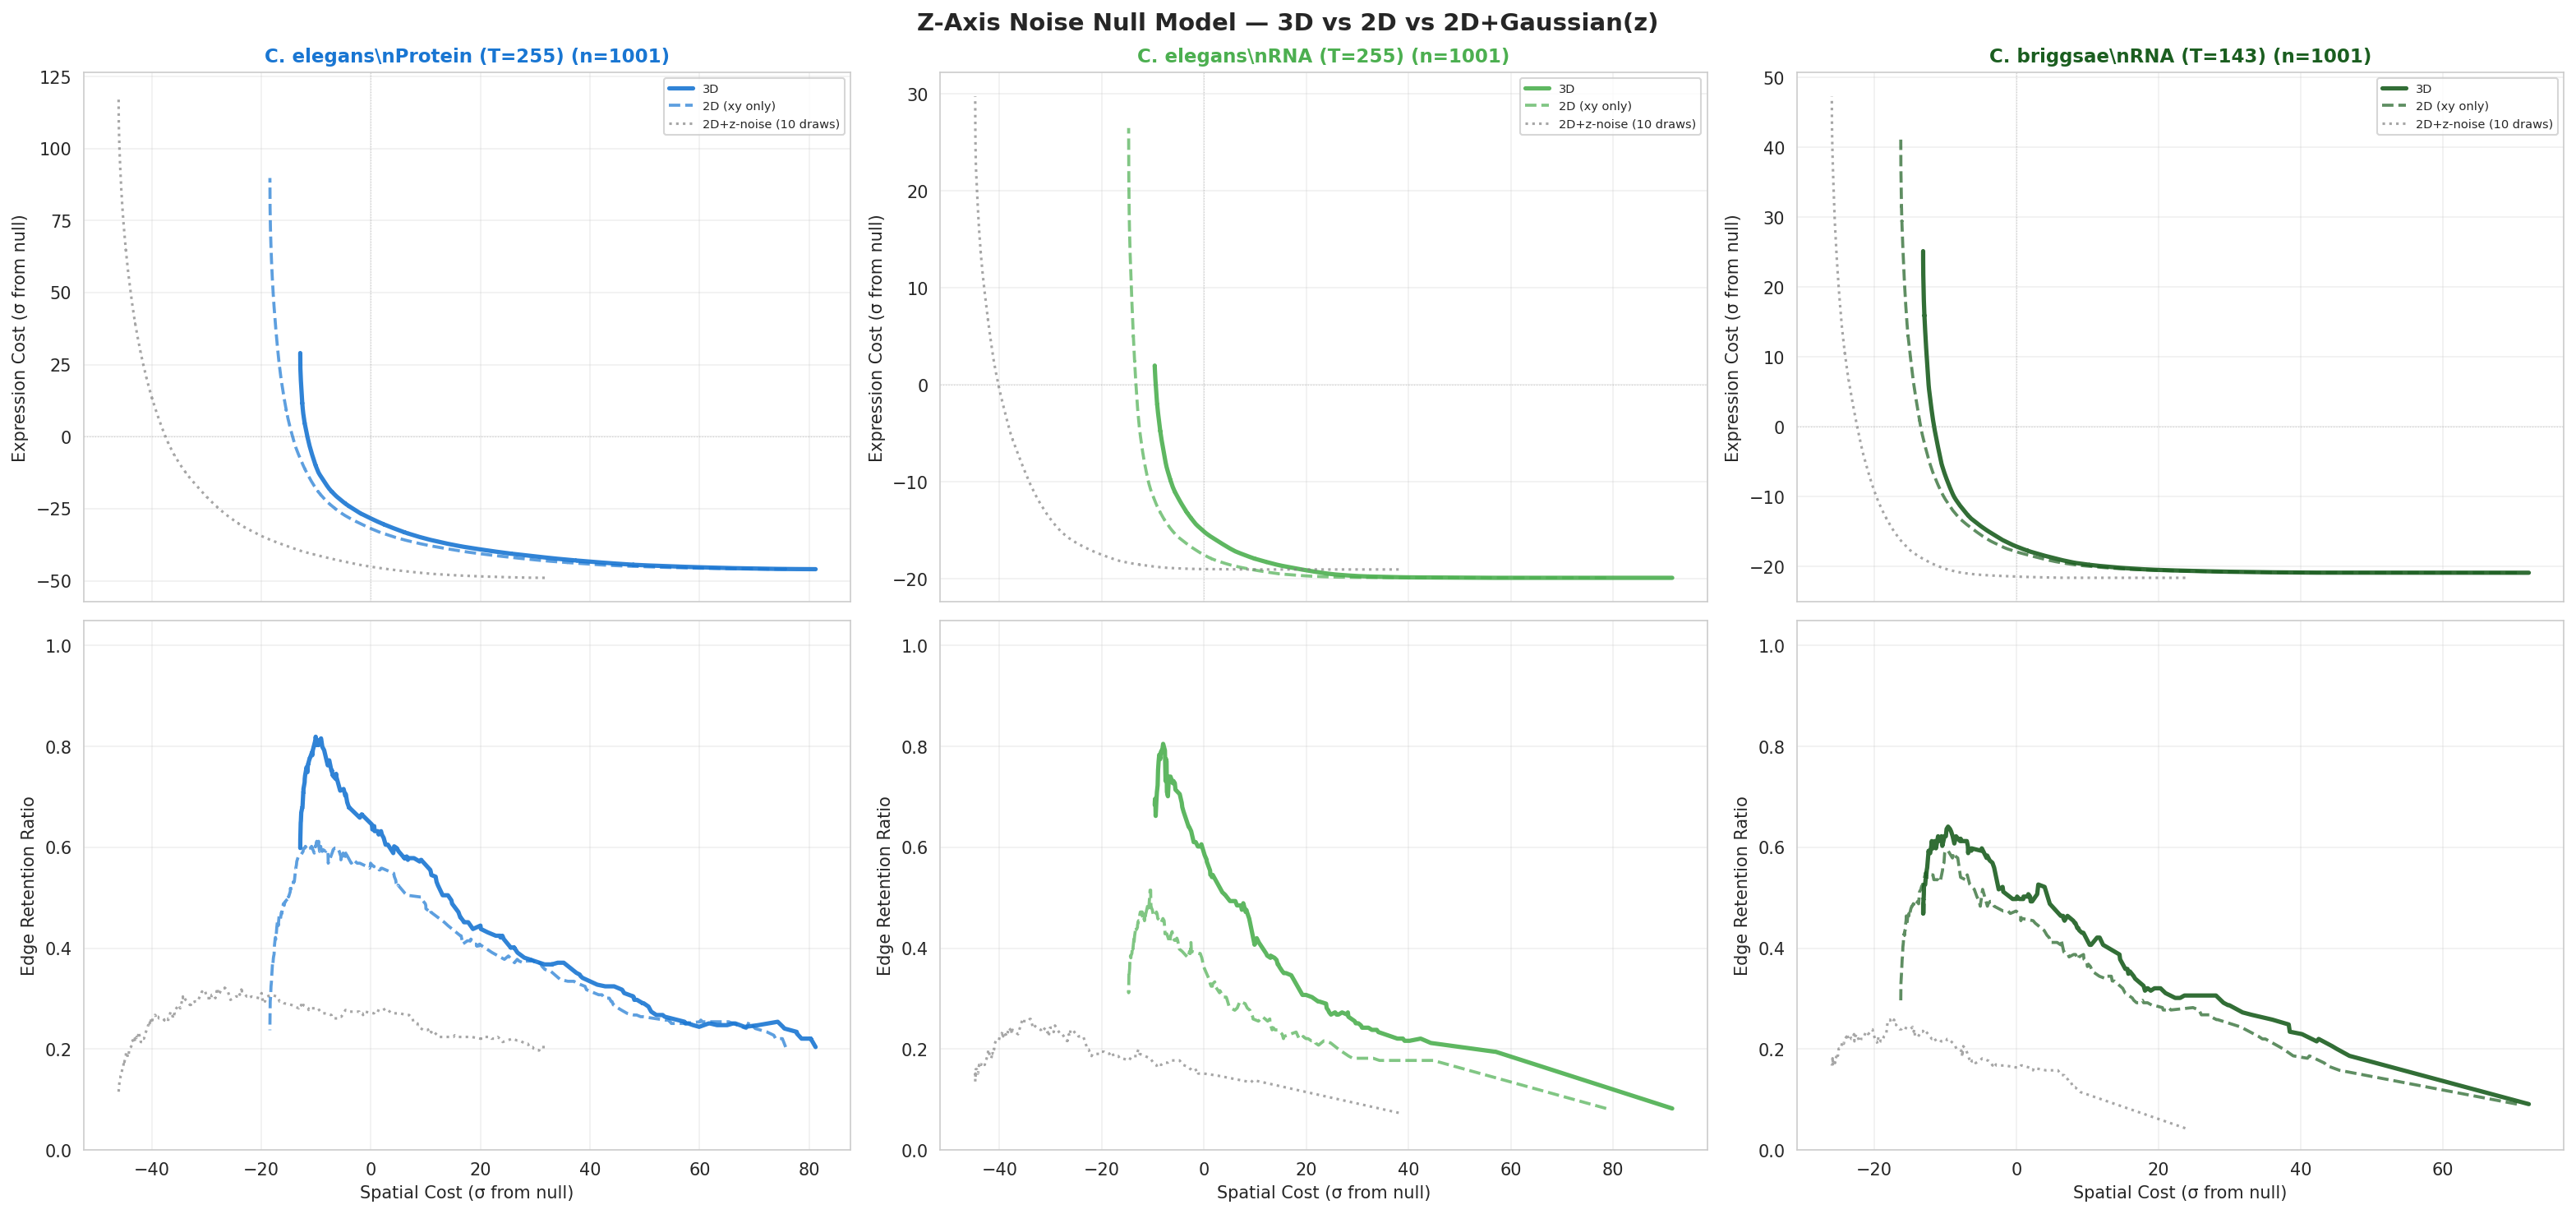

In [26]:
# ── Figure: z-noise null model — 3D vs 2D vs 2D+z_noise ──
# Recompute 3D and 2D fronts compactly for clean comparison
_prot_3d = compute_std_scaled_pareto(xm_prot, em_prot, tp_prot, prot_rs)
_er_3d   = compute_std_scaled_pareto(xm_er,   em_er,   tp_er,   er_rs)
_cb_3d   = compute_std_scaled_pareto(xm_cb_new, em_cb_new, tp_cb_new, cb_new_rs)
_prot_2d = compute_std_scaled_pareto(xm_prot_2d, em_prot_2d, tp_prot, prot_2d_rs)
_er_2d   = compute_std_scaled_pareto(xm_er_2d,   em_er_2d,   tp_er,   er_2d_rs)
_cb_2d   = compute_std_scaled_pareto(xm_cb_2d,   em_cb_2d,   tp_cb_new, cb_2d_rs)

configs = [
    ('C. elegans\\nProtein (T=255)', _prot_3d, _prot_2d, znoise_prot, '#1976D2'),
    ('C. elegans\\nRNA (T=255)',     _er_3d,   _er_2d,   znoise_er,   '#4CAF50'),
    ('C. briggsae\\nRNA (T=143)',    _cb_3d,   _cb_2d,   znoise_cb,   '#1B5E20'),
]

fig, axes = plt.subplots(2, 3, figsize=(21, 10), sharex='col')

for col, (title, r3d, r2d, rnz, color) in enumerate(configs):
    ax_p, ax_e = axes[0, col], axes[1, col]
    n = len(r3d[2])  # n cells

    # 3D (solid)
    ax_p.plot(r3d[0], r3d[1], color=color, lw=2.5, alpha=0.9, ls='-', label='3D')
    ax_e.plot(r3d[0], r3d[2], color=color, lw=2.5, alpha=0.9, ls='-')
    # 2D (dashed)
    ax_p.plot(r2d[0], r2d[1], color=color, lw=1.8, alpha=0.7, ls='--', label='2D (xy only)')
    ax_e.plot(r2d[0], r2d[2], color=color, lw=1.8, alpha=0.7, ls='--')
    # 2D+z-noise (dotted, median of 10 draws)
    ax_p.plot(rnz['median_xyz_arr'], rnz['median_exp_arr'], color='gray', lw=1.5, alpha=0.7, ls=':',
              label="2D+z-noise ({} draws)".format(rnz["n_draws"]))
    ax_e.plot(rnz['median_xyz_arr'], rnz['median_edge_arr'], color='gray', lw=1.5, alpha=0.7, ls=':')

    # Null reference
    ax_p.axhline(0, color='gray', lw=0.6, ls=':', alpha=0.3)
    ax_p.axvline(0, color='gray', lw=0.6, ls=':', alpha=0.3)

    ax_p.set_title(f'{title} (n={n})', fontsize=11, color=color, fontweight='bold')
    ax_p.legend(fontsize=7, loc='upper right'); ax_p.grid(True, alpha=0.3)
    ax_p.set_ylabel('Expression Cost (σ from null)')
    ax_e.set_xlabel('Spatial Cost (σ from null)'); ax_e.set_ylabel('Edge Retention Ratio')
    ax_e.set_ylim(0, 1.05); ax_e.grid(True, alpha=0.3)

fig.suptitle('Z-Axis Noise Null Model — 3D vs 2D vs 2D+Gaussian(z)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

---
## 3. Subtree Analysis

For each dataset, compare the Pareto front across lineage branches:
**Full tree**, **AB**, **ABa**, **ABp**, **P1**.

Subtree-specific effects reveal how the spatial-expression coupling changes
when restricting to cells within a single lineage branch.

### 3a. C. elegans — Protein Expression (top 20)

In [27]:
# ── Protein subtree analysis ──
SUBTREES = ['AB', 'ABa', 'ABp', 'P1']
prot_sub = {}
for sroot in SUBTREES + ['Full']:
    label = sroot if sroot != 'Full' else 'Full tree'
    if sroot == 'Full':
        tn, tp = tn_prot, tp_prot
    else:
        tn, tp = collect_terminals(lineage_data, v_prot, subtree=sroot)
    xm, em, _ = build_cost_matrices(tn, tp, xyz_ce, protein_exp, prot_sel)
    res = pareto_sweep(xm, em, tp)
    # Compute relative lineage-to-front distance (z-scored)
    sub_groups = build_cousin_groups(tn, gp_map)
    sub_rs = compute_cousin_random_stats(xm, em, sub_groups, n_random=300, seed=42)
    xyz_arr, exp_arr, _, _ = compute_std_scaled_pareto(xm, em, tp, sub_rs)
    lx, le = lineage_std_position(xm, em, sub_rs)
    rel_dist = relative_pareto_distance(xyz_arr, exp_arr, lx, le)
    prot_sub[label] = {'tn': tn, 'tp': tp, 'xm': xm, 'em': em, 'res': res, 'rel_pareto_dist': rel_dist}
    print(f"  {label:12s}: {len(tn):4d} cells | Expr ER={res['expr_opt_er']:.3f} | Max ER={res['max_er']:.3f} | Spatial ER={res['spatial_opt_er']:.3f} | Rel Dist={rel_dist:.3f}")

# Table
prot_sub_df = pd.DataFrame({
    'Subtree': list(prot_sub.keys()),
    'N Cells': [len(prot_sub[k]['tn']) for k in prot_sub],
    'Expr Opt ER': [prot_sub[k]['res']['expr_opt_er'] for k in prot_sub],
    'Max ER': [prot_sub[k]['res']['max_er'] for k in prot_sub],
    'Spatial Opt ER': [prot_sub[k]['res']['spatial_opt_er'] for k in prot_sub],
    'Closest Dist': [prot_sub[k]['res']['closest_dist'] for k in prot_sub],
    'Rel Pareto Dist': [round(prot_sub[k]['rel_pareto_dist'], 3) for k in prot_sub],
}).set_index('Subtree')
prot_sub_df

  AB          :  216 cells | Expr ER=0.218 | Max ER=0.838 | Spatial ER=0.671 | Rel Dist=0.082


  ABa         :  106 cells | Expr ER=0.302 | Max ER=0.887 | Spatial ER=0.679 | Rel Dist=0.059


  ABp         :  110 cells | Expr ER=0.245 | Max ER=0.882 | Spatial ER=0.773 | Rel Dist=0.138


  P1          :   83 cells | Expr ER=0.337 | Max ER=0.880 | Spatial ER=0.771 | Rel Dist=0.070


  Full tree   :  299 cells | Expr ER=0.204 | Max ER=0.819 | Spatial ER=0.599 | Rel Dist=0.142


,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist,Rel Pareto Dist
Subtree,,,,,,
AB,216,0.217593,0.837963,0.671296,0.464219,0.082
ABa,106,0.301887,0.886792,0.679245,0.174592,0.059
ABp,110,0.245455,0.881818,0.772727,0.347522,0.138
P1,83,0.337349,0.879518,0.771084,0.191338,0.070
Full tree,299,0.204013,0.819398,0.598662,1.131506,0.142


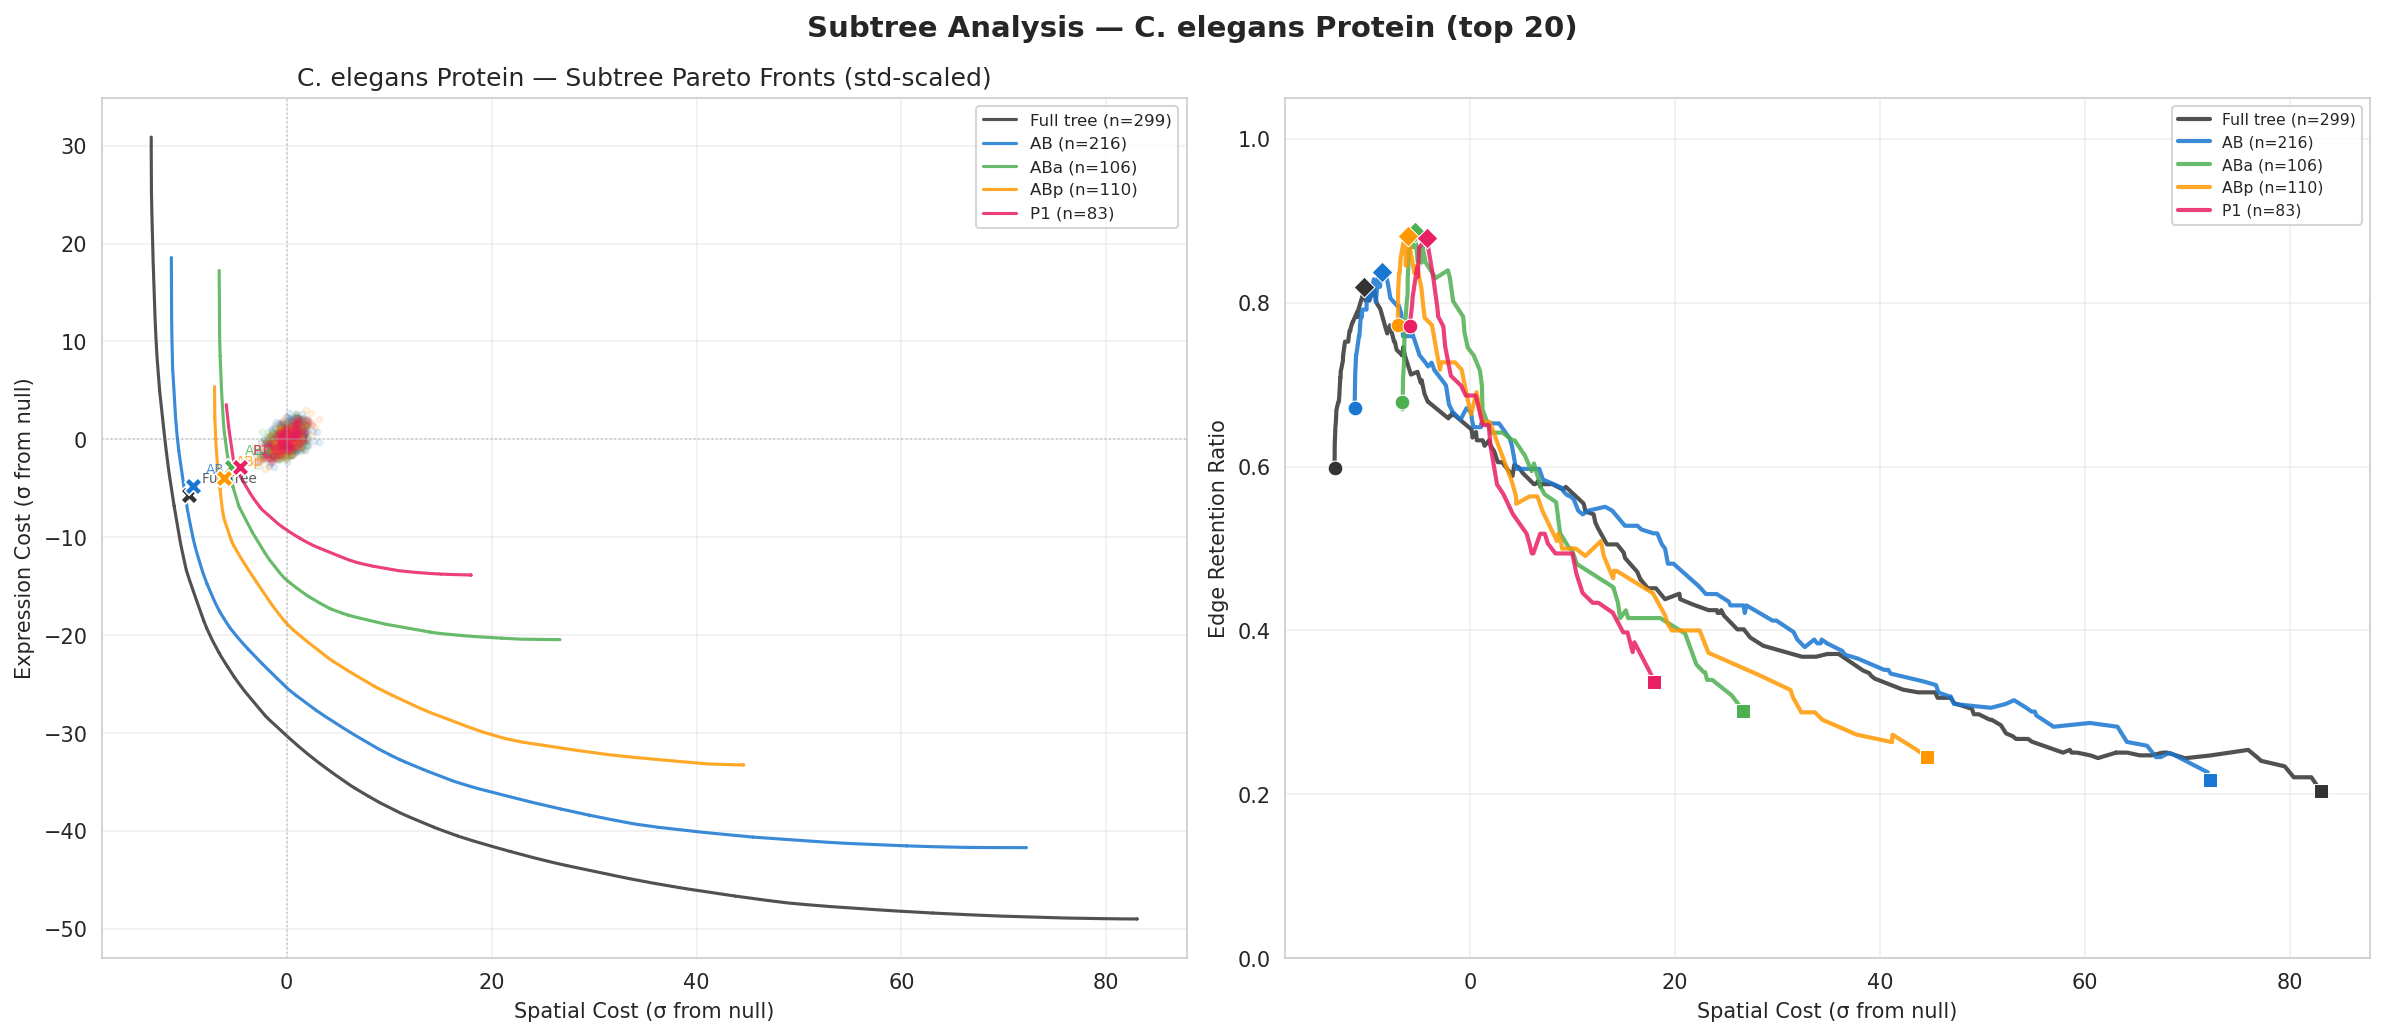

In [28]:
# ── Figure: C. elegans Protein — Subtree Pareto Fronts (std-scaled) ──
sub_colors = {'Full tree': '#333', 'AB': '#1976D2', 'ABa': '#4CAF50', 'ABp': '#FF9800', 'P1': '#E91E63'}
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))

for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    d = prot_sub[label]
    color = sub_colors[label]
    n = len(d['tn'])

    # Compute random stats for this subtree
    sub_groups = build_cousin_groups(d['tn'], gp_map)
    sub_rs = compute_cousin_random_stats(d['xm'], d['em'], sub_groups, n_random=300, seed=42)

    # Std-scaled (z-scored) Pareto front
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(d['xm'], d['em'], d['tp'], sub_rs)

    # Lineage position in z-score units
    lx, le = lineage_std_position(d['xm'], d['em'], sub_rs)

    # Null cloud from first subtree only (all share similar null)
    ncx, ncy = get_null_cloud(sub_rs, max_points=250)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.10, zorder=0)

    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_l.annotate(f'{label}', (lx, le), xytext=(6, 6), textcoords='offset points',
                  fontsize=6.5, color=color, alpha=0.8)
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=2, alpha=0.85, label=f'{label} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(xyz_arr[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)

# Null reference
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)

ax_l.set_xlabel('Spatial Cost (σ from null)')
ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('C. elegans Protein — Subtree Pareto Fronts (std-scaled)', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Spatial Cost (σ from null)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=7.5, loc='best')
fig.suptitle('Subtree Analysis — C. elegans Protein (top 20)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 3b. C. elegans — RNA-seq Expression (top 20 shared TFs)

In [29]:
# ── C. elegans RNA subtree analysis ──
er_sub = {}
for sroot in SUBTREES + ['Full']:
    label = sroot if sroot != 'Full' else 'Full tree'
    if sroot == 'Full':
        tn, tp = tn_er, tp_er
    else:
        tn, tp = collect_terminals(lineage_data, v_ce_rna, subtree=sroot)
    xm, em, _ = build_cost_matrices(tn, tp, xyz_ce, ce_rna, rna_sel)
    res = pareto_sweep(xm, em, tp)
    # Compute relative lineage-to-front distance (z-scored)
    sub_groups = build_cousin_groups(tn, gp_map)
    sub_rs = compute_cousin_random_stats(xm, em, sub_groups, n_random=300, seed=42)
    xyz_arr, exp_arr, _, _ = compute_std_scaled_pareto(xm, em, tp, sub_rs)
    lx, le = lineage_std_position(xm, em, sub_rs)
    rel_dist = relative_pareto_distance(xyz_arr, exp_arr, lx, le)
    er_sub[label] = {'tn': tn, 'tp': tp, 'xm': xm, 'em': em, 'res': res, 'rel_pareto_dist': rel_dist}
    print(f"  {label:12s}: {len(tn):4d} cells | Expr ER={res['expr_opt_er']:.3f} | Max ER={res['max_er']:.3f} | Spatial ER={res['spatial_opt_er']:.3f} | Rel Dist={rel_dist:.3f}")

er_sub_df = pd.DataFrame({
    'Subtree': list(er_sub.keys()),
    'N Cells': [len(er_sub[k]['tn']) for k in er_sub],
    'Expr Opt ER': [er_sub[k]['res']['expr_opt_er'] for k in er_sub],
    'Max ER': [er_sub[k]['res']['max_er'] for k in er_sub],
    'Spatial Opt ER': [er_sub[k]['res']['spatial_opt_er'] for k in er_sub],
    'Closest Dist': [er_sub[k]['res']['closest_dist'] for k in er_sub],
    'Rel Pareto Dist': [round(er_sub[k]['rel_pareto_dist'], 3) for k in er_sub],
}).set_index('Subtree')
er_sub_df

  AB          :  157 cells | Expr ER=0.083 | Max ER=0.936 | Spatial ER=0.911 | Rel Dist=0.019


  ABa         :   73 cells | Expr ER=0.137 | Max ER=0.945 | Spatial ER=0.945 | Rel Dist=0.021


  ABp         :   84 cells | Expr ER=0.107 | Max ER=0.952 | Spatial ER=0.952 | Rel Dist=0.018


  P1          :   74 cells | Expr ER=0.176 | Max ER=0.865 | Spatial ER=0.811 | Rel Dist=0.052


  Full tree   :  231 cells | Expr ER=0.074 | Max ER=0.805 | Spatial ER=0.684 | Rel Dist=0.091


,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist,Rel Pareto Dist
Subtree,,,,,,
AB,157,0.082803,0.936306,0.910828,0.158576,0.019
ABa,73,0.136986,0.945205,0.945205,0.047887,0.021
ABp,84,0.107143,0.952381,0.952381,0.147439,0.018
P1,74,0.175676,0.864865,0.810811,0.200761,0.052
Full tree,231,0.073593,0.805195,0.683983,0.596727,0.091


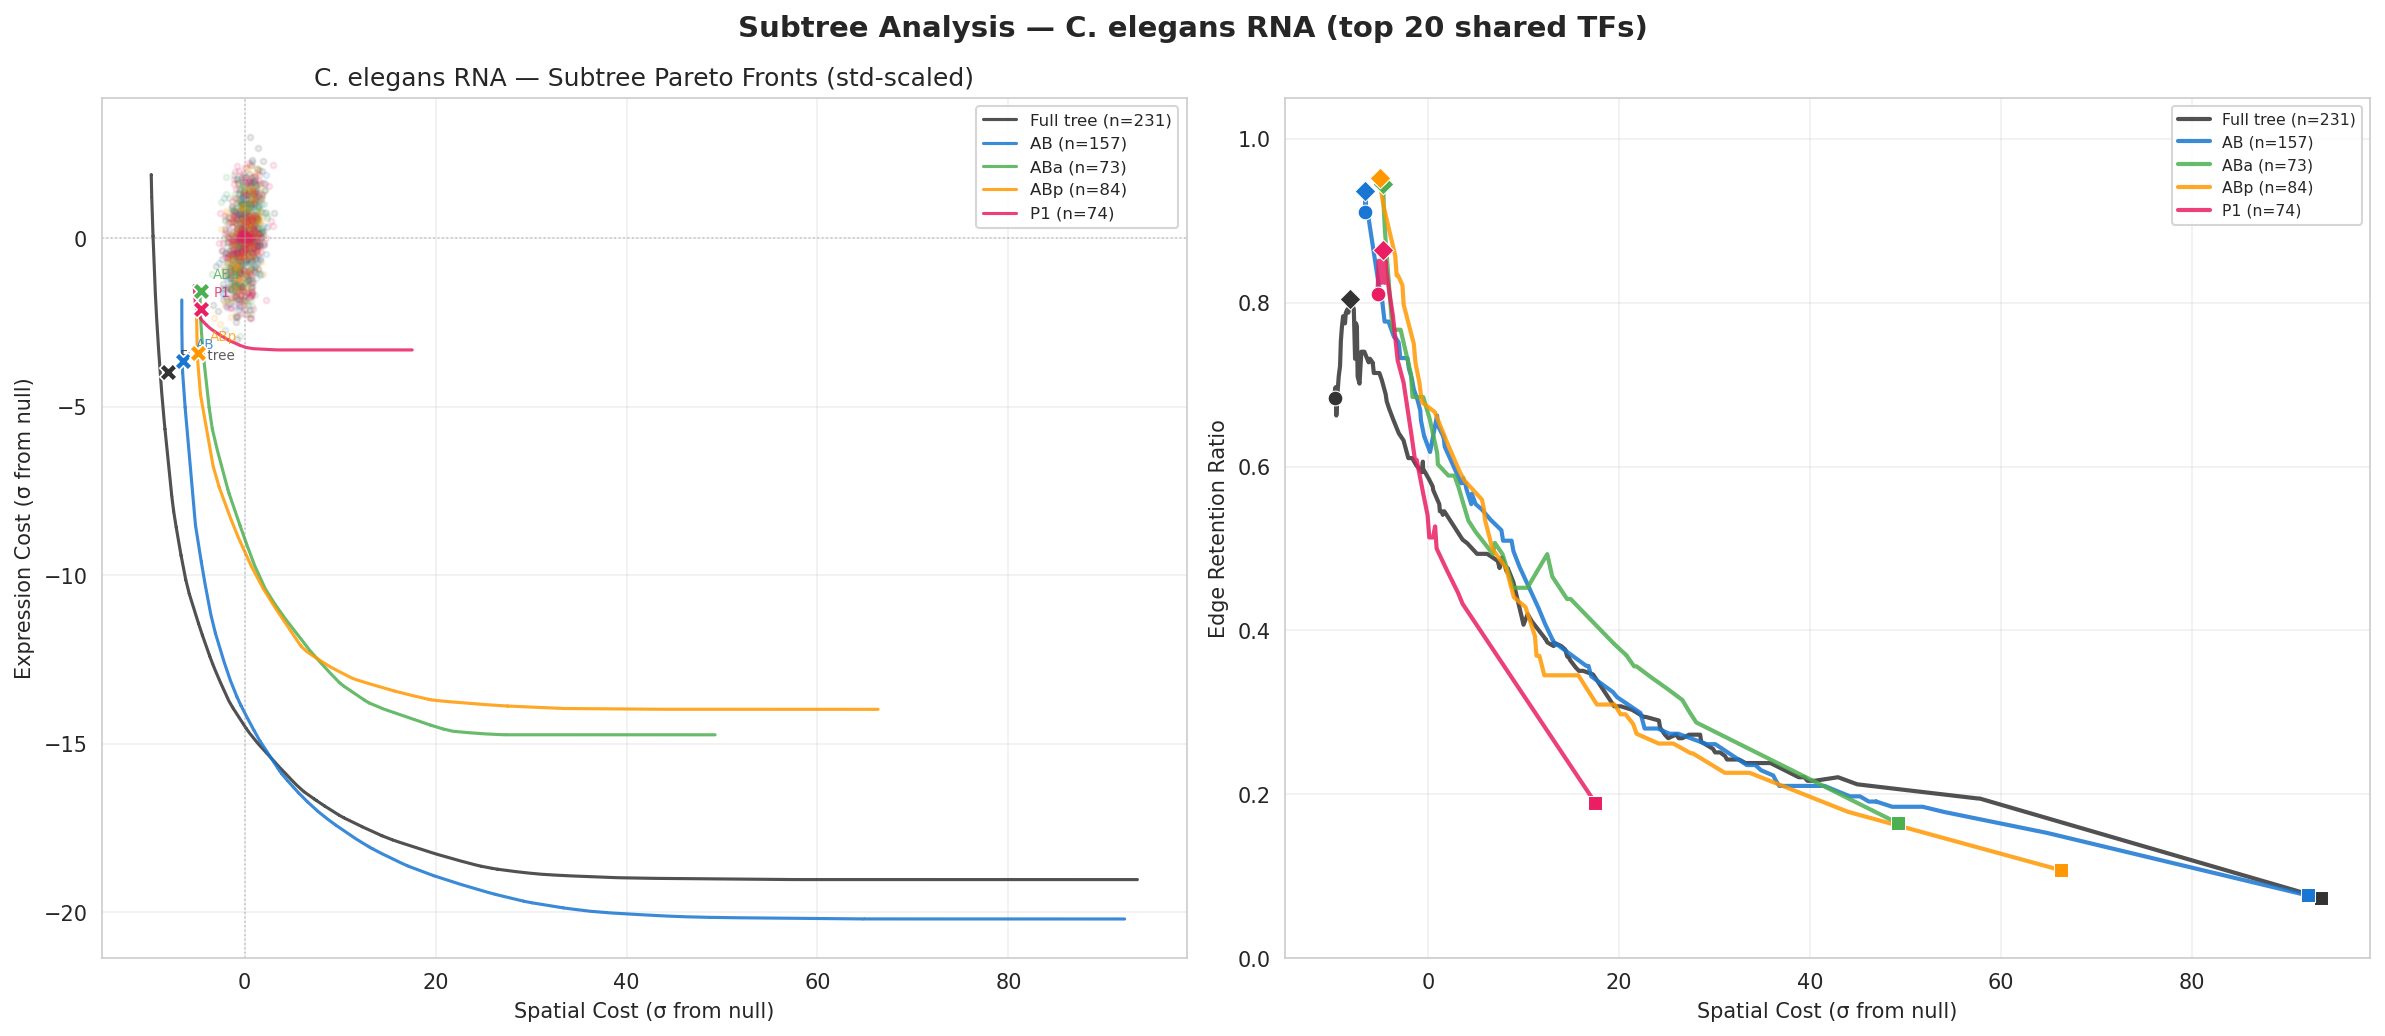

In [30]:
# ── Figure: C. elegans RNA — Subtree Pareto Fronts (std-scaled) ──
sub_colors = {'Full tree': '#333', 'AB': '#1976D2', 'ABa': '#4CAF50', 'ABp': '#FF9800', 'P1': '#E91E63'}
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))

for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    d = er_sub[label]
    color = sub_colors[label]
    n = len(d['tn'])

    # Compute random stats for this subtree
    sub_groups = build_cousin_groups(d['tn'], gp_map)
    sub_rs = compute_cousin_random_stats(d['xm'], d['em'], sub_groups, n_random=300, seed=42)

    # Std-scaled (z-scored) Pareto front
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(d['xm'], d['em'], d['tp'], sub_rs)

    # Lineage position in z-score units
    lx, le = lineage_std_position(d['xm'], d['em'], sub_rs)

    # Null cloud from first subtree only (all share similar null)
    ncx, ncy = get_null_cloud(sub_rs, max_points=250)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.10, zorder=0)

    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_l.annotate(f'{label}', (lx, le), xytext=(6, 6), textcoords='offset points',
                  fontsize=6.5, color=color, alpha=0.8)
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=2, alpha=0.85, label=f'{label} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(xyz_arr[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)

# Null reference
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)

ax_l.set_xlabel('Spatial Cost (σ from null)')
ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('C. elegans RNA — Subtree Pareto Fronts (std-scaled)', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Spatial Cost (σ from null)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=7.5, loc='best')
fig.suptitle('Subtree Analysis — C. elegans RNA (top 20 shared TFs)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 3c. C. briggsae — RNA-seq Expression (top 20 shared TFs)

In [31]:
# ── C. briggsae RNA subtree analysis ──
cb_sub = {}
for sroot in SUBTREES + ['Full']:
    label = sroot if sroot != 'Full' else 'Full tree'
    if sroot == 'Full':
        tn, tp = tn_cb, tp_cb
    else:
        tn, tp = collect_terminals(lineage_data, v_cb_rna, subtree=sroot)
    xm, em, _ = build_cost_matrices(tn, tp, xyz_cb, cb_rna, rna_sel)
    res = pareto_sweep(xm, em, tp)
    # Compute relative lineage-to-front distance (z-scored)
    sub_groups = build_cousin_groups(tn, gp_map)
    sub_rs = compute_cousin_random_stats(xm, em, sub_groups, n_random=300, seed=42)
    xyz_arr, exp_arr, _, _ = compute_std_scaled_pareto(xm, em, tp, sub_rs)
    lx, le = lineage_std_position(xm, em, sub_rs)
    rel_dist = relative_pareto_distance(xyz_arr, exp_arr, lx, le)
    cb_sub[label] = {'tn': tn, 'tp': tp, 'xm': xm, 'em': em, 'res': res, 'rel_pareto_dist': rel_dist}
    print(f"  {label:12s}: {len(tn):4d} cells | Expr ER={res['expr_opt_er']:.3f} | Max ER={res['max_er']:.3f} | Spatial ER={res['spatial_opt_er']:.3f} | Rel Dist={rel_dist:.3f}")

cb_sub_df = pd.DataFrame({
    'Subtree': list(cb_sub.keys()),
    'N Cells': [len(cb_sub[k]['tn']) for k in cb_sub],
    'Expr Opt ER': [cb_sub[k]['res']['expr_opt_er'] for k in cb_sub],
    'Max ER': [cb_sub[k]['res']['max_er'] for k in cb_sub],
    'Spatial Opt ER': [cb_sub[k]['res']['spatial_opt_er'] for k in cb_sub],
    'Closest Dist': [cb_sub[k]['res']['closest_dist'] for k in cb_sub],
    'Rel Pareto Dist': [round(cb_sub[k]['rel_pareto_dist'], 3) for k in cb_sub],
}).set_index('Subtree')
cb_sub_df

  AB          :   37 cells | Expr ER=0.243 | Max ER=0.892 | Spatial ER=0.838 | Rel Dist=0.051
  ABa         :   21 cells | Expr ER=0.381 | Max ER=1.000 | Spatial ER=0.905 | Rel Dist=0.000
  ABp         :   16 cells | Expr ER=0.250 | Max ER=1.000 | Spatial ER=0.875 | Rel Dist=0.000
  P1          :   32 cells | Expr ER=0.375 | Max ER=0.688 | Spatial ER=0.625 | Rel Dist=0.428


  Full tree   :   69 cells | Expr ER=0.130 | Max ER=0.754 | Spatial ER=0.493 | Rel Dist=0.216


,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist,Rel Pareto Dist
Subtree,,,,,,
AB,37,0.243243,0.891892,0.837838,0.040276,0.051
ABa,21,0.380952,1.000000,0.904762,0.000000,0.000
ABp,16,0.250000,1.000000,0.875000,0.000000,0.000
P1,32,0.375000,0.687500,0.625000,0.146396,0.428
Full tree,69,0.130435,0.753623,0.492754,0.244804,0.216


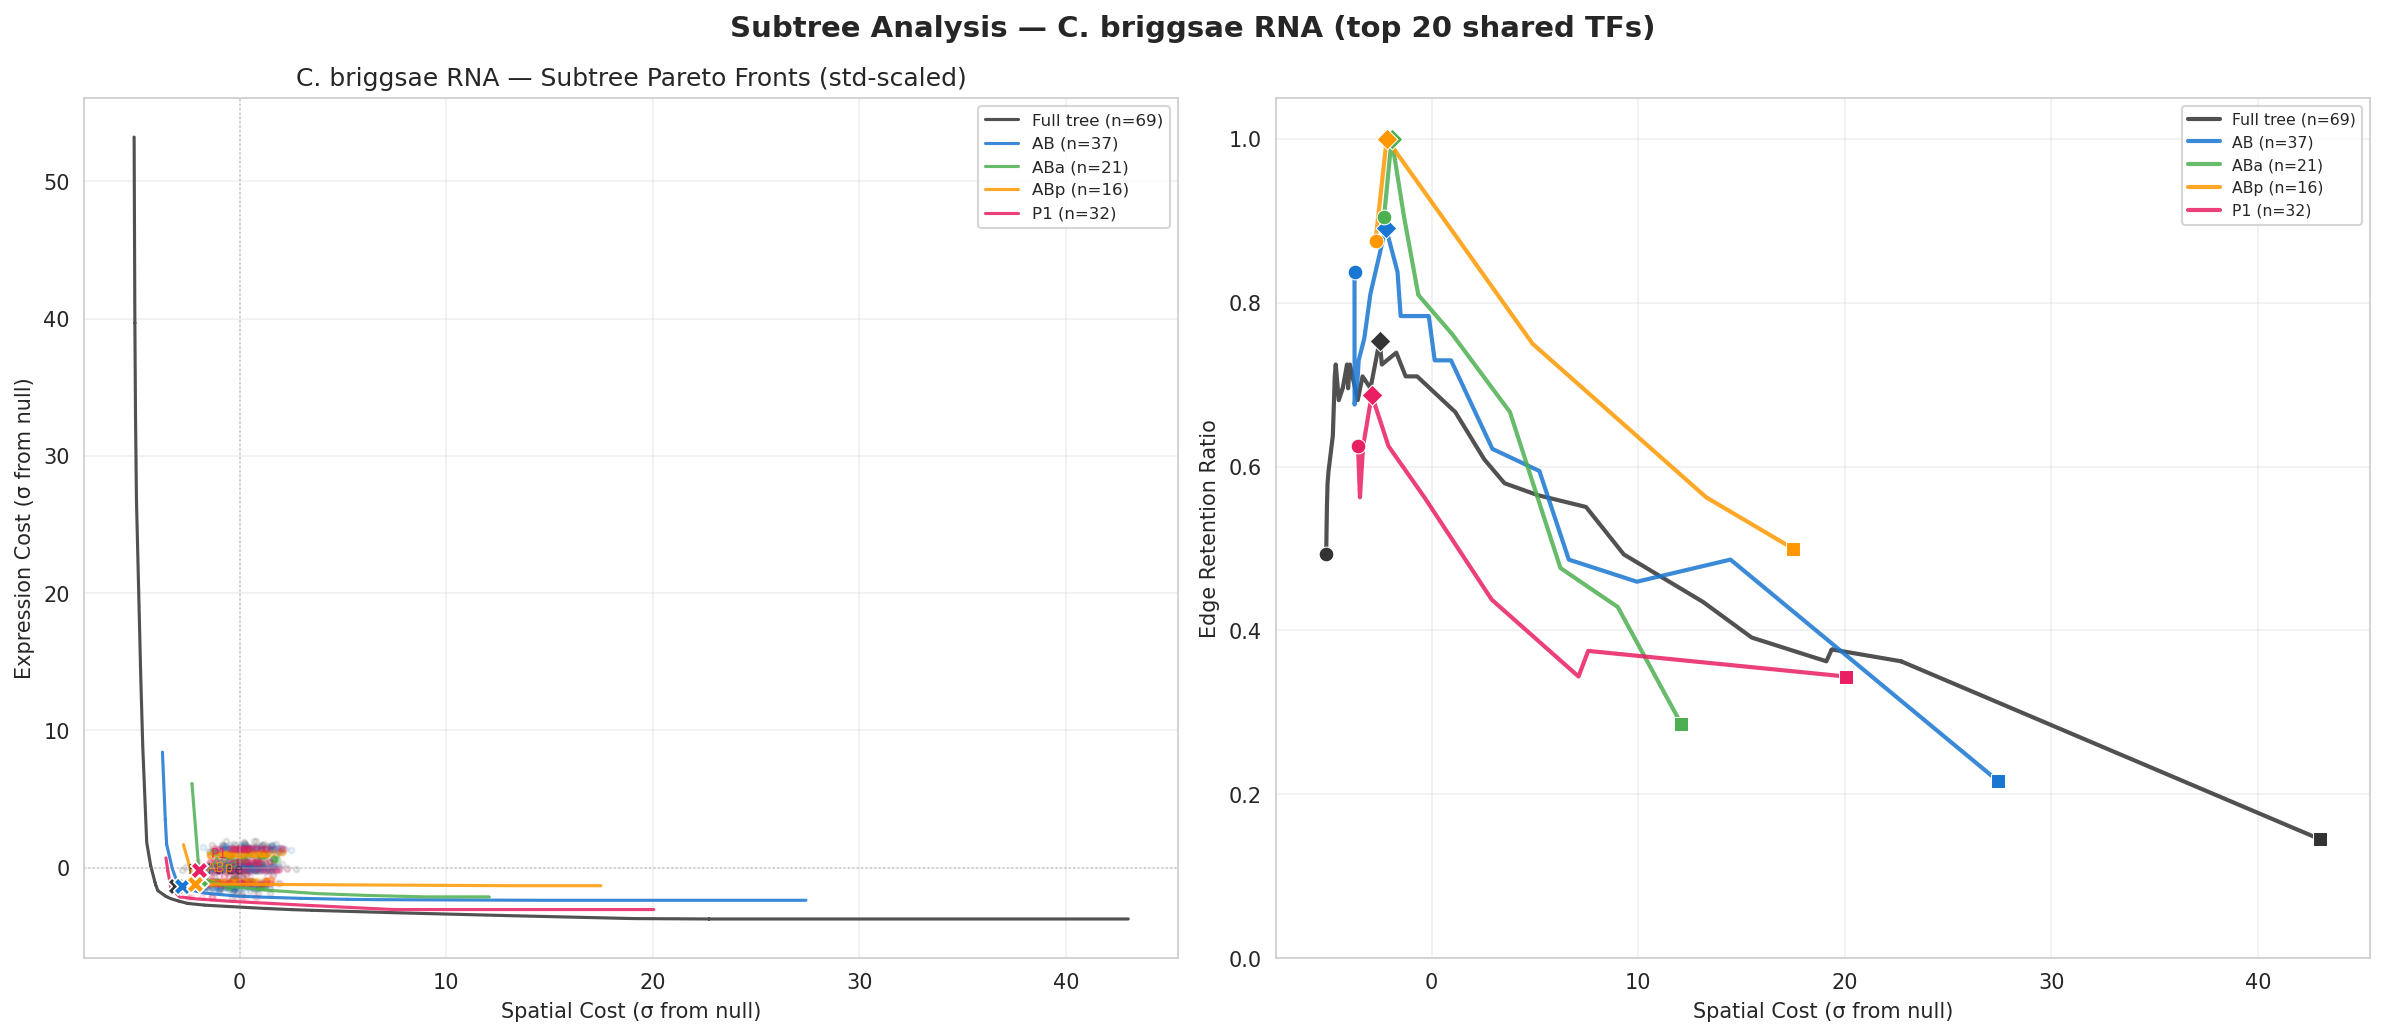

In [32]:
# ── Figure: C. briggsae RNA — Subtree Pareto Fronts (std-scaled) ──
sub_colors = {'Full tree': '#333', 'AB': '#1976D2', 'ABa': '#4CAF50', 'ABp': '#FF9800', 'P1': '#E91E63'}
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))

for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    d = cb_sub[label]
    color = sub_colors[label]
    n = len(d['tn'])

    # Compute random stats for this subtree
    sub_groups = build_cousin_groups(d['tn'], gp_map)
    sub_rs = compute_cousin_random_stats(d['xm'], d['em'], sub_groups, n_random=300, seed=42)

    # Std-scaled (z-scored) Pareto front
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(d['xm'], d['em'], d['tp'], sub_rs)

    # Lineage position in z-score units
    lx, le = lineage_std_position(d['xm'], d['em'], sub_rs)

    # Null cloud from first subtree only (all share similar null)
    ncx, ncy = get_null_cloud(sub_rs, max_points=250)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.10, zorder=0)

    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{label} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_l.annotate(f'{label}', (lx, le), xytext=(6, 6), textcoords='offset points',
                  fontsize=6.5, color=color, alpha=0.8)
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=2, alpha=0.85, label=f'{label} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(xyz_arr[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)

# Null reference
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)

ax_l.set_xlabel('Spatial Cost (σ from null)')
ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('C. briggsae RNA — Subtree Pareto Fronts (std-scaled)', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Spatial Cost (σ from null)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=7.5, loc='best')
fig.suptitle('Subtree Analysis — C. briggsae RNA (top 20 shared TFs)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 3d. Cross-Dataset Subtree Comparison

In [33]:
# ── Side-by-side Expr Opt ER comparison across datasets ──
print(f"{'Subtree':12s} | {'Protein ER':12s} | {'C.elegans RNA ER':16s} | {'C.briggsae RNA ER':16s}")
print("-" * 70)
for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    pe = prot_sub[label]['res']['expr_opt_er']
    ee = er_sub[label]['res']['expr_opt_er']
    ce = cb_sub[label]['res']['expr_opt_er']
    print(f"{label:12s} | {pe:.3f}         | {ee:.3f}              | {ce:.3f}")

print(f"\n{'Subtree':12s} | {'Protein Max ER':14s} | {'C.elegans RNA Max ER':18s} | {'C.briggsae RNA Max ER':18s}")
print("-" * 75)
for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    pe = prot_sub[label]['res']['max_er']
    ee = er_sub[label]['res']['max_er']
    ce = cb_sub[label]['res']['max_er']
    print(f"{label:12s} | {pe:.3f}           | {ee:.3f}                | {ce:.3f}")


Subtree      | Protein ER   | C.elegans RNA ER | C.briggsae RNA ER
----------------------------------------------------------------------
Full tree    | 0.204         | 0.074              | 0.130
AB           | 0.218         | 0.083              | 0.243
ABa          | 0.302         | 0.137              | 0.381
ABp          | 0.245         | 0.107              | 0.250
P1           | 0.337         | 0.176              | 0.375

Subtree      | Protein Max ER | C.elegans RNA Max ER | C.briggsae RNA Max ER
---------------------------------------------------------------------------
Full tree    | 0.819           | 0.805                | 0.754
AB           | 0.838           | 0.936                | 0.892
ABa          | 0.887           | 0.945                | 1.000
ABp          | 0.882           | 0.952                | 1.000
P1           | 0.880           | 0.865                | 0.688


### 3e. Extended Subtree Analysis — C. elegans Protein (top 20)

All 47 lineage subtrees with >10 terminal cells.  Each subtree is annotated with its
**dominant cell type** to reveal how type purity affects the Pareto metrics.

In [34]:
# ── Cell type loading (compact, inline for this section) ──
MERGE_MAP = {
    'neuron':'neuron','muscle':'muscle','repro':'reproduction',
    'hypoderm':'epithelium','epithelium':'epithelium',
    'sheath':'glial','socket':'glial','coelomocyte':'coelomocyte',
    'excretory':'excretory','mesoderm':'mesoderm','other':'other',
    'intestine':'alimentary','valve':'alimentary','marginal':'alimentary',
    'gland':'alimentary','rectal':'alimentary',
    'tail':'programmed_death','programmed_death':'programmed_death','blast':'programmed_death',
}
_ct_df = pd.read_csv('data/2023-06-29_entropy_cell_key_V2.csv')
_lineage_to_type = {}
for _, row in _ct_df.iterrows():
    ln = row.get('wormweb.lineage',''); rt = row.get('wormweb.type','')
    if pd.notna(rt) and rt.strip():
        _lineage_to_type[ln] = MERGE_MAP.get(rt.strip(), rt.strip())
def get_ct(lin): return _lineage_to_type.get(lin, 'programmed_death')

def type_shannon_entropy(tn):
    """Shannon entropy of merged cell-type distribution (in nats).
    0 = pure single type; higher = more mixed."""
    from collections import Counter
    counts = Counter(get_ct(n) for n in tn)
    total = sum(counts.values())
    probs = np.array([c / total for c in counts.values()])
    return float(-np.sum(probs * np.log(probs + 1e-12)))

# ── Enumerate all subtrees with >10 terminal cells ──
terminal_descendants = {}

def postorder_collect(node, parent=None):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    my_terms = []
    if len(children) == 0:
        p_lookup_name = map_names(parent['did']) if parent else None
        if (lookup_name in v_prot and p_lookup_name in v_prot):
            my_terms.append((lookup_name, p_lookup_name))
    else:
        for child in children:
            my_terms.extend(postorder_collect(child, node))
    terminal_descendants[lookup_name] = my_terms
    return my_terms

postorder_collect(lineage_data)
qualifying = [(n, t) for n, t in terminal_descendants.items() if len(t) >= 10]
qualifying.sort(key=lambda x: -len(x[1]))
print(f"Subtrees with >=10 terminal cells: {len(qualifying)}")

# ── Run Pareto for each ──
ext_sub = {}
for sname, term_list in qualifying:
    tn = [t[0] for t in term_list]; tp = [t[1] for t in term_list]; n = len(tn)
    # Cell type composition & Shannon entropy
    tc = defaultdict(int)
    for node in tn: tc[get_ct(node)] += 1
    dtype = max(tc, key=tc.get)
    entropy = type_shannon_entropy(tn)
    xm, em, _ = build_cost_matrices(tn, tp, xyz_ce, protein_exp, prot_sel)
    res = pareto_sweep(xm, em, tp)
    # Compute relative lineage-to-front distance (z-scored)
    sub_groups = build_cousin_groups(tn, gp_map)
    sub_rs = compute_cousin_random_stats(xm, em, sub_groups, n_random=300, seed=42)
    xyz_arr, exp_arr, _, _ = compute_std_scaled_pareto(xm, em, tp, sub_rs)
    lx, le = lineage_std_position(xm, em, sub_rs)
    rel_dist = relative_pareto_distance(xyz_arr, exp_arr, lx, le)
    ext_sub[sname] = {'tn': tn, 'tp': tp, 'xm': xm, 'em': em, 'res': res,
                      'n': n, 'dominant_type': dtype, 'type_entropy': entropy,
                      'type_dist': dict(tc), 'rel_pareto_dist': rel_dist}

print(f"Ran Pareto for {len(ext_sub)} subtrees")

Subtrees with >=10 terminal cells: 49


Ran Pareto for 49 subtrees


In [35]:
# ── Extended subtree summary table (top 25 by size) ──
ext_rows = []
for name in sorted(ext_sub, key=lambda k: -ext_sub[k]['n']):
    d = ext_sub[name]; r = d['res']
    type_str = ', '.join(f'{t}({c})' for t, c in sorted(d['type_dist'].items(), key=lambda x: -x[1])[:3])
    ext_rows.append({
        'Subtree': name, 'N': d['n'],
        'Expr Opt ER': round(r['expr_opt_er'], 3), 'Max ER': round(r['max_er'], 3),
        'Spatial Opt ER': round(r['spatial_opt_er'], 3), 'Closest Dist': round(r['closest_dist'], 3),
        'Rel Pareto Dist': round(d['rel_pareto_dist'], 3),
        'Type Entropy': round(d['type_entropy'], 3),
        'Dominant Type': d['dominant_type'],
        'Top 3 Types': type_str,
    })
ext_df = pd.DataFrame(ext_rows).set_index('Subtree')
print(f"Total subtrees: {len(ext_df)}")
ext_df.head(25)

Total subtrees: 49


,N,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist,Rel Pareto Dist,Type Entropy,Dominant Type,Top 3 Types
Subtree,,,,,,,,,
P0,299,0.204,0.819,0.599,1.132,0.142,1.771,neuron,"neuron(97), muscle(61), epithelium(57)"
AB,216,0.218,0.838,0.671,0.464,0.082,1.611,neuron,"neuron(95), epithelium(44), programmed_death(27)"
ABp,110,0.245,0.882,0.773,0.348,0.138,1.324,neuron,"neuron(59), epithelium(24), programmed_death(12)"
ABa,106,0.302,0.887,0.679,0.175,0.059,1.742,neuron,"neuron(36), epithelium(20), programmed_death(15)"
P1,83,0.337,0.880,0.771,0.191,0.070,1.284,muscle,"muscle(49), epithelium(13), alimentary(9)"
ABpr,60,0.367,0.867,0.800,0.262,0.250,1.212,neuron,"neuron(37), epithelium(9), programmed_death(6)"
ABal,59,0.424,0.932,0.780,0.273,0.146,1.566,neuron,"neuron(26), programmed_death(11), glial(9)"
EMS,55,0.327,0.909,0.800,0.114,0.044,0.971,muscle,"muscle(37), alimentary(9), programmed_death(7)"
MS,53,0.302,0.906,0.792,0.114,0.044,0.935,muscle,"muscle(37), alimentary(7), programmed_death(7)"


In [36]:
# ── Subtrees with low type entropy (<0.8 nat) = type-homogeneous ──
pure = ext_df[ext_df['Type Entropy'] < 0.8].sort_values('Type Entropy')
print(f"Subtrees with Type Entropy < 0.8 (type-homogeneous): {len(pure)}")
pure[['N', 'Expr Opt ER', 'Max ER', 'Spatial Opt ER', 'Rel Pareto Dist', 'Type Entropy', 'Dominant Type']].head(15)

Subtrees with Type Entropy < 0.8 (type-homogeneous): 15


,N,Expr Opt ER,Max ER,Spatial Opt ER,Rel Pareto Dist,Type Entropy,Dominant Type
Subtree,,,,,,,
D,12,0.417,0.833,0.833,0.049,-0.000,muscle
C,14,0.286,0.786,0.786,0.239,0.257,epithelium
ABprpaa,11,0.636,1.000,0.818,0.000,0.305,neuron
ABplpaa,10,1.000,1.000,1.000,0.000,0.325,neuron
P3,14,0.500,0.857,0.857,0.050,0.410,muscle
ABarpa,11,0.364,1.000,0.818,0.000,0.474,epithelium
ABarapp,10,0.600,1.000,1.000,0.000,0.500,neuron
MSpp,13,0.462,0.615,0.538,0.113,0.540,muscle
ABprpa,27,0.556,0.926,0.852,0.015,0.574,neuron


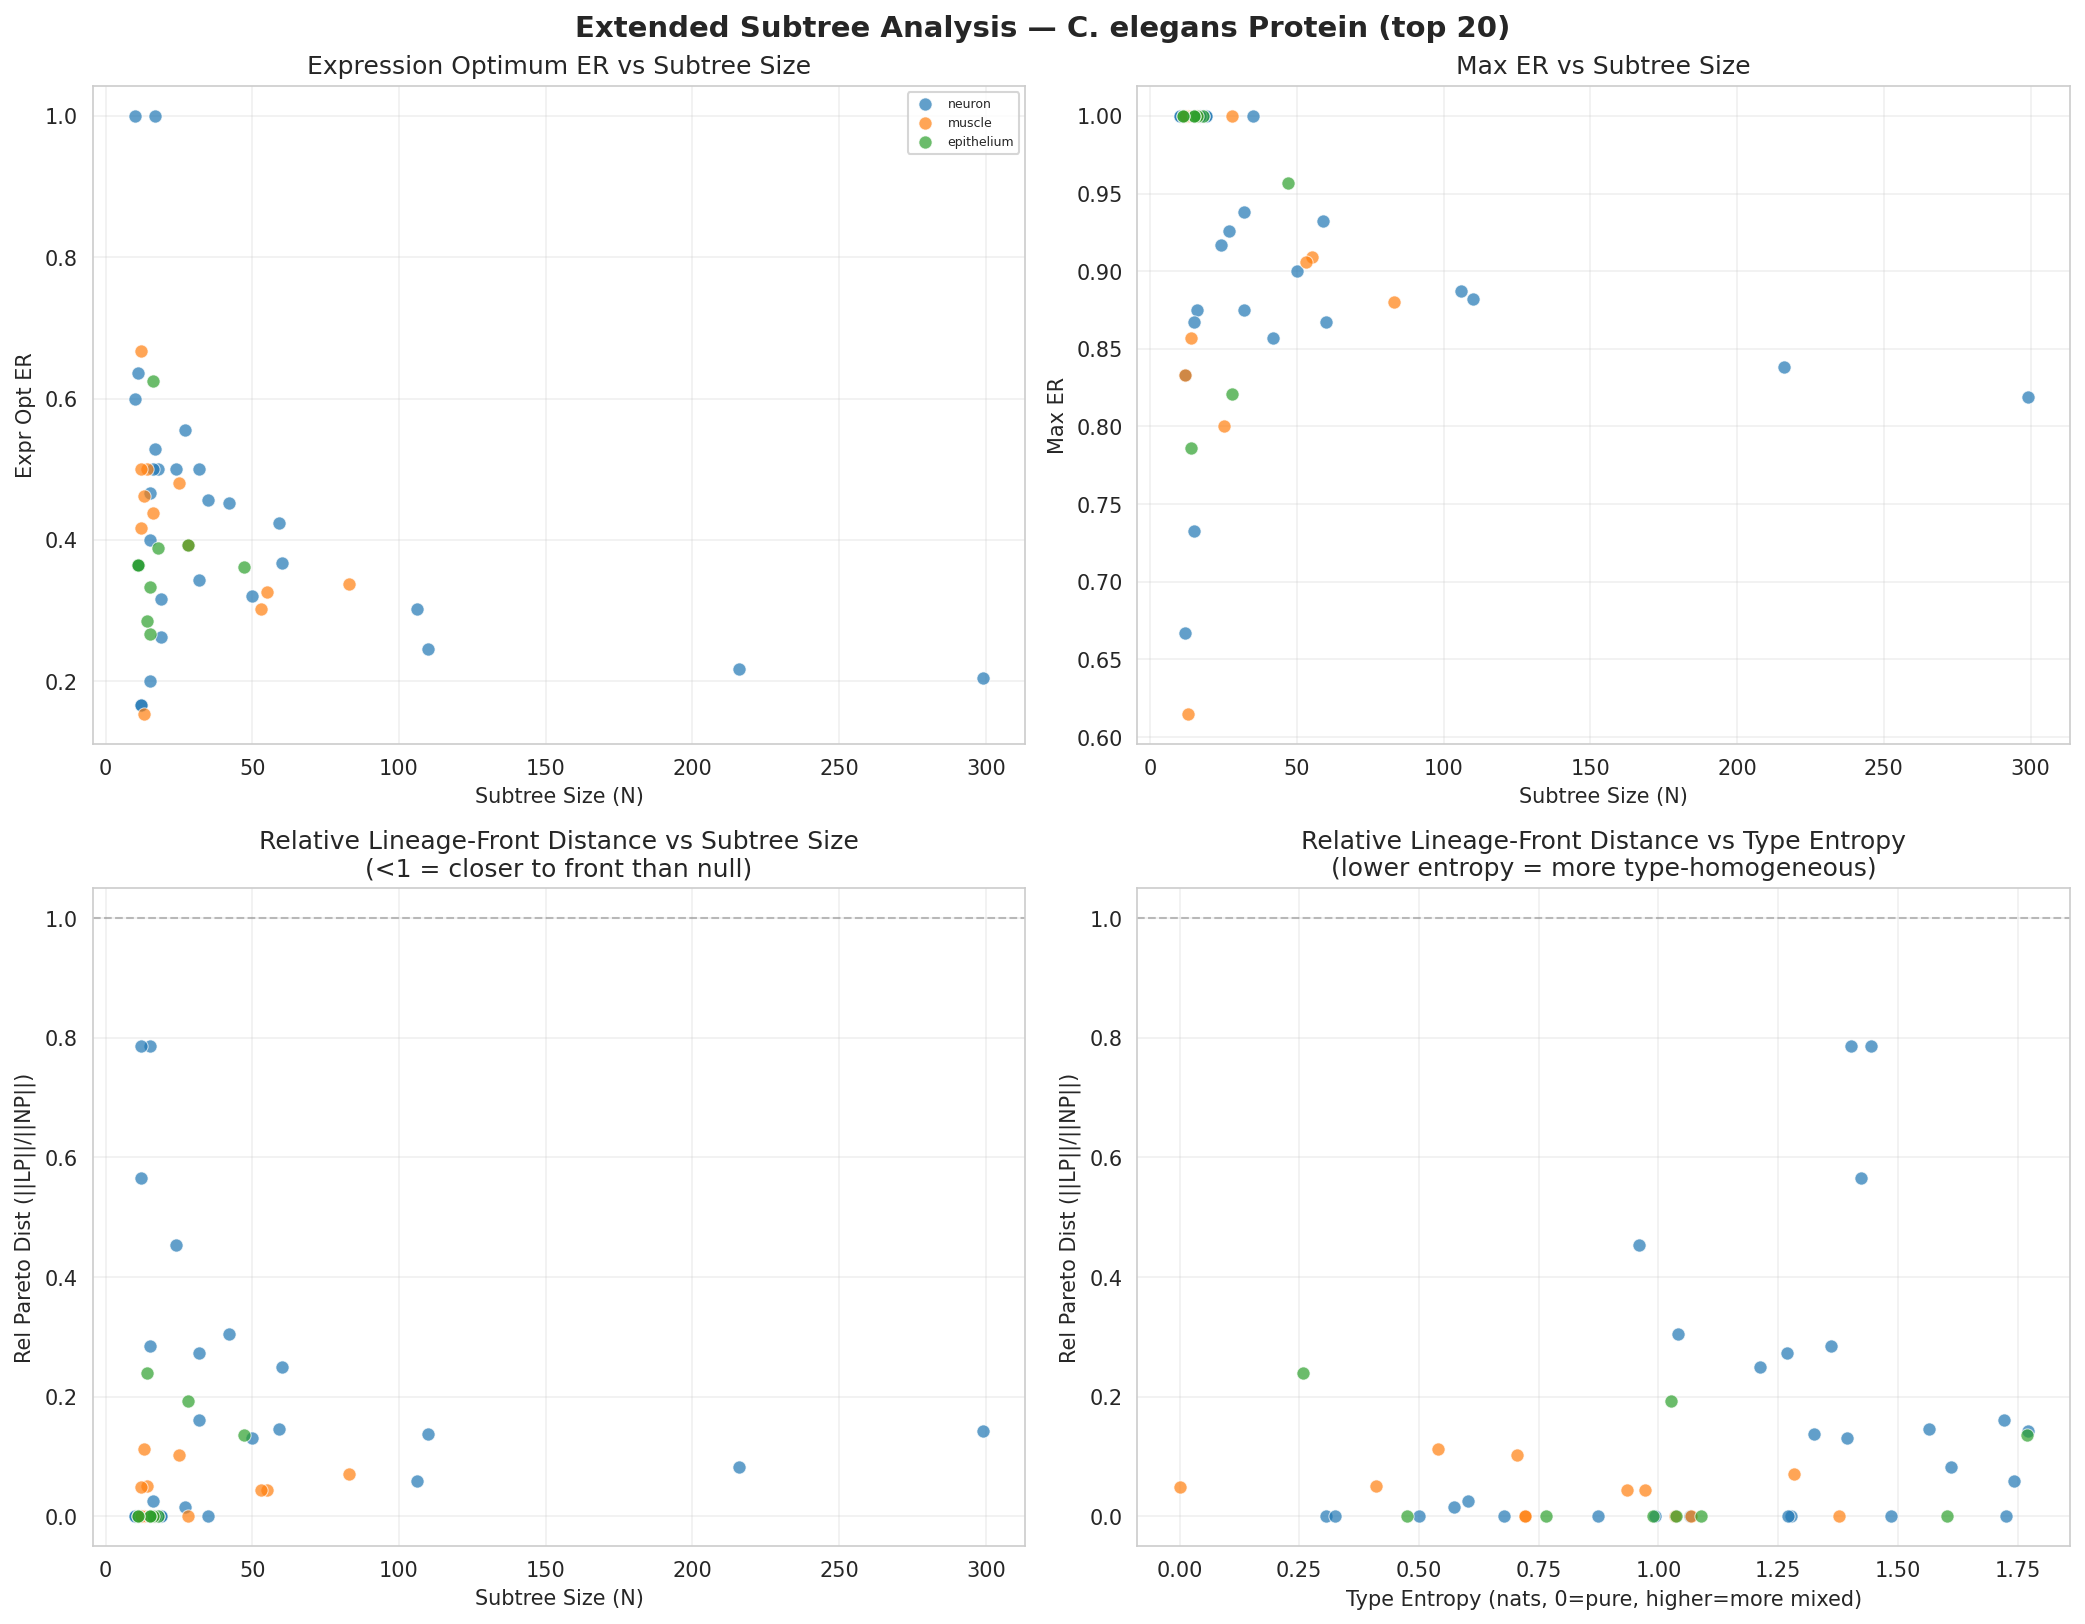

In [37]:
# ── Scatter: Pareto metrics vs subtree size & type entropy ──
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
type_list = ext_df['Dominant Type'].unique()
type_colors = {t: plt.cm.tab10(i % 10) for i, t in enumerate(type_list)}

# 1) Expr Opt ER vs N
ax = axes[0, 0]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'N'], ext_df.loc[mask, 'Expr Opt ER'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Subtree Size (N)'); ax.set_ylabel('Expr Opt ER')
ax.set_title('Expression Optimum ER vs Subtree Size'); ax.legend(fontsize=6, loc='best'); ax.grid(True, alpha=0.3)

# 2) Max ER vs N
ax = axes[0, 1]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'N'], ext_df.loc[mask, 'Max ER'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Subtree Size (N)'); ax.set_ylabel('Max ER')
ax.set_title('Max ER vs Subtree Size'); ax.grid(True, alpha=0.3)

# 3) Rel Pareto Dist vs N
ax = axes[1, 0]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'N'], ext_df.loc[mask, 'Rel Pareto Dist'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('Subtree Size (N)'); ax.set_ylabel('Rel Pareto Dist (||LP||/||NP||)')
ax.set_title('Relative Lineage-Front Distance vs Subtree Size\n(<1 = closer to front than null)')
ax.grid(True, alpha=0.3)

# 4) Rel Pareto Dist vs Type Entropy (0 = pure, higher = more mixed)
ax = axes[1, 1]
for t in type_list:
    mask = ext_df['Dominant Type'] == t
    ax.scatter(ext_df.loc[mask, 'Type Entropy'], ext_df.loc[mask, 'Rel Pareto Dist'],
               c=[type_colors[t]], label=t, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('Type Entropy (nats, 0=pure, higher=more mixed)'); ax.set_ylabel('Rel Pareto Dist (||LP||/||NP||)')
ax.set_title('Relative Lineage-Front Distance vs Type Entropy\n(lower entropy = more type-homogeneous)')
ax.grid(True, alpha=0.3)

fig.suptitle('Extended Subtree Analysis — C. elegans Protein (top 20)', fontsize=14, fontweight='bold')
fig.tight_layout(); plt.show()

---
## 4. Edge Perturbation Analysis

How optimal is the real lineage's edge configuration compared to *nearby* configurations?
For each terminal cell, the real lineage assigns it to its own parent (the identity matching).
We perturb this by swapping k edges and count how often the swap **improves** total cost.

- **k=2**: enumerate all C(n,2) direct edge swaps
- **k=3**: enumerate all C(n,3) cyclic 3-edge permutations (two per triple: forward & backward 3-cycle)

Three rates are reported:
- **Save XYZ%**: fraction of swaps that reduce spatial cost
- **Save Exp%**: fraction of swaps that reduce expression cost
- **Save Both%**: fraction of swaps that reduce *both* costs simultaneously (Pareto dominate)

If the real lineage sits at a local Pareto optimum, very few swaps should save both costs.
Large Save Both% implies many nearby configurations are strictly better.

Tested on all three full-tree cross-species configs and the five C. elegans protein subtrees.

In [38]:
# ── Edge perturbation: enumerate all C(n,2) & C(n,3) edge swaps ──
perturbation_configs = [
    # Full trees (all at full developmental cutoffs)
    ('CE Prot (T=255)',     xm_prot,     em_prot),
    ('CE RNA  (T=255)',     xm_er,       em_er),
    ('CB RNA (T=143)',  xm_cb_new,   em_cb_new),
]

pert_results = []
for label, xm, em in perturbation_configs:
    pert_results.append(run_perturbation_test(xm, em, label))

# Protein subtrees (T=255)
for label in ['Full tree', 'AB', 'ABa', 'ABp', 'P1']:
    d = prot_sub[label]
    pert_results.append(run_perturbation_test(d['xm'], d['em'], f'CE Prot Subtree: {label}'))

  CE Prot (T=255)                n= 299 | C2=   44551  save_xyz=  0.17%  save_exp=  3.37%  save_both= 0.02% | C3=  8821098  save_xyz=  0.00%  save_exp=  1.07%  save_both= 0.00%


  CE RNA  (T=255)                n= 231 | C2=   26565  save_xyz=  0.14%  save_exp=  7.42%  save_both= 0.01% | C3=  4055590  save_xyz=  0.00%  save_exp=  2.85%  save_both= 0.00%


  CB RNA (T=143)                 n= 209 | C2=   21736  save_xyz=  0.85%  save_exp=  7.71%  save_both= 0.03% | C3=  2999568  save_xyz=  0.10%  save_exp=  2.67%  save_both= 0.00%


  CE Prot Subtree: Full tree     n= 299 | C2=   44551  save_xyz=  0.17%  save_exp=  3.37%  save_both= 0.02% | C3=  8821098  save_xyz=  0.00%  save_exp=  1.07%  save_both= 0.00%


  CE Prot Subtree: AB            n= 216 | C2=   23220  save_xyz=  0.23%  save_exp=  3.63%  save_both= 0.03% | C3=  3312720  save_xyz=  0.00%  save_exp=  1.33%  save_both= 0.00%
  CE Prot Subtree: ABa           n= 106 | C2=    5565  save_xyz=  0.40%  save_exp=  3.52%  save_both= 0.02% | C3=   385840  save_xyz=  0.01%  save_exp=  1.08%  save_both= 0.00%
  CE Prot Subtree: ABp           n= 110 | C2=    5995  save_xyz=  0.38%  save_exp=  4.90%  save_both= 0.05% | C3=   431640  save_xyz=  0.01%  save_exp=  1.91%  save_both= 0.00%
  CE Prot Subtree: P1            n=  83 | C2=    3403  save_xyz=  0.44%  save_exp=  5.44%  save_both= 0.09% | C3=   183762  save_xyz=  0.02%  save_exp=  1.45%  save_both= 0.00%


In [39]:
# ── Perturbation results table ──
pert_rows = []
for r in pert_results:
    pert_rows.append({
        'Config': r['label'], 'N': r['n'],
        'C2 Total': r['c2']['total'],
        'C2 Save XYZ%': r['c2']['pct_xyz'],
        'C2 Save Exp%': r['c2']['pct_exp'],
        'C2 Save Both%': r['c2']['pct_both'],
        'C3 Total': r['c3']['total'],
        'C3 Save XYZ%': r['c3']['pct_xyz'],
        'C3 Save Exp%': r['c3']['pct_exp'],
        'C3 Save Both%': r['c3']['pct_both'],
    })
pert_df = pd.DataFrame(pert_rows).set_index('Config')
pert_df

,N,C2 Total,C2 Save XYZ%,C2 Save Exp%,C2 Save Both%,C3 Total,C3 Save XYZ%,C3 Save Exp%,C3 Save Both%
Config,,,,,,,,,
CE Prot (T=255),299,44551,0.173,3.365,0.020,8821098,0.003,1.074,0.000
CE RNA (T=255),231,26565,0.139,7.423,0.011,4055590,0.002,2.850,0.000
CB RNA (T=143),209,21736,0.847,7.706,0.032,2999568,0.096,2.669,0.001
CE Prot Subtree: Full tree,299,44551,0.173,3.365,0.020,8821098,0.003,1.074,0.000
CE Prot Subtree: AB,216,23220,0.228,3.630,0.026,3312720,0.004,1.331,0.000
CE Prot Subtree: ABa,106,5565,0.395,3.522,0.018,385840,0.012,1.078,0.000
CE Prot Subtree: ABp,110,5995,0.384,4.904,0.050,431640,0.007,1.908,0.001
CE Prot Subtree: P1,83,3403,0.441,5.436,0.088,183762,0.017,1.450,0.002


---
## 5. Cell Type Analysis — C. elegans Protein (top 20)

Terminal cells are partitioned by their WormWeb cell type annotation.
Top 3 types (neuron, muscle, epithelium) shown individually, plus
remaining minor types bundled as "rest" and apoptotic cells as a separate group.

In [40]:
# ── Cell type loading ──
MERGE_MAP = {
    'neuron':'neuron','muscle':'muscle','repro':'reproduction',
    'hypoderm':'epithelium','epithelium':'epithelium',
    'sheath':'glial','socket':'glial','coelomocyte':'coelomocyte',
    'excretory':'excretory','mesoderm':'mesoderm','other':'other',
    'intestine':'alimentary','valve':'alimentary','marginal':'alimentary',
    'gland':'alimentary','rectal':'alimentary',
    'tail':'programmed_death','programmed_death':'programmed_death','blast':'programmed_death',
}
ct_df = pd.read_csv('data/2023-06-29_entropy_cell_key_V2.csv')
lineage_to_type = {}
for _, row in ct_df.iterrows():
    ln = row.get('wormweb.lineage',''); rt = row.get('wormweb.type','')
    if pd.notna(rt) and rt.strip():
        lineage_to_type[ln] = MERGE_MAP.get(rt.strip(), rt.strip())

def get_type(lin): return lineage_to_type.get(lin, 'programmed_death')

# Map protein terminal cells to types
type_counts = defaultdict(int)
node_type = {}
for n in tn_prot:
    ct = get_type(n); node_type[n] = ct; type_counts[ct] += 1

sorted_types = sorted(type_counts.items(), key=lambda x: -x[1])
print("Cell type distribution:")
for ct, cnt in sorted_types: print(f"  {ct:20s}: {cnt:4d}")

# Top 3 + rest + apoptotic
non_apop = [(ct,cnt) for ct,cnt in sorted_types if ct != 'programmed_death']
apop_cnt = type_counts.get('programmed_death', 0)
top3 = non_apop[:3]
rest_cnt = sum(cnt for ct,cnt in non_apop[3:])
groups = [(ct,cnt) for ct,cnt in top3] + [('rest (other types)', rest_cnt), ('programmed_death', apop_cnt)]

print(f"\nAnalysis groups:")
for ct, cnt in groups: print(f"  {ct:20s}: {cnt:4d}")


Cell type distribution:
  neuron              :   97
  muscle              :   61
  epithelium          :   57
  programmed_death    :   34
  glial               :   20
  alimentary          :   20
  excretory           :    4
  other               :    3
  reproduction        :    2
  mesoderm            :    1

Analysis groups:
  neuron              :   97
  muscle              :   61
  epithelium          :   57
  rest (other types)  :   50
  programmed_death    :   34


In [41]:
# ── Run Pareto for each cell type group ──
ct_results = {}
for gname, _ in groups:
    if gname == 'rest (other types)':
        included = set(ct for ct,cnt in non_apop[3:])
    elif gname == 'programmed_death':
        included = {'programmed_death'}
    else:
        included = {gname}

    gn, gp = [], []
    for n, p in zip(tn_prot, tp_prot):
        if node_type.get(n, 'programmed_death') in included and n in xyz_ce and p in xyz_ce:
            gn.append(n); gp.append(p)

    if len(gn) < 10:
        print(f"  {gname}: {len(gn)} cells — too few, skipping")
        continue

    xm, em, _ = build_cost_matrices(gn, gp, xyz_ce, protein_exp, prot_sel)
    res = pareto_sweep(xm, em, gp)
    ct_results[gname] = {'tn': gn, 'tp': gp, 'xm': xm, 'em': em, 'res': res}
    print(f"  {gname:20s}: {len(gn):4d} cells | Expr ER={res['expr_opt_er']:.3f} | Max ER={res['max_er']:.3f} | Spatial ER={res['spatial_opt_er']:.3f}")

ct_df = pd.DataFrame({
    'Cell Type': list(ct_results.keys()),
    'N Cells': [len(ct_results[k]['tn']) for k in ct_results],
    'Expr Opt ER': [ct_results[k]['res']['expr_opt_er'] for k in ct_results],
    'Max ER': [ct_results[k]['res']['max_er'] for k in ct_results],
    'Spatial Opt ER': [ct_results[k]['res']['spatial_opt_er'] for k in ct_results],
    'Closest Dist': [ct_results[k]['res']['closest_dist'] for k in ct_results],
}).set_index('Cell Type')
ct_df


  neuron              :   97 cells | Expr ER=0.227 | Max ER=0.938 | Spatial ER=0.897
  muscle              :   61 cells | Expr ER=0.311 | Max ER=0.902 | Spatial ER=0.754


  epithelium          :   57 cells | Expr ER=0.193 | Max ER=0.947 | Spatial ER=0.912
  rest (other types)  :   50 cells | Expr ER=0.420 | Max ER=1.000 | Spatial ER=0.960
  programmed_death    :   34 cells | Expr ER=0.353 | Max ER=0.824 | Spatial ER=0.706


,N Cells,Expr Opt ER,Max ER,Spatial Opt ER,Closest Dist
Cell Type,,,,,
neuron,97,0.226804,0.938144,0.896907,0.042358
muscle,61,0.311475,0.901639,0.754098,0.132772
epithelium,57,0.192982,0.947368,0.912281,0.086565
rest (other types),50,0.420000,1.000000,0.960000,0.000000
programmed_death,34,0.352941,0.823529,0.705882,0.108225


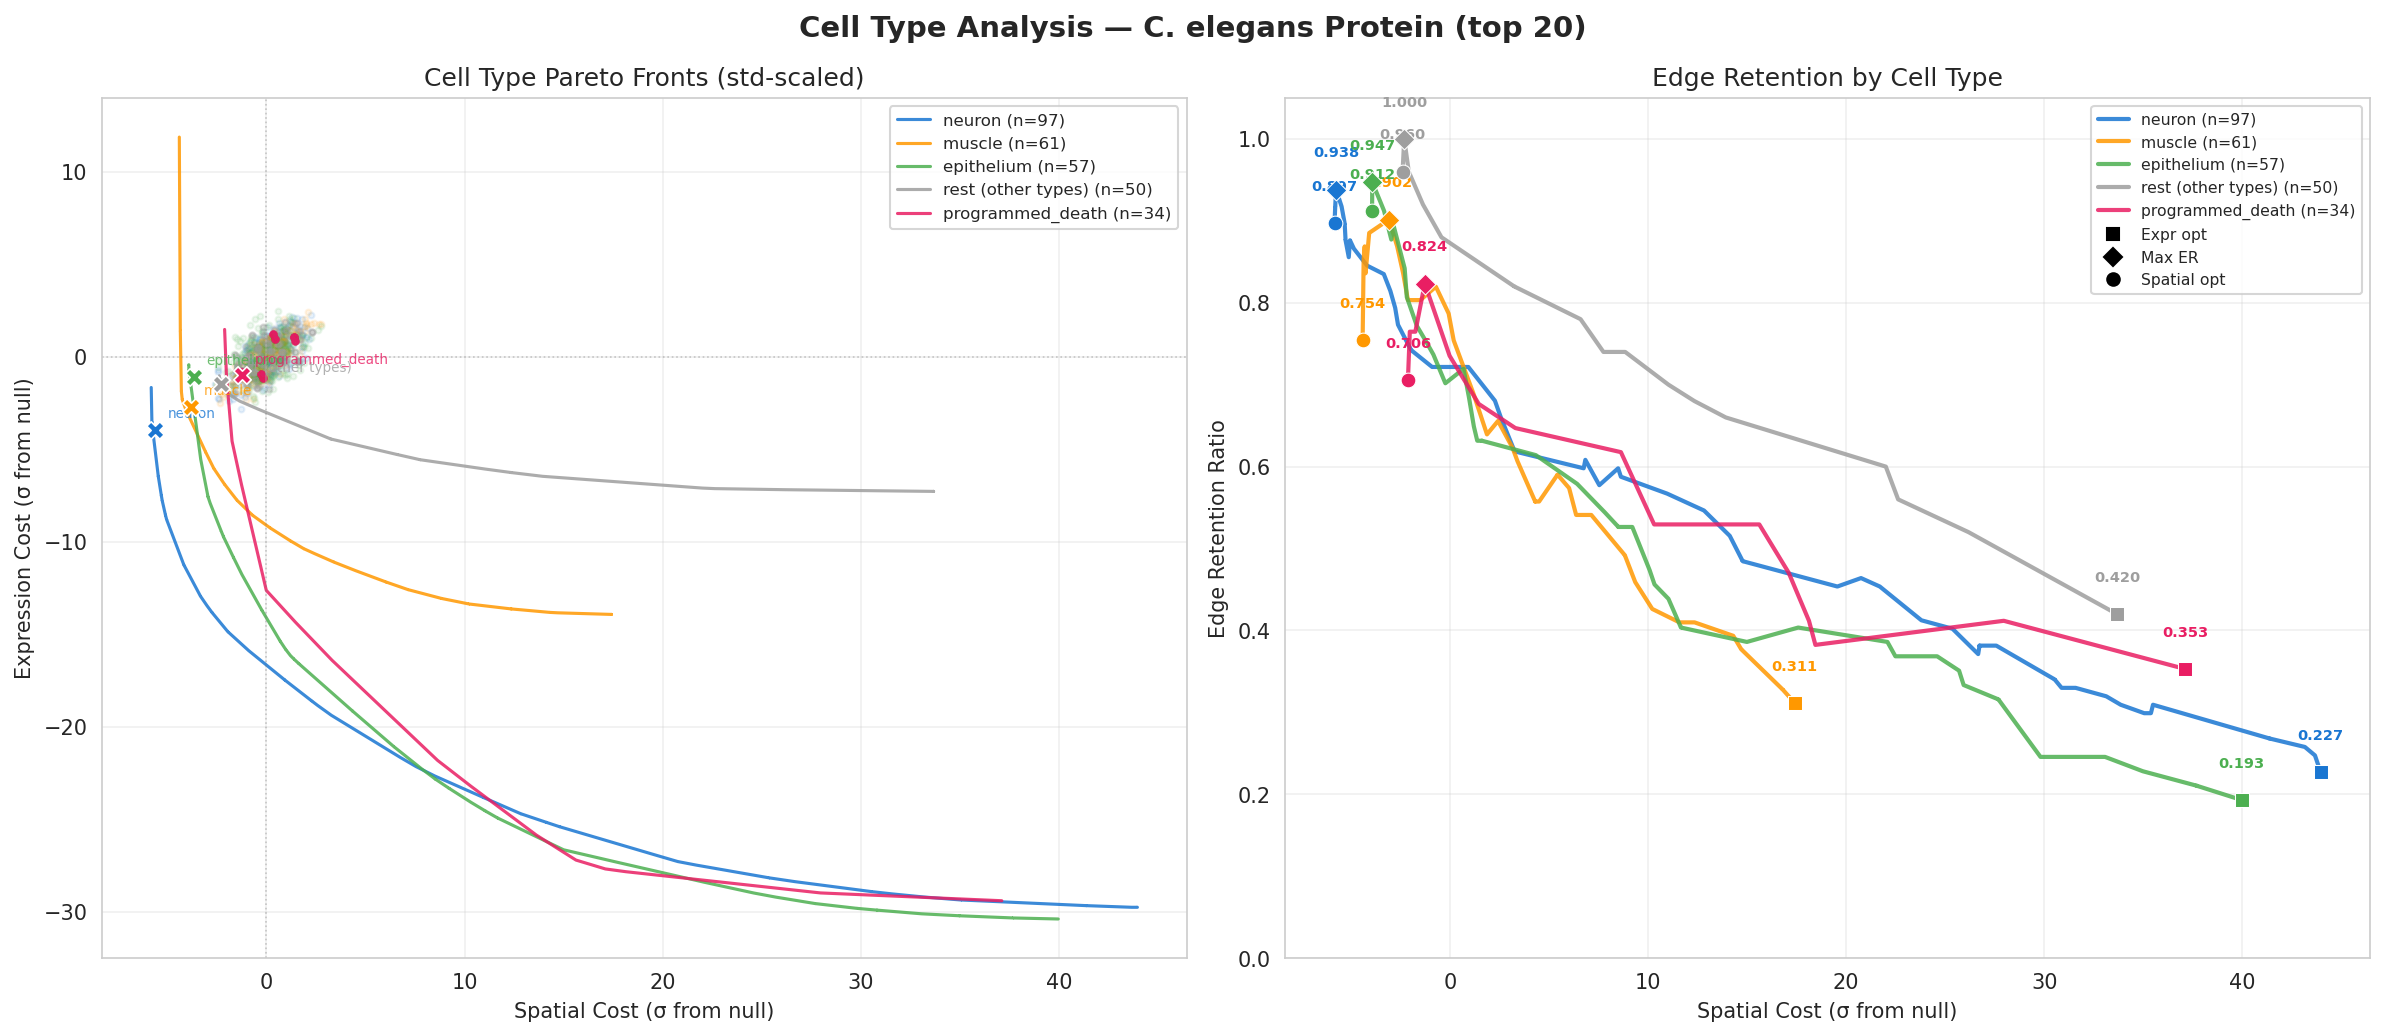

In [42]:
# ── Figure: Cell type Pareto fronts (std-based scaling) ──
ct_colors = {'neuron': '#1976D2', 'muscle': '#FF9800', 'epithelium': '#4CAF50',
             'rest (other types)': '#9E9E9E', 'programmed_death': '#E91E63'}

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))
for gname in ct_results:
    d = ct_results[gname]
    color = ct_colors.get(gname, 'gray')

    # Compute random stats for this cell type
    sub_groups = build_cousin_groups(d['tn'], gp_map)
    sub_rs = compute_cousin_random_stats(d['xm'], d['em'], sub_groups, n_random=300, seed=42)

    # Std-scaled (z-scored) Pareto front
    xyz_arr, exp_arr, edge_arr, kp = compute_std_scaled_pareto(d['xm'], d['em'], d['tp'], sub_rs)
    n = len(d['tn'])

    # Lineage position in z-score units
    lx, le = lineage_std_position(d['xm'], d['em'], sub_rs)

    # Null cloud from first type only
    ncx, ncy = get_null_cloud(sub_rs, max_points=250)
    ax_l.scatter(ncx, ncy, c=color, s=8, alpha=0.10, zorder=0)

    ax_l.plot(xyz_arr, exp_arr, color=color, lw=1.5, alpha=0.85, label=f'{gname} (n={n})')
    ax_l.scatter(lx, le, color=color, marker='X', s=70, edgecolors='white', lw=0.8, zorder=6)
    ax_l.annotate(f'{gname}', (lx, le), xytext=(6, 6), textcoords='offset points',
                  fontsize=6.5, color=color, alpha=0.8)
    ax_r.plot(xyz_arr, edge_arr, color=color, lw=2, alpha=0.85, label=f'{gname} (n={n})')
    for pk, mk in markers.items():
        idx = kp[pk]
        ax_r.scatter(xyz_arr[idx], edge_arr[idx], color=color, marker=mk, s=50, zorder=8, edgecolors='white', lw=0.5)
        ax_r.annotate(f'{edge_arr[idx]:.3f}', (xyz_arr[idx], edge_arr[idx]+0.04), color=color, fontsize=7, ha='center', fontweight='bold')

# Null reference
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)

ax_l.set_xlabel('Spatial Cost (σ from null)')
ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('Cell Type Pareto Fronts (std-scaled)', fontsize=12)
ax_l.legend(fontsize=8, loc='upper right')
ax_l.grid(True, alpha=0.3)
ax_r.set_xlabel('Spatial Cost (σ from null)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('Edge Retention by Cell Type', fontsize=12)
ax_r.set_ylim(0,1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(handles=list(ax_r.get_lines()) + [
    Line2D([0],[0], color='black', marker='s', ls='', markersize=6, label='Expr opt'),
    Line2D([0],[0], color='black', marker='D', ls='', markersize=6, label='Max ER'),
    Line2D([0],[0], color='black', marker='o', ls='', markersize=6, label='Spatial opt'),
], fontsize=7.5, loc='best')
fig.suptitle('Cell Type Analysis — C. elegans Protein (top 20)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 5b. Relaxed Parent Pool — Per-Type Analysis

For each cell type, we compare the **type-restricted** Pareto front (only type-matched parents)
against a **relaxed** version where terminal cells can be assigned to **any** terminal parent
in the full tree.  The relaxed version is an upper bound — it shows how much better the
assignment could be if we dropped the type constraint.

In [43]:
# ── Relaxed parent pool: for each type, assign to ANY parent ──
# Get ALL terminal parents from the full protein tree
all_parents = list(dict.fromkeys(tp_prot))  # unique parents from full tree (terminal + internal nodes)
all_parents_set = set(all_parents)

relaxed_results = {}
for gname in ct_results:
    d = ct_results[gname]
    gn = d['tn']  # terminal cells of this type
    gp = d['tp']  # real parents of these cells
    n_type = len(gn)

    if n_type < 10:
        continue

    # Build rectangular cost matrix: n_parent_candidates x n_type_terminals
    # Initialize with large values to exclude invalid candidates
    BIG = 1e10
    xm_relax = np.full((len(all_parents), n_type), BIG)
    em_relax = np.full((len(all_parents), n_type), BIG)
    for i, parent_candidate in enumerate(all_parents):
        if parent_candidate not in xyz_ce or parent_candidate not in protein_exp.index:
            continue  # skip parents without tracking or expression data
        for j, node in enumerate(gn):
            xm_relax[i, j] = np.linalg.norm(xyz_ce[parent_candidate] - xyz_ce[node])
            em_relax[i, j] = cosine(
                protein_exp.loc[parent_candidate, prot_sel].values,
                protein_exp.loc[node, prot_sel].values
            )

    # Normalize (min-max)
    xm_n = (xm_relax - xm_relax.min()) / (xm_relax.max() - xm_relax.min())
    em_n = (em_relax - em_relax.min()) / (em_relax.max() - em_relax.min())

    # Pareto sweep
    relaxed_edges = []
    for i in range(1001):
        a = i / 1000
        ri, ci = linear_sum_assignment(a * xm_n + (1 - a) * em_n)
        # Edge retention: fraction where assigned parent == real parent
        edges = 0
        for r, c in zip(ri, ci):
            if all_parents[r] == gp[c]:
                edges += 1
        relaxed_edges.append(edges / n_type)

    relaxed_edges = np.array(relaxed_edges)
    # Also compute type-restricted edge ratios (reuse from ct_results but recompute along front)
    xm_r, em_r = d['xm'], d['em']
    xm_rn = (xm_r - xm_r.min()) / (xm_r.max() - xm_r.min())
    em_rn = (em_r - em_r.min()) / (em_r.max() - em_r.min())
    restricted_edges = []
    for i in range(1001):
        a = i / 1000
        ri, ci = linear_sum_assignment(a * xm_rn + (1 - a) * em_rn)
        edges = sum(1 for r, c in zip(ri, ci) if d['tp'][r] == d['tp'][c]) / n_type
        restricted_edges.append(edges)

    relaxed_results[gname] = {
        'relaxed_edges': relaxed_edges,
        'restricted_edges': np.array(restricted_edges),
        'n': n_type,
        'restricted_res': d['res'],
    }

    rlx_max = relaxed_edges.max()
    rst_max = d['res']['max_er']
    print(f"  {gname:20s}: n={n_type:3d} | restricted Max ER={rst_max:.3f} | relaxed Max ER={rlx_max:.3f} | gain={rlx_max-rst_max:+.3f}")


  neuron              : n= 97 | restricted Max ER=0.938 | relaxed Max ER=0.629 | gain=-0.309


  muscle              : n= 61 | restricted Max ER=0.902 | relaxed Max ER=0.475 | gain=-0.426


  epithelium          : n= 57 | restricted Max ER=0.947 | relaxed Max ER=0.509 | gain=-0.439


  rest (other types)  : n= 50 | restricted Max ER=1.000 | relaxed Max ER=0.860 | gain=-0.140


  programmed_death    : n= 34 | restricted Max ER=0.824 | relaxed Max ER=0.529 | gain=-0.294


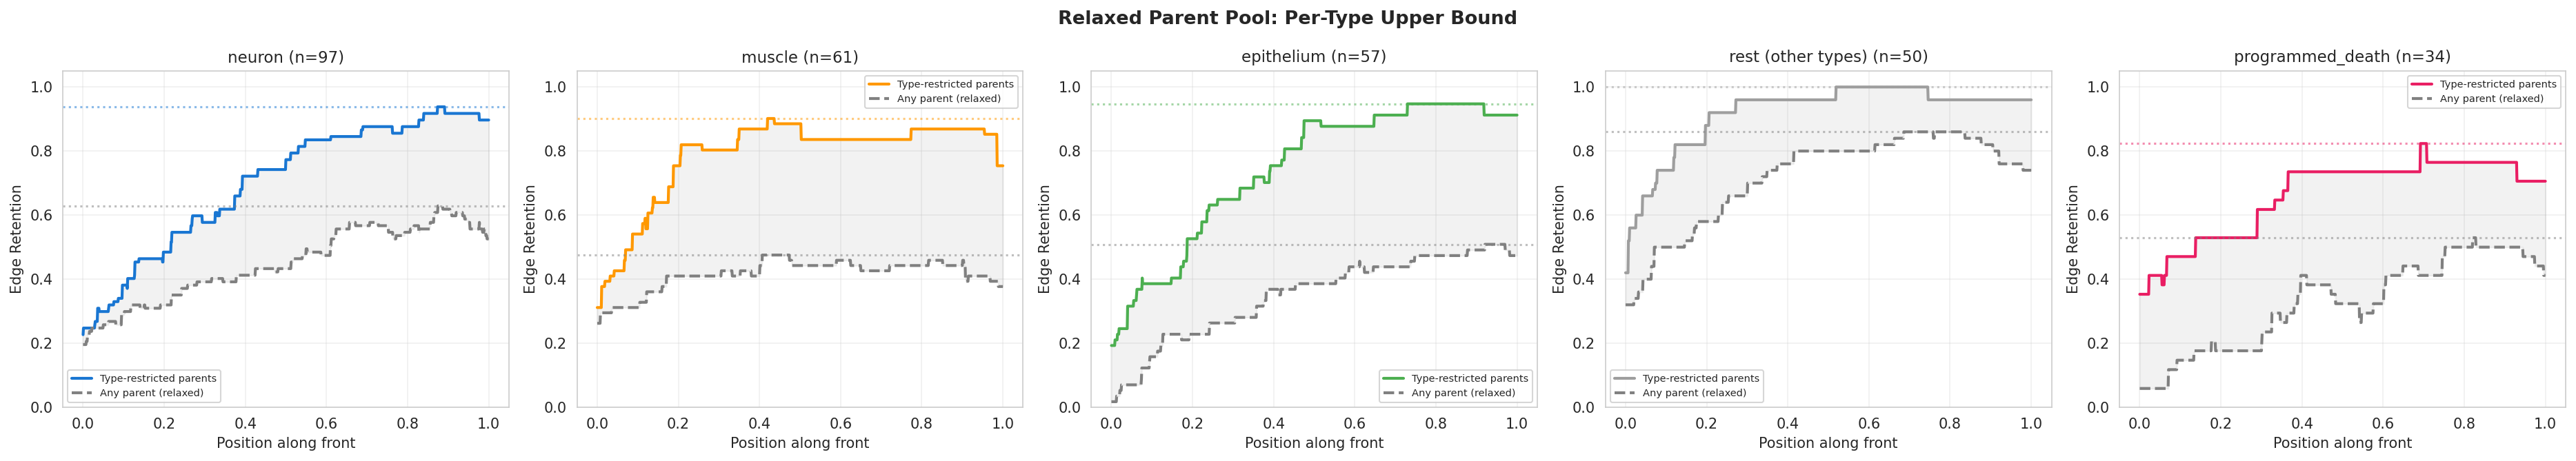

In [44]:
# ── Figure: Relaxed vs Restricted edge retention ──
fig, axes = plt.subplots(1, len(relaxed_results), figsize=(5*len(relaxed_results), 4.5))
if len(relaxed_results) == 1:
    axes = [axes]

for ax, (gname, rd) in zip(axes, relaxed_results.items()):
    xf = np.linspace(0, 1, 1001)
    color_restricted = ct_colors.get(gname, 'gray')
    color_relaxed = 'gray'

    ax.plot(xf, rd['restricted_edges'], color=color_restricted, lw=2, label='Type-restricted parents')
    ax.plot(xf, rd['relaxed_edges'], color=color_relaxed, lw=2, ls='--', label='Any parent (relaxed)')
    ax.axhline(y=rd['restricted_res']['max_er'], color=color_restricted, ls=':', alpha=0.5)
    ax.axhline(y=rd['relaxed_edges'].max(), color=color_relaxed, ls=':', alpha=0.5)
    ax.fill_between(xf, rd['restricted_edges'], rd['relaxed_edges'], alpha=0.1, color='gray')
    ax.set_title(f'{gname} (n={rd["n"]})', fontsize=11)
    ax.set_xlabel('Position along front'); ax.set_ylabel('Edge Retention')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig.suptitle('Relaxed Parent Pool: Per-Type Upper Bound', fontsize=13, fontweight='bold')
fig.tight_layout(); plt.show()


### 5c. Full-Tree Assignment Decomposed by Cell Type

Take the full-tree Pareto front assignment and compute per-type edge retention.
This shows which cell types' lineage edges are preserved vs. sacrificed in the
global optimum (where all 299 cells compete for parents simultaneously).

In [45]:
# ── Decompose full-tree Pareto front by cell type (grouped) ──
xm_full = xm_prot; em_full = em_prot; tp_full = tp_prot; tn_full = tn_prot

# Map terminal cells to merged types
ct_df_full = pd.read_csv('data/2023-06-29_entropy_cell_key_V2.csv')
lt_map = {}
for _, row in ct_df_full.iterrows():
    ln = row.get('wormweb.lineage',''); rt = row.get('wormweb.type','')
    if pd.notna(rt) and rt.strip():
        lt_map[ln] = MERGE_MAP.get(rt.strip(), rt.strip())

full_node_type = {}
for n in tn_full:
    full_node_type[n] = lt_map.get(n, 'programmed_death')

# Group: neuron, muscle, epithelium, programmed_death, rest
MAJOR_TYPES = {'neuron', 'muscle', 'epithelium', 'programmed_death'}
full_type_groups = defaultdict(list)
for i, (node, parent) in enumerate(zip(tn_full, tp_full)):
    ct = full_node_type.get(node, 'programmed_death')
    group = ct if ct in MAJOR_TYPES else 'rest (other types)'
    full_type_groups[group].append(i)

print("Group sizes:")
for ct in sorted(full_type_groups, key=lambda c: -len(full_type_groups[c])):
    print(f"  {ct:20s}: {len(full_type_groups[ct]):3d}")

# Normalize cost matrices
xm_n = (xm_full - xm_full.min()) / (xm_full.max() - xm_full.min())
em_n = (em_full - em_full.min()) / (em_full.max() - em_full.min())

# Find key alpha points
best_er, best_alpha = 0, 0
for i in range(1001):
    a = i/1000; ri, ci = linear_sum_assignment(a*xm_n + (1-a)*em_n)
    er = sum(1 for r,c in zip(ri,ci) if tp_full[r]==tp_full[c]) / len(tp_full)
    if er > best_er: best_er, best_alpha = er, i
key_alphas = {'Expr opt (a=0)': 0, 'Max ER': best_alpha, 'Spatial opt (a=1)': 1000}

decomp_results = {}
for label, alpha_idx in key_alphas.items():
    a = alpha_idx / 1000
    ri, ci = linear_sum_assignment(a * xm_n + (1 - a) * em_n)
    type_er = {}
    for ct, indices in full_type_groups.items():
        edges = sum(1 for idx in indices if tp_full[ri[idx]] == tp_full[ci[idx]])
        type_er[ct] = edges / len(indices) if len(indices) > 0 else 0
    decomp_results[label] = {'alpha_idx': alpha_idx, 'type_er': type_er, 'row_ind': ri, 'col_ind': ci}

# Table
overall_er = {k: sum(1 for r,c in zip(v['row_ind'],v['col_ind']) if tp_full[r]==tp_full[c])/len(tp_full)
              for k,v in decomp_results.items()}
print(f"\nOverall ER: Expr opt={overall_er['Expr opt (a=0)']:.3f}, Max ER={overall_er['Max ER']:.3f}, Spatial opt={overall_er['Spatial opt (a=1)']:.3f}")
print()

decomp_rows = []
for ct in sorted(full_type_groups, key=lambda c: -len(full_type_groups[c])):
    n = len(full_type_groups[ct])
    decomp_rows.append({
        'Cell Type': ct, 'N': n,
        'Expr opt ER': round(decomp_results['Expr opt (a=0)']['type_er'][ct], 3),
        'Max ER point': round(decomp_results['Max ER']['type_er'][ct], 3),
        'Spatial opt ER': round(decomp_results['Spatial opt (a=1)']['type_er'][ct], 3),
    })
decomp_df = pd.DataFrame(decomp_rows).set_index('Cell Type')
decomp_df


Group sizes:
  neuron              :  97
  muscle              :  61
  epithelium          :  57
  rest (other types)  :  50
  programmed_death    :  34



Overall ER: Expr opt=0.204, Max ER=0.819, Spatial opt=0.599



,N,Expr opt ER,Max ER point,Spatial opt ER
Cell Type,,,,
neuron,97,0.227,0.814,0.660
muscle,61,0.311,0.803,0.443
epithelium,57,0.105,0.807,0.667
rest (other types),50,0.240,0.920,0.660
programmed_death,34,0.059,0.735,0.500


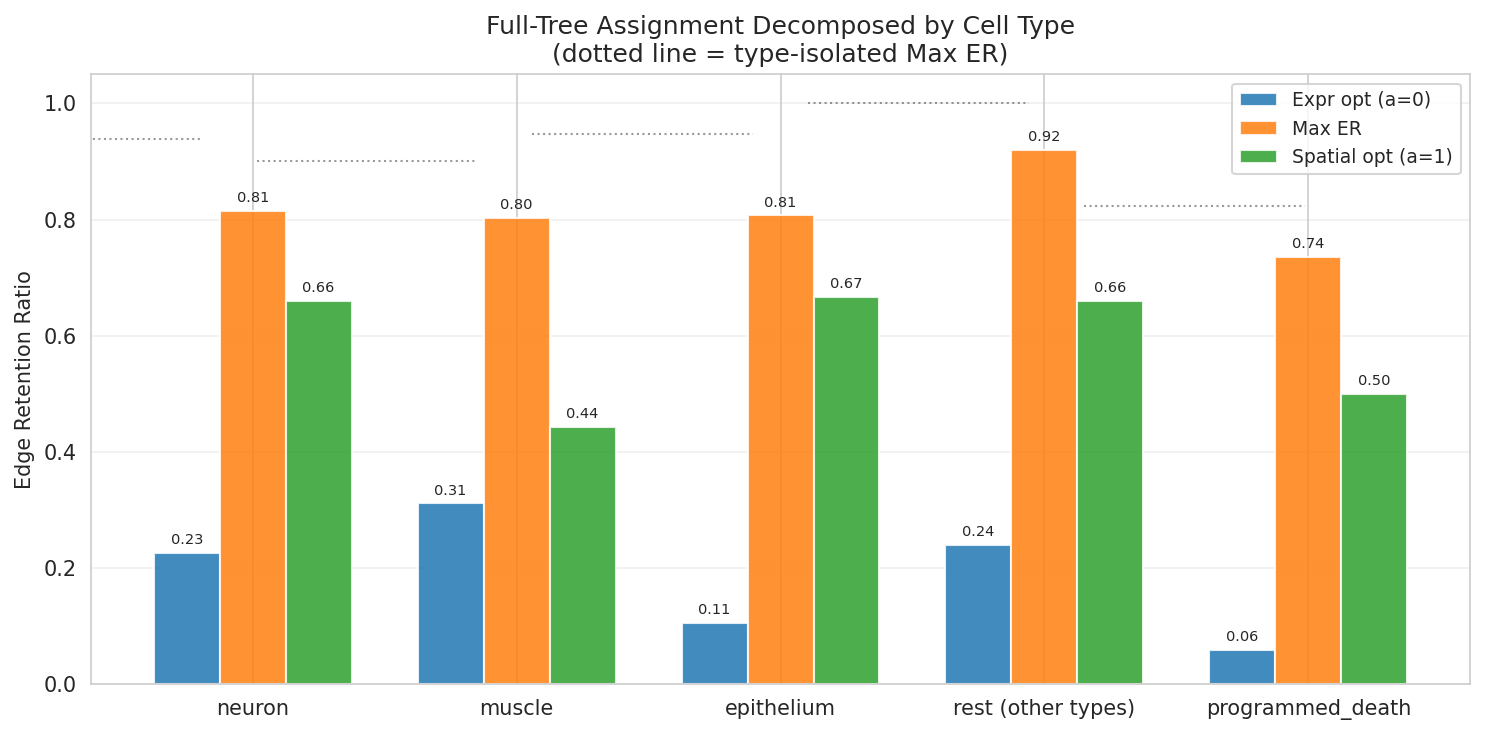

In [46]:
# ── Figure: Per-type edge retention in global assignment (grouped) ──
fig, ax = plt.subplots(figsize=(10, 5))

types_ordered = sorted(full_type_groups, key=lambda c: -len(full_type_groups[c]))
x = np.arange(len(types_ordered))
w = 0.25

for i, (label, alpha_idx) in enumerate(key_alphas.items()):
    ers = [decomp_results[label]['type_er'][ct] for ct in types_ordered]
    bars = ax.bar(x + i*w - w, ers, w, label=label, alpha=0.85)
    for bar, er in zip(bars, ers):
        if er > 0.05:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{er:.2f}', ha='center', va='bottom', fontsize=7)

# Reference: per-type isolated Max ER (dotted lines)
for i, ct in enumerate(types_ordered):
    if ct in ct_results:
        ref_er = ct_results[ct]['res']['max_er']
    elif ct == 'rest (other types)':
        ref_er = ct_results['rest (other types)']['res']['max_er']
    else:
        ref_er = None
    if ref_er is not None:
        ax.axhline(y=ref_er, xmin=(i-0.4)/len(types_ordered),
                   xmax=(i+0.4)/len(types_ordered), color='black', ls=':', alpha=0.4, lw=1)

ax.set_xticks(x); ax.set_xticklabels(types_ordered, fontsize=10)
ax.set_ylabel('Edge Retention Ratio'); ax.set_ylim(0, 1.05)
ax.set_title('Full-Tree Assignment Decomposed by Cell Type\n(dotted line = type-isolated Max ER)', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout(); plt.show()


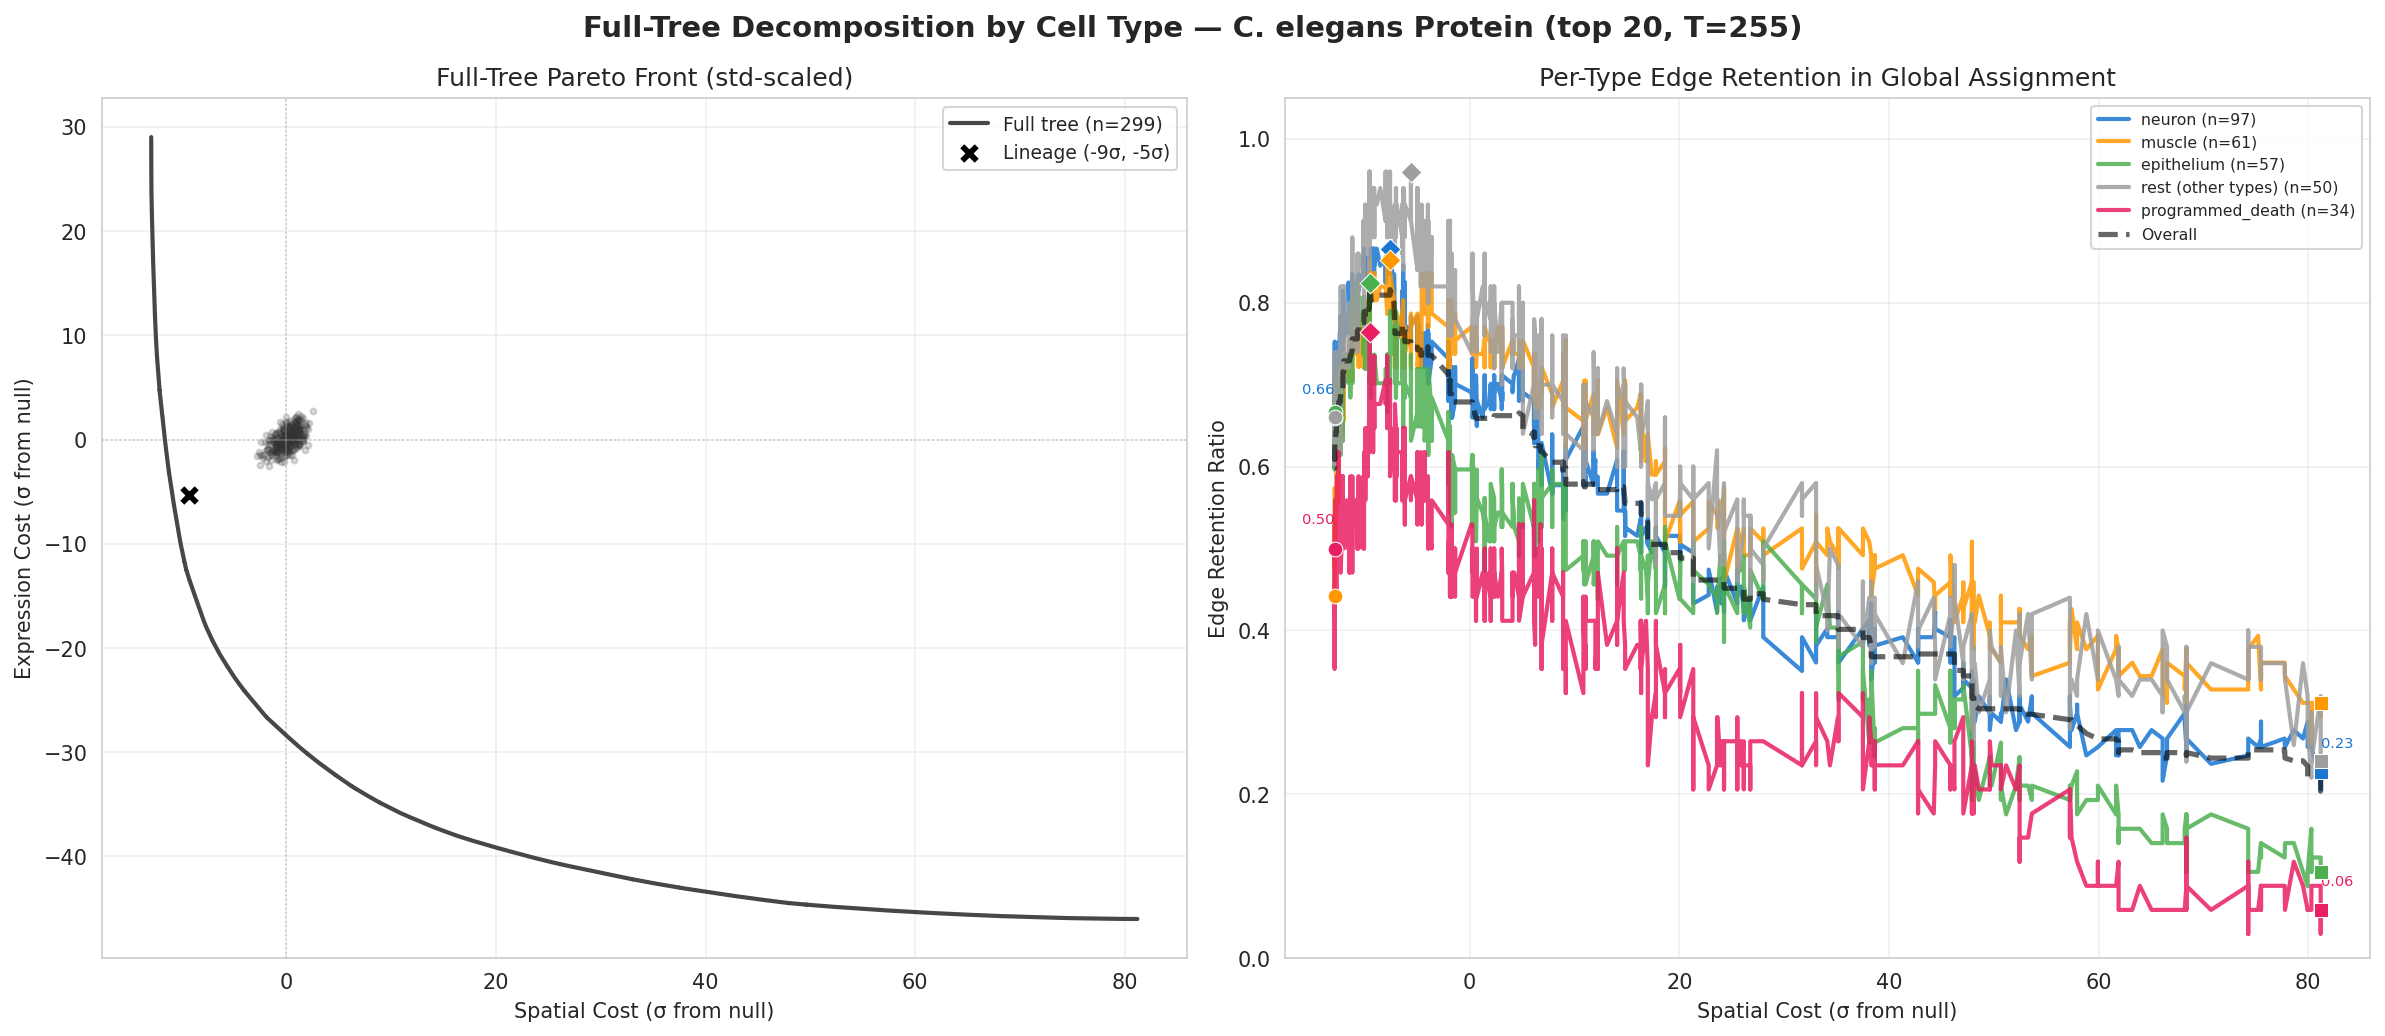

In [47]:
# ── Figure: Full-tree Pareto front + per-type edge retention curves (std-scaled) ──

type_list = sorted(full_type_groups, key=lambda c: -len(full_type_groups[c]))
type_colors = {'neuron': '#1976D2', 'muscle': '#FF9800', 'epithelium': '#4CAF50',
               'rest (other types)': '#9E9E9E', 'programmed_death': '#E91E63'}

# Compute std-based (z-scored) Pareto front for the full tree
xyz_arr, exp_arr, __, ___ = compute_std_scaled_pareto(xm_full, em_full, tp_full, prot_rs)

# Lineage position in z-score units
lx, le = lineage_std_position(xm_full, em_full, prot_rs)

# Compute per-type edge retention at each alpha (alpha grid matches xyz_arr's index-for-index)
per_type_edges = {ct: [] for ct in type_list}
for i in range(1001):
    a = i / 1000
    ri, ci = linear_sum_assignment(a * xm_n + (1 - a) * em_n)
    for ct, indices in full_type_groups.items():
        edges = sum(1 for idx in indices if tp_full[ri[idx]] == tp_full[ci[idx]])
        per_type_edges[ct].append(edges / len(indices))

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 7))

# Null point cloud
ncx, ncy = get_null_cloud(prot_rs, max_points=300)
ax_l.scatter(ncx, ncy, c='#333333', s=8, alpha=0.18, zorder=0)
ax_l.axhline(0, color='gray', lw=0.8, ls=':', alpha=0.4)
ax_l.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.4)

# ── LEFT: Full-tree Pareto front (std-scaled) ──
ax_l.plot(xyz_arr, exp_arr, color='#333333', lw=2, alpha=0.9, label=f'Full tree (n={len(tn_full)})')
ax_l.scatter(lx, le, color='black', marker='X', s=100, edgecolors='white', lw=0.8, zorder=10,
           label=f'Lineage ({lx:.0f}\u03c3, {le:.0f}\u03c3)')
ax_l.set_xlabel('Spatial Cost (σ from null)')
ax_l.set_ylabel('Expression Cost (σ from null)')
ax_l.set_title('Full-Tree Pareto Front (std-scaled)', fontsize=12)
ax_l.legend(fontsize=9, loc='upper right')
ax_l.grid(True, alpha=0.3)

# ── RIGHT: Per-type edge retention along the full-tree front ──
for ct in type_list:
    color = type_colors.get(ct, 'gray')
    edges = np.array(per_type_edges[ct])
    ax_r.plot(xyz_arr, edges, color=color, lw=2, alpha=0.85, label=f'{ct} (n={len(full_type_groups[ct])})')
    ax_r.scatter(xyz_arr[0], edges[0], color=color, marker='s', s=50, zorder=8, edgecolors='white', lw=0.5)
    ax_r.scatter(xyz_arr[-1], edges[-1], color=color, marker='o', s=50, zorder=8, edgecolors='white', lw=0.5)
    max_idx = np.argmax(edges)
    ax_r.scatter(xyz_arr[max_idx], edges[max_idx], color=color, marker='D', s=50, zorder=8, edgecolors='white', lw=0.5)
    if ct in ['neuron', 'programmed_death']:
        ax_r.annotate(f'{edges[0]:.2f}', (xyz_arr[0], edges[0]+0.03), color=color, fontsize=7, ha='left')
        ax_r.annotate(f'{edges[-1]:.2f}', (xyz_arr[-1], edges[-1]+0.03), color=color, fontsize=7, ha='right')

overall_edges = []
for i in range(1001):
    a = i/1000
    ri, ci = linear_sum_assignment(a*xm_n + (1-a)*em_n)
    overall_edges.append(sum(1 for r,c in zip(ri,ci) if tp_full[r]==tp_full[c]) / len(tp_full))
ax_r.plot(xyz_arr, overall_edges, color='black', lw=2.5, ls='--', alpha=0.6, label='Overall')

ax_r.set_xlabel('Spatial Cost (σ from null)')
ax_r.set_ylabel('Edge Retention Ratio')
ax_r.set_title('Per-Type Edge Retention in Global Assignment', fontsize=12)
ax_r.set_ylim(0, 1.05)
ax_r.grid(True, alpha=0.3)
ax_r.legend(fontsize=7.5, loc='best')

fig.suptitle('Full-Tree Decomposition by Cell Type — C. elegans Protein (top 20, T=255)',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

---
## Appendix: C. briggsae Tracking Config

Final selected configuration after comparison: **`CD140715HLH1cbp1.csv` with T≤155 cutoff** (69 terminal cells with RNA data).

This embryo + early cutoff gives the best spatial-expression coupling among tested options
(Max ER=0.754, Closest Dist=0.245), comparable to C. elegans at T≤230.


---
## 6. Grand Summary

In [48]:
# ── All results in one combined table ──
all_rows = []

# Full tree
all_rows.append({'Experiment': 'Full — C.elegans Protein (T=230)', 'Group': 'Full tree', 'N': len(tn_prot_early),
    'Expr Opt ER': res_prot_xs['expr_opt_er'], 'Max ER': res_prot_xs['max_er'], 'Spatial Opt ER': res_prot_xs['spatial_opt_er']})
all_rows.append({'Experiment': 'Full — C.elegans RNA (T=230)', 'Group': 'Full tree', 'N': len(tn_er_early),
    'Expr Opt ER': res_er_xs['expr_opt_er'], 'Max ER': res_er_xs['max_er'], 'Spatial Opt ER': res_er_xs['spatial_opt_er']})
# Old briggsae (kept for reference)
all_rows.append({'Experiment': 'Full — C.briggsae RNA (old, T=155)', 'Group': 'Full tree', 'N': len(tn_cb),
    'Expr Opt ER': res_cb['expr_opt_er'], 'Max ER': res_cb['max_er'], 'Spatial Opt ER': res_cb['spatial_opt_er']})
# New briggsae (primary cross-species comparison)
all_rows.append({'Experiment': 'Full — C.briggsae RNA (T=143)', 'Group': 'Full tree', 'N': len(tn_cb_new),
    'Expr Opt ER': res_cb_new['expr_opt_er'], 'Max ER': res_cb_new['max_er'], 'Spatial Opt ER': res_cb_new['spatial_opt_er']})

# Subtrees
for label in ['AB', 'ABa', 'ABp', 'P1']:
    for exp_name, sub_dict in [('Subtree — C.elegans Protein', prot_sub), ('Subtree — C.elegans RNA', er_sub), ('Subtree — C.briggsae RNA', cb_sub)]:
        d = sub_dict[label]
        all_rows.append({'Experiment': exp_name, 'Group': label, 'N': len(d['tn']),
            'Expr Opt ER': d['res']['expr_opt_er'], 'Max ER': d['res']['max_er'], 'Spatial Opt ER': d['res']['spatial_opt_er']})

# Cell types
for gname in ct_results:
    d = ct_results[gname]
    all_rows.append({'Experiment': 'Cell Type — C.elegans Protein', 'Group': gname, 'N': len(d['tn']),
        'Expr Opt ER': d['res']['expr_opt_er'], 'Max ER': d['res']['max_er'], 'Spatial Opt ER': d['res']['spatial_opt_er']})

grand_df = pd.DataFrame(all_rows)
grand_df


,Experiment,Group,N,Expr Opt ER,Max ER,Spatial Opt ER
0,Full — C.elegans Protein (T=230),Full tree,90,0.204013,0.819398,0.598662
1,Full — C.elegans RNA (T=230),Full tree,70,0.073593,0.805195,0.683983
2,"Full — C.briggsae RNA (old, T=155)",Full tree,69,0.130435,0.753623,0.492754
3,Full — C.briggsae RNA (T=143),Full tree,209,0.076555,0.641148,0.468900
4,Subtree — C.elegans Protein,AB,216,0.217593,0.837963,0.671296
5,Subtree — C.elegans RNA,AB,157,0.082803,0.936306,0.910828
6,Subtree — C.briggsae RNA,AB,37,0.243243,0.891892,0.837838
7,Subtree — C.elegans Protein,ABa,106,0.301887,0.886792,0.679245
8,Subtree — C.elegans RNA,ABa,73,0.136986,0.945205,0.945205
9,Subtree — C.briggsae RNA,ABa,21,0.380952,1.000000,0.904762


### Key Takeaways

1. **Protein >> RNA for lineage signal.** Protein expression carries 2–3× more lineage
   information than RNA at every level (full tree and subtrees). The expression optimum
   edge retention for protein (0.20) far exceeds RNA (0.07) for C. elegans.

2. **Subdividing the tree amplifies signal.** Whether by lineage branch or cell type,
   smaller, more homogeneous groups show stronger spatial-expression coupling. Subtree
   Max ER reaches 0.88–0.95 vs 0.82 for the full tree.

3. **C. elegans RNA compensates via spatial info.** Despite weak expression-only signal
   (ER=0.07), the best trade-off achieves ER=0.81—matching protein's performance. The
   Pareto framework reveals that RNA data, though noisy alone, complements spatial
   proximity very effectively.

4. **C. briggsae shows weaker coupling.** Max ER peaks at 0.69 in the P1 subtree vs
   0.95 for C. elegans. This is partly due to lower-quality spatial data (spatial opt
   ER=0.31 vs 0.60–0.68) and partly genuine species differences.

5. **Cell types show near-perfect recapitulation.** Within a single cell type, the
   Pareto front achieves Max ER of 0.90–1.00. The "rest" group of minor types actually
   hits 100% edge retention—their diverse expression profiles make parent→child
   assignment unambiguous.

6. **Programmed death cells are molecularly distinct.** Apoptotic cells have the
   second-highest expression-only ER (0.35 in both full-tree protein and cell-type
   analyses), confirming that cell death involves strong, specific transcriptional
   programs.
